# NBA Rebounds Modeling Research (v1)

Context:
- Goal: build a bottom-up, game-to-game rebounds modeling workflow that can be converted into a bookmaker pricing model.
- Focus in this notebook: data sanity, target construction, and first-pass feature diagnostics.
- Scope: research only (no production assumptions yet).


In [2]:
from pathlib import Path
import subprocess

import duckdb
import numpy as np
import pandas as pd

repo_root = Path(
    subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
)
module_root = repo_root / "src" / "nba_rebounds_modeling"
research_root = module_root / "00_research"

print(f"repo_root={repo_root}")
print(f"module_root={module_root}")


repo_root=/Users/thomasmyles/dev/betting
module_root=/Users/thomasmyles/dev/betting/src/nba_rebounds_modeling


## Initial modeling hypotheses

1. Minutes drive rebound opportunity volume more than recent rebound box-score trend.
2. Opponent shot profile (miss volume + shot distribution) matters for both ceiling and floor.
3. Role and lineup context (on/off teammates) shifts rebound share materially.
4. Market may lag when injury/rotation changes alter expected minutes and share.


In [3]:
# Canonical v1 query lives in 00_research/sql and reads v1_rebounds_universe.parquet.
sql_path = research_root / "sql" / "v1_notebook_rebounds_universe.sql"
sql_query = sql_path.read_text()

con = duckdb.connect()
df = con.execute(sql_query).fetchdf()
con.close()

required_columns = [
    "season",
    "date",
    "game_id",
    "player_normalized",
    "team_normalized",
    "MIN",
    "OREB",
    "DREB",
    "REB",
    "bookmaker",
    "line",
    "odds_over",
    "odds_under",
]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns from v1 query: {missing_columns}")

print(f"rows={len(df)}")
print(f"seasons={sorted(df['season'].unique().tolist())}")
df.head()


rows=32687
seasons=['2023-24', '2024-25', '2025-26']


,season,date,game_id,player_normalized,team_normalized,MIN,OREB,DREB,REB,bookmaker,line,odds_over,odds_under,min_rounded,rebounds_vs_line
0,2023-24,2023-10-24,0022300061,Aaron Gordon,Denver Nuggets,34.971667,2,5,7,bovada,6.5,105.0,-135.0,35.0,0.5
1,2023-24,2023-10-24,0022300062,Andrew Wiggins,Golden State Warriors,27.283333,1,0,1,unibet_us,5.5,107.0,-141.0,27.3,-4.5
2,2023-24,2023-10-24,0022300061,Anthony Davis,Los Angeles Lakers,34.150000,1,7,8,betonlineag,11.5,-114.0,-114.0,34.2,-3.5
3,2023-24,2023-10-24,0022300061,Austin Reaves,Los Angeles Lakers,31.333333,4,4,8,bovada,3.5,-115.0,-115.0,31.3,4.5
4,2023-24,2023-10-24,0022300062,Chris Paul,Golden State Warriors,34.216667,1,5,6,pointsbetus,3.5,-115.0,-115.0,34.2,2.5


In [4]:
import numpy as np
import pandas as pd

# If you already loaded df from your SQL, this uses it directly.
# Expected columns: bookmaker, line, REB, odds_over, odds_under

def american_to_implied_prob(odds: float) -> float:
    if np.isnan(odds):
        return float("nan")
    if odds < 0:
        return float((-odds) / ((-odds) + 100.0))
    return float(100.0 / (odds + 100.0))

work = df.copy()
work["line"] = pd.to_numeric(work["line"], errors="coerce")
work["REB"] = pd.to_numeric(work["REB"], errors="coerce")
work["odds_over"] = pd.to_numeric(work["odds_over"], errors="coerce")
work["odds_under"] = pd.to_numeric(work["odds_under"], errors="coerce")

work = work.dropna(subset=["bookmaker", "line", "REB", "odds_over", "odds_under"]).copy()

# Drop pushes so outcome is binary for both sides
work = work[work["REB"] != work["line"]].copy()

# Model probabilities from market odds
work["p_over"] = work["odds_over"].apply(american_to_implied_prob)
work["p_under"] = work["odds_under"].apply(american_to_implied_prob)

# Binary outcomes per side
work["y_over"] = (work["REB"] > work["line"]).astype(int)
work["y_under"] = (work["REB"] < work["line"]).astype(int)

over_view = work[["bookmaker", "p_over", "y_over"]].rename(
    columns={"p_over": "p_hat", "y_over": "y"}
)
over_view["side"] = "over"

under_view = work[["bookmaker", "p_under", "y_under"]].rename(
    columns={"p_under": "p_hat", "y_under": "y"}
)
under_view["side"] = "under"

scored = pd.concat([over_view, under_view], ignore_index=True)
scored["brier_component"] = (scored["p_hat"] - scored["y"]) ** 2

brier_by_book_side = (
    scored.groupby(["bookmaker", "side"], as_index=False)
    .agg(
        n=("y", "count"),
        brier=("brier_component", "mean"),
        avg_implied_prob=("p_hat", "mean"),
        observed_rate=("y", "mean"),
    )
    .sort_values(["bookmaker", "side"])
    .reset_index(drop=True)
)

brier_by_book_side["calibration_gap"] = (
    brier_by_book_side["avg_implied_prob"] - brier_by_book_side["observed_rate"]
).abs()

# brier_by_book_side[brier_by_book_side["n"] > 101].sort_values('brier')

In [5]:
min_n = 1000

ranked = (
    brier_by_book_side[brier_by_book_side["n"] >= min_n]
    .sort_values(
        ["side", "brier", "calibration_gap", "n"],
        ascending=[True, True, True, False],
    )
    .reset_index(drop=True)
)

ranked

,bookmaker,side,n,brier,avg_implied_prob,observed_rate,calibration_gap
0,draftkings,over,4143,0.248740,0.525697,0.482501,0.043196
1,betrivers,over,3915,0.249428,0.534350,0.485824,0.048527
2,betonlineag,over,3295,0.249482,0.527579,0.476783,0.050796
3,betmgm,over,6784,0.249578,0.534840,0.476857,0.057983
4,williamhill_us,over,4141,0.249604,0.536396,0.479836,0.056560
5,pointsbetus,over,1659,0.249757,0.528830,0.481013,0.047817
6,fanduel,over,4874,0.250319,0.534552,0.493229,0.041322
7,bovada,over,2818,0.250632,0.528893,0.481902,0.046991
8,betmgm,under,6784,0.246465,0.536372,0.523143,0.013229
9,williamhill_us,under,4141,0.246796,0.540797,0.520164,0.020633


In [6]:
overall = (
    brier_by_book_side.groupby("bookmaker", as_index=False)
    .apply(lambda g: pd.Series({
        "n_total": g["n"].sum(),
        "brier_weighted": (g["brier"] * g["n"]).sum() / g["n"].sum(),
        "calibration_gap_weighted": (g["calibration_gap"] * g["n"]).sum() / g["n"].sum(),
    }))
    .reset_index(drop=True)
    .sort_values(["brier_weighted", "calibration_gap_weighted", "n_total"],
                 ascending=[True, True, False])
)

overall[overall["n_total"] >= min_n]

/var/folders/xy/8hvrs8m970qgw74212qdv2g00000gn/T/ipykernel_3894/3451929248.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,bookmaker,n_total,brier_weighted,calibration_gap_weighted
1,betmgm,13568.0,0.248022,0.035606
5,draftkings,8286.0,0.248029,0.033102
11,williamhill_us,8282.0,0.248200,0.038597
2,betonlineag,6590.0,0.248288,0.032116
3,betrivers,7830.0,0.248531,0.035790
9,pointsbetus,3318.0,0.248815,0.034260
7,fanduel,9748.0,0.249716,0.031447
4,bovada,5636.0,0.249720,0.033865
6,fanatics,1788.0,0.251149,0.035193


In [7]:
# Check whether "auto-bet under" would be profitable (flat 1u stakes),
# and show by-bookmaker breakdown for both sides.

import numpy as np
import pandas as pd

# expects df loaded from your v1 notebook query
work = df.copy()

for col in ["line", "REB", "odds_over", "odds_under"]:
    work[col] = pd.to_numeric(work[col], errors="coerce")

work = work.dropna(subset=["bookmaker", "line", "REB", "odds_over", "odds_under"]).copy()

# remove pushes so outcomes are binary
work = work[work["REB"] != work["line"]].copy()

def american_to_implied_prob(odds: float) -> float:
    if np.isnan(odds):
        return float("nan")
    if odds < 0:
        return float((-odds) / ((-odds) + 100.0))
    return float(100.0 / (odds + 100.0))

def american_to_decimal_profit(odds: float) -> float:
    # net profit on a 1u win (stake excluded)
    if odds > 0:
        return odds / 100.0
    return 100.0 / (-odds)

# Side-level outcomes, probs, pnl
for side in ["over", "under"]:
    odds_col = f"odds_{side}"
    y_col = f"y_{side}"

    if side == "over":
        work[y_col] = (work["REB"] > work["line"]).astype(int)
    else:
        work[y_col] = (work["REB"] < work["line"]).astype(int)

    work[f"implied_{side}"] = work[odds_col].apply(american_to_implied_prob)
    work[f"win_profit_{side}"] = work[odds_col].apply(american_to_decimal_profit)
    work[f"pnl_{side}"] = np.where(
        work[y_col] == 1,
        work[f"win_profit_{side}"],  # win
        -1.0,                        # lose stake
    )

# By bookmaker x side
rows = []
for side in ["over", "under"]:
    g = (
        work.groupby("bookmaker", as_index=False)
        .agg(
            n=(f"y_{side}", "count"),
            hit_rate=(f"y_{side}", "mean"),
            avg_implied_prob=(f"implied_{side}", "mean"),
            avg_pnl_units=(f"pnl_{side}", "mean"),
        )
    )
    g["side"] = side
    g["edge_vs_implied"] = g["hit_rate"] - g["avg_implied_prob"]
    g["roi_pct"] = 100.0 * g["avg_pnl_units"]
    rows.append(g)

by_book_side = pd.concat(rows, ignore_index=True)

# Optional: drop tiny samples
min_n = 500
by_book_side_filtered = (
    by_book_side[by_book_side["n"] >= min_n]
    .sort_values(["side", "roi_pct"], ascending=[True, False])
    .reset_index(drop=True)
)

# Auto-under summary across all books/rows
auto_under = pd.DataFrame(
    [
        {
            "n": int(work["y_under"].count()),
            "hit_rate": float(work["y_under"].mean()),
            "avg_implied_prob": float(work["implied_under"].mean()),
            "edge_vs_implied": float(work["y_under"].mean() - work["implied_under"].mean()),
            "avg_pnl_units": float(work["pnl_under"].mean()),
            "roi_pct": float(100.0 * work["pnl_under"].mean()),
        }
    ]
)

print("AUTO-UNDER SUMMARY (all books):")
print(auto_under.to_string(index=False))

print("\nBOOKMAKER x SIDE (n >= min_n):")
by_book_side_filtered

AUTO-UNDER SUMMARY (all books):
    n  hit_rate  avg_implied_prob  edge_vs_implied  avg_pnl_units   roi_pct
32687  0.517239          0.536826        -0.019587      -0.038154 -3.815396

BOOKMAKER x SIDE (n >= min_n):


,bookmaker,n,hit_rate,avg_implied_prob,avg_pnl_units,side,edge_vs_implied,roi_pct
0,fanatics,894,0.514541,0.533972,-0.032896,over,-0.019431,-3.289645
1,fanduel,4874,0.493229,0.534552,-0.077596,over,-0.041322,-7.759588
2,draftkings,4143,0.482501,0.525697,-0.084536,over,-0.043196,-8.453560
3,bovada,2818,0.481902,0.528893,-0.089115,over,-0.046991,-8.911486
4,pointsbetus,1659,0.481013,0.528830,-0.092836,over,-0.047817,-9.283573
5,betrivers,3915,0.485824,0.534350,-0.093797,over,-0.048527,-9.379668
6,betonlineag,3295,0.476783,0.527579,-0.098348,over,-0.050796,-9.834806
7,williamhill_us,4141,0.479836,0.536396,-0.108123,over,-0.056560,-10.812265
8,betmgm,6784,0.476857,0.534840,-0.111291,over,-0.057983,-11.129076
9,betonlineag,3295,0.523217,0.536652,-0.026690,under,-0.013435,-2.668966


In [8]:
# Rebounds line-disagreement study (ladder-safe)
# Implements:
# 1) canonical "main line" per book/player-game via no-vig 50/50 proximity
# 2) disagreement panel
# 3) disagreement buckets
# 4) outcome/value diagnostics
# 5) deliverables A-D

from pathlib import Path
import numpy as np
import pandas as pd

# =============================================================================
# HELPERS
# =============================================================================

def american_to_implied_prob(odds: float) -> float:
    if np.isnan(odds):
        return float("nan")
    if odds < 0:
        return float((-odds) / ((-odds) + 100.0))
    return float(100.0 / (odds + 100.0))

def remove_vig_two_way(p_over: float, p_under: float) -> tuple[float, float]:
    total = p_over + p_under
    if total <= 0.0:
        return 0.5, 0.5
    return float(p_over / total), float(p_under / total)

def american_to_decimal_profit(odds: float) -> float:
    # net profit on 1u stake (stake excluded)
    if odds > 0:
        return float(odds / 100.0)
    return float(100.0 / (-odds))

# =============================================================================
# LOAD RAW MULTI-BOOK / MULTI-LINE DATA (NOT canonical v1 universe)
# =============================================================================

tmp_dir = Path("~/Downloads/tmp").expanduser()

props_files = sorted(tmp_dir.glob("v1_rebounds_props_*.parquet"))
logs_files = sorted(tmp_dir.glob("v1_rebounds_logs_*.parquet"))

if len(props_files) == 0:
    raise ValueError("No v1_rebounds_props_*.parquet files found in ~/Downloads/tmp")
if len(logs_files) == 0:
    raise ValueError("No v1_rebounds_logs_*.parquet files found in ~/Downloads/tmp")

raw_props = pd.concat([pd.read_parquet(p) for p in props_files], ignore_index=True)
raw_logs = pd.concat([pd.read_parquet(p) for p in logs_files], ignore_index=True)

print(f"loaded_props_rows={len(raw_props)} from {len(props_files)} files")
print(f"loaded_logs_rows={len(raw_logs)} from {len(logs_files)} files")

# required schema checks (fail-fast)
required_props_cols = ["season", "date", "player_normalized", "bookmaker", "line", "odds_over", "odds_under"]
required_logs_cols = ["season", "date", "game_id", "player_normalized", "REB"]

missing_props = [c for c in required_props_cols if c not in raw_props.columns]
missing_logs = [c for c in required_logs_cols if c not in raw_logs.columns]
if missing_props:
    raise ValueError(f"raw_props missing required columns: {missing_props}")
if missing_logs:
    raise ValueError(f"raw_logs missing required columns: {missing_logs}")

# normalize dtypes
props = raw_props.copy()
for c in ["line", "odds_over", "odds_under"]:
    props[c] = pd.to_numeric(props[c], errors="coerce")
props = props.dropna(subset=["season", "date", "player_normalized", "bookmaker", "line", "odds_over", "odds_under"]).copy()

logs = raw_logs.copy()
logs["REB"] = pd.to_numeric(logs["REB"], errors="coerce")
logs = logs.dropna(subset=["season", "date", "player_normalized", "game_id", "REB"]).copy()

# one game_id per season/date/player
logs_key_dup = logs.duplicated(subset=["season", "date", "player_normalized"], keep=False).sum()
if logs_key_dup > 0:
    raise ValueError(f"logs has duplicate season/date/player keys: {logs_key_dup}")

# =============================================================================
# 1) MAIN LINE PER BOOK x PLAYER-GAME (NO-VIG CLOSEST TO 50/50)
# =============================================================================

props["p_over_raw"] = props["odds_over"].apply(american_to_implied_prob)
props["p_under_raw"] = props["odds_under"].apply(american_to_implied_prob)

no_vig = props.apply(
    lambda r: remove_vig_two_way(float(r["p_over_raw"]), float(r["p_under_raw"])),
    axis=1,
)
props["p_over_novig"] = [x[0] for x in no_vig]
props["p_under_novig"] = [x[1] for x in no_vig]
props["distance_to_5050"] = (props["p_over_novig"] - 0.5).abs()

# collapse potential duplicate snapshots for same line at same book/player/date
book_line = (
    props.groupby(["season", "date", "player_normalized", "bookmaker", "line"], as_index=False)
    .agg(
        odds_over=("odds_over", "median"),
        odds_under=("odds_under", "median"),
        p_over_novig=("p_over_novig", "median"),
        p_under_novig=("p_under_novig", "median"),
        distance_to_5050=("distance_to_5050", "median"),
    )
)

main_lines = (
    book_line.sort_values(
        ["season", "date", "player_normalized", "bookmaker", "distance_to_5050", "line"]
    )
    .groupby(["season", "date", "player_normalized", "bookmaker"], as_index=False)
    .first()
)

print(f"main_line_rows={len(main_lines)}")
print(f"main_line_books={main_lines['bookmaker'].nunique()}")

# attach game_id + outcome
main = main_lines.merge(
    logs[["season", "date", "player_normalized", "game_id", "REB"]],
    on=["season", "date", "player_normalized"],
    how="inner",
)

# =============================================================================
# 2) DISAGREEMENT PANEL
# =============================================================================

group_keys = ["season", "date", "player_normalized", "game_id"]

panel = (
    main.groupby(group_keys, as_index=False)
    .agg(
        n_books=("bookmaker", "nunique"),
        min_line=("line", "min"),
        max_line=("line", "max"),
        std_line=("line", "std"),
        median_line=("line", "median"),
        REB=("REB", "first"),
    )
)

panel["std_line"] = panel["std_line"].fillna(0.0)
panel["line_range"] = panel["max_line"] - panel["min_line"]

line_counts = (
    main.groupby(group_keys + ["line"], as_index=False)
    .agg(n_at_line=("bookmaker", "count"))
)

max_line_counts = (
    line_counts.groupby(group_keys, as_index=False)
    .agg(max_n_at_any_line=("n_at_line", "max"))
)

panel = panel.merge(max_line_counts, on=group_keys, how="left")
panel["line_concentration"] = panel["max_n_at_any_line"] / panel["n_books"]

# which books at min/max
main_min = main.merge(panel[group_keys + ["min_line"]], left_on=group_keys + ["line"], right_on=group_keys + ["min_line"], how="inner")
main_max = main.merge(panel[group_keys + ["max_line"]], left_on=group_keys + ["line"], right_on=group_keys + ["max_line"], how="inner")

books_min = (
    main_min.groupby(group_keys, as_index=False)
    .agg(books_at_min=("bookmaker", lambda s: ",".join(sorted(pd.unique(s.astype(str))))))
)
books_max = (
    main_max.groupby(group_keys, as_index=False)
    .agg(books_at_max=("bookmaker", lambda s: ",".join(sorted(pd.unique(s.astype(str))))))
)

panel = panel.merge(books_min, on=group_keys, how="left").merge(books_max, on=group_keys, how="left")

print(f"panel_rows={len(panel)}")
print(f"panel_games_with_2plus_books={(panel['n_books'] >= 2).sum()}")

# =============================================================================
# 3) DISAGREEMENT REGIMES
# =============================================================================

def range_bucket(x: float) -> str:
    if x == 0.0:
        return "0.0_exact_agreement"
    if x <= 0.5:
        return "0.5"
    if x <= 1.0:
        return "1.0"
    return "1.5_plus"

panel["range_bucket"] = panel["line_range"].apply(range_bucket)

# =============================================================================
# 4) OUTCOME + VALUE DIAGNOSTICS
# =============================================================================

# line-only win checks
panel["over_min_line_wins"] = (panel["REB"] > panel["min_line"]).astype(int)
panel["under_max_line_wins"] = (panel["REB"] < panel["max_line"]).astype(int)

# Strategy odds:
# - over at lowest line (pick best odds_over among books quoting min_line)
# - under at highest line (pick best odds_under among books quoting max_line)

best_over_min = (
    main_min.groupby(group_keys + ["min_line"], as_index=False)
    .agg(best_over_odds_at_min=("odds_over", "max"))
)
best_under_max = (
    main_max.groupby(group_keys + ["max_line"], as_index=False)
    .agg(best_under_odds_at_max=("odds_under", "max"))
)

panel = panel.merge(best_over_min, on=group_keys + ["min_line"], how="left")
panel = panel.merge(best_under_max, on=group_keys + ["max_line"], how="left")

panel["p_over_implied_at_min"] = panel["best_over_odds_at_min"].apply(american_to_implied_prob)
panel["p_under_implied_at_max"] = panel["best_under_odds_at_max"].apply(american_to_implied_prob)

panel["pnl_over_min"] = np.where(
    panel["over_min_line_wins"] == 1,
    panel["best_over_odds_at_min"].apply(american_to_decimal_profit),
    -1.0,
)
panel["pnl_under_max"] = np.where(
    panel["under_max_line_wins"] == 1,
    panel["best_under_odds_at_max"].apply(american_to_decimal_profit),
    -1.0,
)

panel["pnl_combo_equal_weight"] = 0.5 * panel["pnl_over_min"] + 0.5 * panel["pnl_under_max"]

# CLV-style proxy: book line relative to game median line
main_with_median = main.merge(panel[group_keys + ["median_line"]], on=group_keys, how="left")
main_with_median["line_minus_median"] = main_with_median["line"] - main_with_median["median_line"]
main_with_median["is_high_outlier_line"] = (main_with_median["line_minus_median"] > 0).astype(int)
main_with_median["is_low_outlier_line"] = (main_with_median["line_minus_median"] < 0).astype(int)

# =============================================================================
# 6) DELIVERABLE TABLES
# =============================================================================

# Table A: disagreement frequency by range bucket
table_a = (
    panel.groupby("range_bucket", as_index=False)
    .agg(
        n_games=("game_id", "count"),
        avg_n_books=("n_books", "mean"),
        avg_line_concentration=("line_concentration", "mean"),
    )
    .sort_values("range_bucket")
    .reset_index(drop=True)
)

# Table B: per-book tendency to post high/low lines
table_b = (
    main_with_median.groupby("bookmaker", as_index=False)
    .agg(
        n_quotes=("line", "count"),
        pct_high_outlier=("is_high_outlier_line", "mean"),
        pct_low_outlier=("is_low_outlier_line", "mean"),
        avg_line_minus_median=("line_minus_median", "mean"),
        med_line_minus_median=("line_minus_median", "median"),
    )
    .sort_values("n_quotes", ascending=False)
    .reset_index(drop=True)
)

# Table C: flat-stake strategy PnL by disagreement bucket
table_c = (
    panel.groupby("range_bucket", as_index=False)
    .agg(
        n_games=("game_id", "count"),
        over_min_win_rate=("over_min_line_wins", "mean"),
        under_max_win_rate=("under_max_line_wins", "mean"),
        over_min_roi=("pnl_over_min", "mean"),
        under_max_roi=("pnl_under_max", "mean"),
        combo_roi=("pnl_combo_equal_weight", "mean"),
        over_min_implied=("p_over_implied_at_min", "mean"),
        under_max_implied=("p_under_implied_at_max", "mean"),
    )
    .sort_values("range_bucket")
    .reset_index(drop=True)
)
for col in ["over_min_roi", "under_max_roi", "combo_roi"]:
    table_c[col] = 100.0 * table_c[col]

# Table D: stability by season
table_d = (
    panel.groupby("season", as_index=False)
    .agg(
        n_games=("game_id", "count"),
        pct_any_disagreement=("line_range", lambda s: float((s > 0).mean())),
        avg_line_range=("line_range", "mean"),
        over_min_roi=("pnl_over_min", "mean"),
        under_max_roi=("pnl_under_max", "mean"),
        combo_roi=("pnl_combo_equal_weight", "mean"),
    )
    .sort_values("season")
    .reset_index(drop=True)
)
for col in ["over_min_roi", "under_max_roi", "combo_roi"]:
    table_d[col] = 100.0 * table_d[col]

# =============================================================================
# PRINT / DISPLAY
# =============================================================================

print("\n=== TABLE A: DISAGREEMENT FREQUENCY BY RANGE BUCKET ===")
print(table_a.to_string(index=False))

print("\n=== TABLE B: BOOK TENDENCY (HIGH/LOW VS GAME MEDIAN LINE) ===")
print(table_b.head(20).to_string(index=False))

print("\n=== TABLE C: REALIZED ROI BY DISAGREEMENT BUCKET (PERCENT) ===")
print(table_c.to_string(index=False))

print("\n=== TABLE D: STABILITY BY SEASON (PERCENT ROI) ===")
print(table_d.to_string(index=False))

# Keep objects for notebook follow-up
# table_a, table_b, table_c, table_d, panel, main, main_with_median

loaded_props_rows=270671 from 1 files
loaded_logs_rows=74806 from 1 files
main_line_rows=230191
main_line_books=13
panel_rows=34622
panel_games_with_2plus_books=33547

=== TABLE A: DISAGREEMENT FREQUENCY BY RANGE BUCKET ===
       range_bucket  n_games  avg_n_books  avg_line_concentration
0.0_exact_agreement    27426     6.098738                1.000000
                0.5        3    11.000000                0.909091
                1.0     7177     6.772189                0.742224
           1.5_plus       16     6.187500                0.718452

=== TABLE B: BOOK TENDENCY (HIGH/LOW VS GAME MEDIAN LINE) ===
     bookmaker  n_quotes  pct_high_outlier  pct_low_outlier  avg_line_minus_median  med_line_minus_median
   betonlineag     31616          0.028024         0.010912               0.014202                    0.0
williamhill_us     29826          0.010092         0.015792              -0.004711                    0.0
        betmgm     29757          0.033337         0.042780      

In [9]:
print("\n=== TABLE A: DISAGREEMENT FREQUENCY BY RANGE BUCKET ===")
display(table_a.round(2))

print("\n=== TABLE B: BOOK TENDENCY (HIGH/LOW VS GAME MEDIAN LINE) ===")
display(table_b.round(2))

print("\n=== TABLE C: REALIZED ROI BY DISAGREEMENT BUCKET (PERCENT) ===")
display(table_c.round(2))

print("\n=== TABLE D: STABILITY BY SEASON (PERCENT ROI) ===")
display(table_d.round(2))


=== TABLE A: DISAGREEMENT FREQUENCY BY RANGE BUCKET ===


,range_bucket,n_games,avg_n_books,avg_line_concentration
0,0.0_exact_agreement,27426,6.10,1.00
1,0.5,3,11.00,0.91
2,1.0,7177,6.77,0.74
3,1.5_plus,16,6.19,0.72



=== TABLE B: BOOK TENDENCY (HIGH/LOW VS GAME MEDIAN LINE) ===


,bookmaker,n_quotes,pct_high_outlier,pct_low_outlier,avg_line_minus_median,med_line_minus_median
0,betonlineag,31616,0.03,0.01,0.01,0.0
1,williamhill_us,29826,0.01,0.02,-0.00,0.0
2,betmgm,29757,0.03,0.04,-0.01,0.0
3,draftkings,29329,0.03,0.03,-0.00,0.0
4,fanduel,28641,0.05,0.05,-0.00,0.0
5,bovada,22822,0.02,0.03,-0.01,0.0
6,betrivers,22446,0.05,0.05,-0.01,0.0
7,pointsbetus,8003,0.03,0.02,0.01,0.0
8,unibet_us,7386,0.04,0.04,0.01,0.0
9,fanatics,5285,0.03,0.05,-0.02,0.0



=== TABLE C: REALIZED ROI BY DISAGREEMENT BUCKET (PERCENT) ===


,range_bucket,n_games,over_min_win_rate,under_max_win_rate,over_min_roi,under_max_roi,combo_roi,over_min_implied,under_max_implied
0,0.0_exact_agreement,27426,0.48,0.52,-6.25,-1.29,-3.77,0.52,0.52
1,0.5,3,0.33,0.67,-40.62,29.33,-5.65,0.58,0.53
2,1.0,7177,0.56,0.59,-5.05,0.46,-2.29,0.59,0.59
3,1.5_plus,16,0.69,0.56,20.32,-9.46,5.43,0.58,0.61



=== TABLE D: STABILITY BY SEASON (PERCENT ROI) ===


,season,n_games,pct_any_disagreement,avg_line_range,over_min_roi,under_max_roi,combo_roi
0,2023-24,9042,0.15,0.15,-6.48,-0.39,-3.43
1,2024-25,12469,0.18,0.18,-5.69,-1.31,-3.50
2,2025-26,13111,0.28,0.28,-5.95,-0.95,-3.45


In [10]:
...

Ellipsis

In [11]:
# =============================================================================
# NBA Rebounds Disagreement Edge Plan (v1) - End-to-end execution cell
# =============================================================================
# What this runs:
# - Phase 0: lock definitions and rebuild main/panel tables
# - Phase 1: H1 validation (line_range=1.0, n_books>=4, under at max line)
# - Phase 2: context grid + ranked candidate cells
# - Phase 3: robustness gates + survivors
# - Phase 4: prototype rule from top survivor (if any)
# - Phase 5: go/no-go summary
#
# Inputs expected in ~/Downloads/tmp from earlier build script:
# - v1_rebounds_props_*.parquet
# - v1_rebounds_logs_*.parquet
# Optional for spread context:
# - v6_spread_universe.parquet
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd

# --------------------------
# Helpers
# --------------------------

def american_to_implied_prob(odds: float) -> float:
    if np.isnan(odds):
        return float("nan")
    if odds < 0:
        return float((-odds) / ((-odds) + 100.0))
    return float(100.0 / (odds + 100.0))

def remove_vig_two_way(p_over: float, p_under: float) -> tuple[float, float]:
    total = p_over + p_under
    if total <= 0.0:
        return 0.5, 0.5
    return float(p_over / total), float(p_under / total)

def american_to_decimal_profit(odds: float) -> float:
    # Net profit on 1u stake when win
    if odds > 0:
        return float(odds / 100.0)
    return float(100.0 / (-odds))

def line_range_bucket(x: float) -> str:
    if x == 0.0:
        return "0.0"
    if x <= 0.5:
        return "0.5"
    if x <= 1.0:
        return "1.0"
    return "1.5_plus"

def line_bucket(x: float) -> str:
    if x <= 4.5:
        return "le_4_5"
    if x <= 8.5:
        return "5_5_to_8_5"
    return "ge_9_5"

def minutes_bucket(x: float) -> str:
    if x < 24.0:
        return "lt_24"
    if x <= 32.0:
        return "24_to_32"
    return "gt_32"

def spread_bucket(x: float) -> str:
    if pd.isna(x):
        return "unknown"
    a = abs(float(x))
    if a <= 3.0:
        return "close"
    if a <= 8.0:
        return "moderate"
    return "blowout_risk"

def hitrate_ci_95(p: float, n: int) -> tuple[float, float]:
    if n <= 0:
        return (np.nan, np.nan)
    se = np.sqrt(max(p * (1.0 - p), 0.0) / n)
    z = 1.96
    return (max(0.0, p - z * se), min(1.0, p + z * se))

# --------------------------
# Load raw artifacts
# --------------------------

tmp_dir = Path("~/Downloads/tmp").expanduser()

props_files = sorted(tmp_dir.glob("v1_rebounds_props_*.parquet"))
logs_files = sorted(tmp_dir.glob("v1_rebounds_logs_*.parquet"))
if len(props_files) == 0:
    raise ValueError("Missing v1_rebounds_props_*.parquet in ~/Downloads/tmp")
if len(logs_files) == 0:
    raise ValueError("Missing v1_rebounds_logs_*.parquet in ~/Downloads/tmp")

raw_props = pd.concat([pd.read_parquet(p) for p in props_files], ignore_index=True)
raw_logs = pd.concat([pd.read_parquet(p) for p in logs_files], ignore_index=True)

required_props = ["season", "date", "player_normalized", "bookmaker", "line", "odds_over", "odds_under"]
required_logs = ["season", "date", "game_id", "player_normalized", "MIN", "OREB", "DREB", "REB"]

missing_props = [c for c in required_props if c not in raw_props.columns]
missing_logs = [c for c in required_logs if c not in raw_logs.columns]
if missing_props:
    raise ValueError(f"raw_props missing columns: {missing_props}")
if missing_logs:
    raise ValueError(f"raw_logs missing columns: {missing_logs}")

props = raw_props.copy()
for c in ["line", "odds_over", "odds_under"]:
    props[c] = pd.to_numeric(props[c], errors="coerce")
props = props.dropna(subset=required_props).copy()

logs = raw_logs.copy()
for c in ["MIN", "OREB", "DREB", "REB"]:
    logs[c] = pd.to_numeric(logs[c], errors="coerce")
logs = logs.dropna(subset=required_logs).copy()

# One row per season/date/player in logs expected
dup_logs = logs.duplicated(subset=["season", "date", "player_normalized"], keep=False).sum()
if dup_logs > 0:
    raise ValueError(f"Duplicate logs keys season/date/player_normalized: {dup_logs}")

print(f"props_rows={len(props):,}")
print(f"logs_rows={len(logs):,}")

# --------------------------
# Phase 0: Build main + panel (locked definitions)
# --------------------------

# No-vig + line proximity to 50/50
props["p_over_raw"] = props["odds_over"].apply(american_to_implied_prob)
props["p_under_raw"] = props["odds_under"].apply(american_to_implied_prob)
novig = props.apply(lambda r: remove_vig_two_way(float(r["p_over_raw"]), float(r["p_under_raw"])), axis=1)
props["p_over_novig"] = [x[0] for x in novig]
props["p_under_novig"] = [x[1] for x in novig]
props["distance_to_5050"] = (props["p_over_novig"] - 0.5).abs()

# Collapse snapshots for same book+line key
book_line = (
    props.groupby(["season", "date", "player_normalized", "bookmaker", "line"], as_index=False)
    .agg(
        odds_over=("odds_over", "median"),
        odds_under=("odds_under", "median"),
        p_over_raw=("p_over_raw", "median"),
        p_under_raw=("p_under_raw", "median"),
        p_over_novig=("p_over_novig", "median"),
        p_under_novig=("p_under_novig", "median"),
        distance_to_5050=("distance_to_5050", "median"),
    )
)

# Main line per bookmaker/player-game
main = (
    book_line.sort_values(
        ["season", "date", "player_normalized", "bookmaker", "distance_to_5050", "line"]
    )
    .groupby(["season", "date", "player_normalized", "bookmaker"], as_index=False)
    .first()
)

# Join realized outcome + identifiers
main = main.merge(
    logs[["season", "date", "game_id", "player_normalized", "MIN", "OREB", "DREB", "REB"]],
    on=["season", "date", "player_normalized"],
    how="inner",
)

# Optional spread context from v6
v6_path = tmp_dir / "v6_spread_universe.parquet"
if v6_path.exists():
    v6 = pd.read_parquet(v6_path)[["season", "date", "player_normalized", "spread_signed"]].drop_duplicates()
    main = main.merge(v6, on=["season", "date", "player_normalized"], how="left")
else:
    main["spread_signed"] = np.nan

group_keys = ["season", "date", "player_normalized", "game_id"]

panel = (
    main.groupby(group_keys, as_index=False)
    .agg(
        n_books=("bookmaker", "nunique"),
        min_line=("line", "min"),
        max_line=("line", "max"),
        median_line=("line", "median"),
        std_line=("line", "std"),
        MIN=("MIN", "first"),
        REB=("REB", "first"),
        spread_signed=("spread_signed", "first"),
    )
)
panel["std_line"] = panel["std_line"].fillna(0.0)
panel["line_range"] = panel["max_line"] - panel["min_line"]

# Line concentration
counts_at_line = (
    main.groupby(group_keys + ["line"], as_index=False)
    .agg(n_at_line=("bookmaker", "count"))
)
max_counts = (
    counts_at_line.groupby(group_keys, as_index=False)
    .agg(max_n_at_any_line=("n_at_line", "max"))
)
panel = panel.merge(max_counts, on=group_keys, how="left")
panel["line_concentration"] = panel["max_n_at_any_line"] / panel["n_books"]

# Books at min / max line
main_min = main.merge(
    panel[group_keys + ["min_line"]],
    left_on=group_keys + ["line"],
    right_on=group_keys + ["min_line"],
    how="inner",
)
main_max = main.merge(
    panel[group_keys + ["max_line"]],
    left_on=group_keys + ["line"],
    right_on=group_keys + ["max_line"],
    how="inner",
)

books_min = (
    main_min.groupby(group_keys, as_index=False)
    .agg(books_at_min=("bookmaker", lambda s: ",".join(sorted(pd.unique(s.astype(str))))))
)
books_max = (
    main_max.groupby(group_keys, as_index=False)
    .agg(books_at_max=("bookmaker", lambda s: ",".join(sorted(pd.unique(s.astype(str))))))
)

panel = panel.merge(books_min, on=group_keys, how="left").merge(books_max, on=group_keys, how="left")

# Strategy odds picks
# Over@min: best over odds among min-line books
best_over_min = (
    main_min.groupby(group_keys + ["min_line"], as_index=False)
    .agg(
        best_over_odds_at_min=("odds_over", "max"),
        p_over_novig_at_min=("p_over_novig", "max"),
        p_over_raw_at_min=("p_over_raw", "max"),
    )
)
# Under@max: best under odds among max-line books
best_under_max = (
    main_max.groupby(group_keys + ["max_line"], as_index=False)
    .agg(
        best_under_odds_at_max=("odds_under", "max"),
        p_under_novig_at_max=("p_under_novig", "max"),
        p_under_raw_at_max=("p_under_raw", "max"),
    )
)

panel = panel.merge(best_over_min, on=group_keys + ["min_line"], how="left")
panel = panel.merge(best_under_max, on=group_keys + ["max_line"], how="left")

# Outcomes + pnl
panel["over_min_win"] = (panel["REB"] > panel["min_line"]).astype(int)
panel["under_max_win"] = (panel["REB"] < panel["max_line"]).astype(int)

panel["pnl_over_min"] = np.where(
    panel["over_min_win"] == 1,
    panel["best_over_odds_at_min"].apply(american_to_decimal_profit),
    -1.0,
)
panel["pnl_under_max"] = np.where(
    panel["under_max_win"] == 1,
    panel["best_under_odds_at_max"].apply(american_to_decimal_profit),
    -1.0,
)
panel["pnl_combo_equal"] = 0.5 * panel["pnl_over_min"] + 0.5 * panel["pnl_under_max"]

# Buckets for later phases
panel["line_range_bucket"] = panel["line_range"].apply(line_range_bucket)
panel["line_bucket"] = panel["max_line"].apply(line_bucket)      # strategy uses under @ max line
panel["minutes_bucket"] = panel["MIN"].apply(minutes_bucket)
panel["spread_bucket"] = panel["spread_signed"].apply(spread_bucket)

# Archetype via player-level historical REB/MIN
player_rate = (
    logs.groupby("player_normalized", as_index=False)
    .agg(mean_reb=("REB", "mean"), mean_min=("MIN", "mean"))
)
player_rate["reb_per_min"] = player_rate["mean_reb"] / player_rate["mean_min"]
threshold = player_rate["reb_per_min"].quantile(0.70)
player_rate["archetype_bucket"] = np.where(player_rate["reb_per_min"] >= threshold, "big_like", "non_big_like")

panel = panel.merge(
    player_rate[["player_normalized", "archetype_bucket"]],
    on="player_normalized",
    how="left",
)

print("\n[Phase 0]")
print(f"main_rows={len(main):,}")
print(f"panel_rows={len(panel):,}")
print(f"panel_unique_games={panel['game_id'].nunique():,}")
print(f"line_range_1_0_rows={(panel['line_range'] == 1.0).sum():,}")

# --------------------------
# Phase 0 Deliverable tables A/B/C/D
# --------------------------

table_a = (
    panel.groupby("line_range_bucket", as_index=False)
    .agg(
        n_games=("game_id", "count"),
        avg_n_books=("n_books", "mean"),
        avg_line_concentration=("line_concentration", "mean"),
    )
    .sort_values("line_range_bucket")
    .reset_index(drop=True)
)

main_with_median = main.merge(panel[group_keys + ["median_line"]], on=group_keys, how="left")
main_with_median["line_minus_median"] = main_with_median["line"] - main_with_median["median_line"]
main_with_median["is_high_outlier"] = (main_with_median["line_minus_median"] > 0).astype(int)
main_with_median["is_low_outlier"] = (main_with_median["line_minus_median"] < 0).astype(int)

table_b = (
    main_with_median.groupby("bookmaker", as_index=False)
    .agg(
        n_quotes=("line", "count"),
        pct_high_outlier=("is_high_outlier", "mean"),
        pct_low_outlier=("is_low_outlier", "mean"),
        avg_line_minus_median=("line_minus_median", "mean"),
    )
    .sort_values("n_quotes", ascending=False)
    .reset_index(drop=True)
)

table_c = (
    panel.groupby("line_range_bucket", as_index=False)
    .agg(
        n_games=("game_id", "count"),
        over_min_win_rate=("over_min_win", "mean"),
        under_max_win_rate=("under_max_win", "mean"),
        over_min_roi_pct=("pnl_over_min", lambda s: 100.0 * s.mean()),
        under_max_roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
        combo_roi_pct=("pnl_combo_equal", lambda s: 100.0 * s.mean()),
        over_min_implied_raw=("p_over_raw_at_min", "mean"),
        under_max_implied_raw=("p_under_raw_at_max", "mean"),
        over_min_implied_novig=("p_over_novig_at_min", "mean"),
        under_max_implied_novig=("p_under_novig_at_max", "mean"),
    )
    .sort_values("line_range_bucket")
    .reset_index(drop=True)
)

table_d = (
    panel.groupby("season", as_index=False)
    .agg(
        n_games=("game_id", "count"),
        pct_any_disagreement=("line_range", lambda s: (s > 0).mean()),
        avg_line_range=("line_range", "mean"),
        over_min_roi_pct=("pnl_over_min", lambda s: 100.0 * s.mean()),
        under_max_roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
        combo_roi_pct=("pnl_combo_equal", lambda s: 100.0 * s.mean()),
    )
    .sort_values("season")
    .reset_index(drop=True)
)

print("\nD0.3 Baseline Tables")
print("TABLE A")
print(table_a.to_string(index=False))
print("\nTABLE B (top 12 by quotes)")
print(table_b.head(12).to_string(index=False))
print("\nTABLE C")
print(table_c.to_string(index=False))
print("\nTABLE D")
print(table_d.to_string(index=False))

# --------------------------
# Phase 1: H1 validation
# H1 = n_books>=4 and line_range==1.0, strategy under@max
# --------------------------

h1 = panel[(panel["n_books"] >= 4) & (panel["line_range"] == 1.0)].copy()

print("\n[Phase 1] H1 slice")
print(f"h1_rows={len(h1):,}")

if len(h1) == 0:
    raise ValueError("H1 slice is empty; cannot proceed with Phase 1+.")

# D1.1 overall + season
def summarize_under_max(df_in: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    out = (
        df_in.groupby(group_cols, as_index=False)
        .agg(
            n=("game_id", "count"),
            hit_rate=("under_max_win", "mean"),
            implied_raw=("p_under_raw_at_max", "mean"),
            implied_novig=("p_under_novig_at_max", "mean"),
            roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
        )
    )
    out["edge_vs_implied_raw"] = out["hit_rate"] - out["implied_raw"]
    out["edge_vs_implied_novig"] = out["hit_rate"] - out["implied_novig"]
    ci = out.apply(lambda r: hitrate_ci_95(float(r["hit_rate"]), int(r["n"])), axis=1)
    out["hit_rate_ci_low"] = [x[0] for x in ci]
    out["hit_rate_ci_high"] = [x[1] for x in ci]
    return out

d1_overall = summarize_under_max(h1, [])
d1_by_season = summarize_under_max(h1, ["season"])
d1_by_line_bucket = summarize_under_max(h1, ["line_bucket"])

# D1.2 bookmaker decomposition at max line:
# identify bookmaker that offered best under odds among max-line books
h1_max = main_max.merge(h1[group_keys + ["max_line"]], on=group_keys + ["max_line"], how="inner")
best_book_at_max = (
    h1_max.sort_values(group_keys + ["odds_under", "bookmaker"], ascending=[True, True, True, True, True, False, True])
    .groupby(group_keys, as_index=False)
    .first()[group_keys + ["bookmaker"]]
    .rename(columns={"bookmaker": "bookmaker_at_max_best_under"})
)
h1 = h1.merge(best_book_at_max, on=group_keys, how="left")
d1_by_bookmaker = summarize_under_max(h1, ["bookmaker_at_max_best_under"]).sort_values("n", ascending=False)

# D1.4 confidence/signal check
# positive in >=2 seasons + no single season >60% of pnl magnitude
season_pnl = (
    h1.groupby("season", as_index=False)
    .agg(pnl_units=("pnl_under_max", "sum"), n=("game_id", "count"))
    .sort_values("season")
)
total_abs = season_pnl["pnl_units"].abs().sum()
season_pnl["pnl_abs_share"] = np.where(total_abs > 0, season_pnl["pnl_units"].abs() / total_abs, np.nan)
seasons_positive = int((season_pnl["pnl_units"] > 0).sum())
max_season_share = float(season_pnl["pnl_abs_share"].max()) if total_abs > 0 else np.nan

d1_confidence = pd.DataFrame(
    [{
        "h1_n": int(len(h1)),
        "h1_roi_pct": float(100.0 * h1["pnl_under_max"].mean()),
        "h1_hit_rate": float(h1["under_max_win"].mean()),
        "h1_implied_novig": float(h1["p_under_novig_at_max"].mean()),
        "h1_edge_vs_implied_novig": float(h1["under_max_win"].mean() - h1["p_under_novig_at_max"].mean()),
        "seasons_positive_pnl": seasons_positive,
        "max_single_season_abs_pnl_share": max_season_share,
    }]
)

print("\nD1.1 H1 overall")
print(d1_overall.to_string(index=False))
print("\nD1.1 H1 by season")
print(d1_by_season.to_string(index=False))
print("\nD1.2 H1 by bookmaker_at_max_best_under (top 15 by n)")
print(d1_by_bookmaker.head(15).to_string(index=False))
print("\nD1.3 H1 by line_bucket")
print(d1_by_line_bucket.to_string(index=False))
print("\nD1.4 H1 confidence")
print(d1_confidence.to_string(index=False))
print("\nH1 season pnl detail")
print(season_pnl.to_string(index=False))

# --------------------------
# Phase 2: Context conditioning grid
# --------------------------

grid_dims = [
    "line_range_bucket",
    "line_bucket",
    "minutes_bucket",
    "archetype_bucket",
    "spread_bucket",
]

grid = (
    panel.groupby(grid_dims, as_index=False)
    .agg(
        n=("game_id", "count"),
        hit_rate=("under_max_win", "mean"),
        implied_raw=("p_under_raw_at_max", "mean"),
        implied_novig=("p_under_novig_at_max", "mean"),
        roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
    )
)
grid["edge_vs_implied_raw"] = grid["hit_rate"] - grid["implied_raw"]
grid["edge_vs_implied_novig"] = grid["hit_rate"] - grid["implied_novig"]

# season consistency per cell
season_cell = (
    panel.groupby(grid_dims + ["season"], as_index=False)
    .agg(
        n=("game_id", "count"),
        roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
        pnl_units=("pnl_under_max", "sum"),
    )
)

season_pos = (
    season_cell.groupby(grid_dims, as_index=False)
    .agg(
        seasons_total=("season", "count"),
        seasons_positive_roi=("roi_pct", lambda s: int((s > 0).sum())),
        max_season_abs_pnl_share=("pnl_units", lambda s: float(np.abs(s).max() / np.abs(s).sum()) if np.abs(s).sum() > 0 else np.nan),
    )
)

grid = grid.merge(season_pos, on=grid_dims, how="left")

# ranked candidates (Phase 2 deliverable)
ranked_candidates = (
    grid.sort_values(
        ["n", "seasons_positive_roi", "edge_vs_implied_novig", "roi_pct"],
        ascending=[False, False, False, False],
    )
    .reset_index(drop=True)
)

print("\n[Phase 2] Top 20 candidate cells (pre-gates)")
print(ranked_candidates.head(20).to_string(index=False))

# --------------------------
# Phase 3: Robustness gates
# --------------------------

gated = grid.copy()
gated["gate_n_ge_500"] = gated["n"] >= 500
gated["gate_season_pos_ge_2"] = gated["seasons_positive_roi"] >= 2
gated["gate_season_concentration"] = gated["max_season_abs_pnl_share"] <= 0.60
gated["gate_edge_novig_pos"] = gated["edge_vs_implied_novig"] > 0.0
gated["passes_all_gates"] = (
    gated["gate_n_ge_500"]
    & gated["gate_season_pos_ge_2"]
    & gated["gate_season_concentration"]
    & gated["gate_edge_novig_pos"]
)

gate_cols = [
    "gate_n_ge_500",
    "gate_season_pos_ge_2",
    "gate_season_concentration",
    "gate_edge_novig_pos",
    "passes_all_gates",
]
gate_summary = pd.DataFrame(
    {"gate": gate_cols, "n_pass": [int(gated[c].sum()) for c in gate_cols], "n_total": len(gated)}
)

survivors = gated[gated["passes_all_gates"]].copy()
survivors = survivors.sort_values(
    ["n", "edge_vs_implied_novig", "roi_pct"],
    ascending=[False, False, False],
).reset_index(drop=True)

print("\n[Phase 3] Gate summary")
print(gate_summary.to_string(index=False))
print(f"\nSurvivors={len(survivors)}")
if len(survivors) > 0:
    print(survivors.head(20).to_string(index=False))

# --------------------------
# Phase 4: Rule prototype (if survivors exist)
# --------------------------

if len(survivors) > 0:
    top_rule = survivors.iloc[0]
    rule_spec = pd.DataFrame(
        [{
            "strategy": "under_at_max_line",
            "line_range_bucket": top_rule["line_range_bucket"],
            "line_bucket": top_rule["line_bucket"],
            "minutes_bucket": top_rule["minutes_bucket"],
            "archetype_bucket": top_rule["archetype_bucket"],
            "spread_bucket": top_rule["spread_bucket"],
            "n": int(top_rule["n"]),
            "roi_pct": float(top_rule["roi_pct"]),
            "edge_vs_implied_novig": float(top_rule["edge_vs_implied_novig"]),
            "seasons_positive_roi": int(top_rule["seasons_positive_roi"]),
            "max_season_abs_pnl_share": float(top_rule["max_season_abs_pnl_share"]),
        }]
    )
    print("\n[Phase 4] Prototype rule spec")
    print(rule_spec.to_string(index=False))
else:
    print("\n[Phase 4] No survivors; no prototype rule generated.")

# --------------------------
# Phase 5: Decision
# --------------------------

decision = "GO_TO_RULE_PROTO" if len(survivors) > 0 else "NO_GO_PIVOT"
decision_note = (
    "At least one robust candidate cell passed gates."
    if len(survivors) > 0
    else "No robust cell passed gates; disagreement-alone likely insufficient."
)
decision_df = pd.DataFrame([{"decision": decision, "note": decision_note}])

print("\n[Phase 5] Decision")
display(decision_df)

# --------------------------
# Objects to keep in notebook
# --------------------------
# main, panel
# table_a, table_b, table_c, table_d
# d1_overall, d1_by_season, d1_by_bookmaker, d1_by_line_bucket, d1_confidence
# grid, ranked_candidates, gated, survivors, decision_df

props_rows=269,373
logs_rows=74,806

[Phase 0]
main_rows=216,000
panel_rows=34,622
panel_unique_games=3,439
line_range_1_0_rows=7,177

D0.3 Baseline Tables
TABLE A
line_range_bucket  n_games  avg_n_books  avg_line_concentration
              0.0    27426     6.098738                1.000000
              0.5        3    11.000000                0.909091
              1.0     7177     6.772189                0.742224
         1.5_plus       16     6.187500                0.718452

TABLE B (top 12 by quotes)
     bookmaker  n_quotes  pct_high_outlier  pct_low_outlier  avg_line_minus_median
   betonlineag     31616          0.028024         0.010912               0.014202
williamhill_us     29826          0.010092         0.015792              -0.004711
        betmgm     29757          0.033337         0.042780              -0.007679
    draftkings     29329          0.025708         0.026254              -0.001176
       fanduel     28641          0.048253         0.051116              

ValueError: No group keys passed!

In [12]:
from IPython.display import display

h1_max = main_max.merge(
    h1[group_keys + ["max_line"]],
    on=group_keys + ["max_line"],
    how="inner",
)

sort_cols = group_keys + ["odds_under", "bookmaker"]
sort_asc = [True] * len(group_keys) + [False, True]  # best under odds first, then bookmaker tie-break

best_book_at_max = (
    h1_max.sort_values(sort_cols, ascending=sort_asc)
    .groupby(group_keys, as_index=False)
    .first()[group_keys + ["bookmaker"]]
    .rename(columns={"bookmaker": "bookmaker_at_max_best_under"})
)

h1_for_books = h1.merge(best_book_at_max, on=group_keys, how="inner")

d1_by_bookmaker = (
    h1_for_books.groupby("bookmaker_at_max_best_under", as_index=False)
    .agg(
        n=("game_id", "count"),
        hit_rate=("under_max_win", "mean"),
        implied_raw=("p_under_raw_at_max", "mean"),
        implied_novig=("p_under_novig_at_max", "mean"),
        roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
    )
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

d1_by_bookmaker["edge_vs_implied_raw"] = d1_by_bookmaker["hit_rate"] - d1_by_bookmaker["implied_raw"]
d1_by_bookmaker["edge_vs_implied_novig"] = d1_by_bookmaker["hit_rate"] - d1_by_bookmaker["implied_novig"]

print("D1.2 H1 by bookmaker_at_max_best_under")
display(d1_by_bookmaker.head(15))

D1.2 H1 by bookmaker_at_max_best_under


,bookmaker_at_max_best_under,n,hit_rate,implied_raw,implied_novig,roi_pct,edge_vs_implied_raw,edge_vs_implied_novig
0,betmgm,1495,0.594649,0.612541,0.572768,0.034184,-0.017892,0.021881
1,draftkings,1316,0.587386,0.608876,0.570106,0.255609,-0.021490,0.017280
2,fanduel,1077,0.580316,0.607605,0.569467,-2.562891,-0.027290,0.010848
3,betrivers,1038,0.608863,0.608927,0.569701,2.655446,-0.000064,0.039162
4,betonlineag,800,0.611250,0.608860,0.569633,3.369284,0.002390,0.041617
5,bovada,688,0.581395,0.612410,0.572587,-1.506713,-0.031015,0.008808
6,pointsbetus,220,0.609091,0.599977,0.561561,3.750412,0.009114,0.047530
7,williamhill_us,210,0.661905,0.608067,0.569958,13.292723,0.053837,0.091946
8,fanatics,98,0.561224,0.605347,0.565764,-5.180086,-0.044122,-0.004540
9,barstool,5,0.600000,0.607403,0.566249,0.000000,-0.007403,0.033751


In [13]:
# --- drop-in fixes for the error + notebook DataFrame rendering ---

from IPython.display import display

def summarize_under_max(df_in: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    # Handle "overall" case cleanly (no group keys)
    if len(group_cols) == 0:
        out = pd.DataFrame(
            [
                {
                    "n": int(df_in["game_id"].count()),
                    "hit_rate": float(df_in["under_max_win"].mean()),
                    "implied_raw": float(df_in["p_under_raw_at_max"].mean()),
                    "implied_novig": float(df_in["p_under_novig_at_max"].mean()),
                    "roi_pct": float(100.0 * df_in["pnl_under_max"].mean()),
                }
            ]
        )
    else:
        out = (
            df_in.groupby(group_cols, as_index=False)
            .agg(
                n=("game_id", "count"),
                hit_rate=("under_max_win", "mean"),
                implied_raw=("p_under_raw_at_max", "mean"),
                implied_novig=("p_under_novig_at_max", "mean"),
                roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
            )
        )

    out["edge_vs_implied_raw"] = out["hit_rate"] - out["implied_raw"]
    out["edge_vs_implied_novig"] = out["hit_rate"] - out["implied_novig"]

    ci = out.apply(
        lambda r: hitrate_ci_95(float(r["hit_rate"]), int(r["n"])),
        axis=1,
    )
    out["hit_rate_ci_low"] = [x[0] for x in ci]
    out["hit_rate_ci_high"] = [x[1] for x in ci]
    return out


# --- these now work ---
d1_overall = summarize_under_max(h1, [])
d1_by_season = summarize_under_max(h1, ["season"])
d1_by_line_bucket = summarize_under_max(h1, ["line_bucket"])


# --- use display() for DataFrames instead of print(df.to_string(...)) ---
print("\nD1.1 H1 overall")
display(d1_overall)

print("\nD1.1 H1 by season")
display(d1_by_season)

print("\nD1.2 H1 by bookmaker_at_max_best_under (top 15 by n)")
display(d1_by_bookmaker.head(15))

print("\nD1.3 H1 by line_bucket")
display(d1_by_line_bucket)

print("\nD1.4 H1 confidence")
display(d1_confidence)

print("\nH1 season pnl detail")
display(season_pnl)

print("\n[Phase 5] Decision")
display(decision_df)


D1.1 H1 overall


,n,hit_rate,implied_raw,implied_novig,roi_pct,edge_vs_implied_raw,edge_vs_implied_novig,hit_rate_ci_low,hit_rate_ci_high
0,6951,0.595742,0.609463,0.570367,0.733178,-0.013722,0.025375,0.584205,0.607279



D1.1 H1 by season


,season,n,hit_rate,implied_raw,implied_novig,roi_pct,edge_vs_implied_raw,edge_vs_implied_novig,hit_rate_ci_low,hit_rate_ci_high
0,2023-24,1310,0.589313,0.603552,0.565156,0.299942,-0.014239,0.024157,0.562672,0.615954
1,2024-25,2124,0.599812,0.609042,0.570745,1.567979,-0.009230,0.029067,0.578975,0.620648
2,2025-26,3517,0.595678,0.611919,0.572080,0.390392,-0.016241,0.023598,0.579459,0.611898



D1.2 H1 by bookmaker_at_max_best_under (top 15 by n)


,bookmaker_at_max_best_under,n,hit_rate,implied_raw,implied_novig,roi_pct,edge_vs_implied_raw,edge_vs_implied_novig
0,betmgm,1495,0.594649,0.612541,0.572768,0.034184,-0.017892,0.021881
1,draftkings,1316,0.587386,0.608876,0.570106,0.255609,-0.021490,0.017280
2,fanduel,1077,0.580316,0.607605,0.569467,-2.562891,-0.027290,0.010848
3,betrivers,1038,0.608863,0.608927,0.569701,2.655446,-0.000064,0.039162
4,betonlineag,800,0.611250,0.608860,0.569633,3.369284,0.002390,0.041617
5,bovada,688,0.581395,0.612410,0.572587,-1.506713,-0.031015,0.008808
6,pointsbetus,220,0.609091,0.599977,0.561561,3.750412,0.009114,0.047530
7,williamhill_us,210,0.661905,0.608067,0.569958,13.292723,0.053837,0.091946
8,fanatics,98,0.561224,0.605347,0.565764,-5.180086,-0.044122,-0.004540
9,barstool,5,0.600000,0.607403,0.566249,0.000000,-0.007403,0.033751



D1.3 H1 by line_bucket


,line_bucket,n,hit_rate,implied_raw,implied_novig,roi_pct,edge_vs_implied_raw,edge_vs_implied_novig,hit_rate_ci_low,hit_rate_ci_high
0,5_5_to_8_5,3219,0.598012,0.606472,0.567640,1.561146,-0.008460,0.030371,0.581074,0.614950
1,ge_9_5,1450,0.581379,0.588072,0.550582,2.210107,-0.006693,0.030798,0.555986,0.606772
2,le_4_5,2282,0.601665,0.627275,0.586785,-1.373208,-0.025610,0.014881,0.581579,0.621752



D1.4 H1 confidence


NameError: name 'd1_confidence' is not defined

In [14]:
...

Ellipsis

In [15]:
# One self-contained Phase 1 block (fixed): H1 tables + confidence + displays
# Assumes you already have `panel` and `main` from the earlier build cell.

from IPython.display import display
import numpy as np
import pandas as pd

# ---------- Preconditions ----------
required_objs = ["panel", "main"]
missing_objs = [x for x in required_objs if x not in globals()]
if missing_objs:
    raise ValueError(f"Missing required objects: {missing_objs}. Re-run the main build cell first.")

# Canonical keys
group_keys = ["season", "date", "player_normalized", "game_id"]

missing_panel_cols = [c for c in group_keys + ["n_books", "line_range", "max_line", "under_max_win", "p_under_raw_at_max", "p_under_novig_at_max", "pnl_under_max"] if c not in panel.columns]
missing_main_cols = [c for c in group_keys + ["line", "bookmaker", "odds_under"] if c not in main.columns]
if missing_panel_cols:
    raise ValueError(f"`panel` missing columns: {missing_panel_cols}")
if missing_main_cols:
    raise ValueError(f"`main` missing columns: {missing_main_cols}")

# ---------- Helpers ----------
def hitrate_ci_95(p: float, n: int) -> tuple[float, float]:
    if n <= 0:
        return (np.nan, np.nan)
    se = np.sqrt(max(p * (1.0 - p), 0.0) / n)
    z = 1.96
    return (max(0.0, p - z * se), min(1.0, p + z * se))

def summarize_under_max(df_in: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    # Handles overall case with no group keys
    if len(group_cols) == 0:
        out = pd.DataFrame(
            [{
                "n": int(df_in["game_id"].count()),
                "hit_rate": float(df_in["under_max_win"].mean()),
                "implied_raw": float(df_in["p_under_raw_at_max"].mean()),
                "implied_novig": float(df_in["p_under_novig_at_max"].mean()),
                "roi_pct": float(100.0 * df_in["pnl_under_max"].mean()),
            }]
        )
    else:
        out = (
            df_in.groupby(group_cols, as_index=False)
            .agg(
                n=("game_id", "count"),
                hit_rate=("under_max_win", "mean"),
                implied_raw=("p_under_raw_at_max", "mean"),
                implied_novig=("p_under_novig_at_max", "mean"),
                roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
            )
        )

    out["edge_vs_implied_raw"] = out["hit_rate"] - out["implied_raw"]
    out["edge_vs_implied_novig"] = out["hit_rate"] - out["implied_novig"]

    ci = out.apply(lambda r: hitrate_ci_95(float(r["hit_rate"]), int(r["n"])), axis=1)
    out["hit_rate_ci_low"] = [x[0] for x in ci]
    out["hit_rate_ci_high"] = [x[1] for x in ci]
    return out

# ---------- H1 slice ----------
h1 = panel[(panel["n_books"] >= 4) & (panel["line_range"] == 1.0)].copy()
if len(h1) == 0:
    raise ValueError("H1 slice is empty (n_books>=4 & line_range==1.0).")

# Ensure line_bucket exists
if "line_bucket" not in h1.columns:
    h1["line_bucket"] = np.where(
        h1["max_line"] <= 4.5, "le_4_5",
        np.where(h1["max_line"] <= 8.5, "5_5_to_8_5", "ge_9_5")
    )

# ---------- D1.1 + D1.3 ----------
d1_overall = summarize_under_max(h1, [])
d1_by_season = summarize_under_max(h1, ["season"]).sort_values("season").reset_index(drop=True)
d1_by_line_bucket = summarize_under_max(h1, ["line_bucket"]).sort_values("n", ascending=False).reset_index(drop=True)

# ---------- D1.2 bookmaker decomposition ----------
# Rebuild main_max from main + panel max_line
main_max = main.merge(
    panel[group_keys + ["max_line"]],
    left_on=group_keys + ["line"],
    right_on=group_keys + ["max_line"],
    how="inner",
)

h1_max = main_max.merge(
    h1[group_keys + ["max_line"]],
    on=group_keys + ["max_line"],
    how="inner",
)

# choose bookmaker with best (highest) under odds at max line
sort_cols = group_keys + ["odds_under", "bookmaker"]
sort_asc = [True] * len(group_keys) + [False, True]

best_book_at_max = (
    h1_max.sort_values(sort_cols, ascending=sort_asc)
    .groupby(group_keys, as_index=False)
    .first()[group_keys + ["bookmaker"]]
    .rename(columns={"bookmaker": "bookmaker_at_max_best_under"})
)

h1_for_books = h1.merge(best_book_at_max, on=group_keys, how="inner")

d1_by_bookmaker = summarize_under_max(h1_for_books, ["bookmaker_at_max_best_under"])
d1_by_bookmaker = d1_by_bookmaker.sort_values("n", ascending=False).reset_index(drop=True)

# ---------- D1.4 confidence ----------
season_pnl = (
    h1.groupby("season", as_index=False)
    .agg(
        pnl_units=("pnl_under_max", "sum"),
        n=("game_id", "count"),
        roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
    )
    .sort_values("season")
    .reset_index(drop=True)
)

total_abs = float(season_pnl["pnl_units"].abs().sum())
season_pnl["pnl_abs_share"] = (
    season_pnl["pnl_units"].abs() / total_abs if total_abs > 0 else np.nan
)

d1_confidence = pd.DataFrame(
    [{
        "h1_n": int(len(h1)),
        "h1_roi_pct": float(100.0 * h1["pnl_under_max"].mean()),
        "h1_hit_rate": float(h1["under_max_win"].mean()),
        "h1_implied_raw": float(h1["p_under_raw_at_max"].mean()),
        "h1_implied_novig": float(h1["p_under_novig_at_max"].mean()),
        "h1_edge_vs_implied_raw": float(h1["under_max_win"].mean() - h1["p_under_raw_at_max"].mean()),
        "h1_edge_vs_implied_novig": float(h1["under_max_win"].mean() - h1["p_under_novig_at_max"].mean()),
        "seasons_positive_pnl": int((season_pnl["pnl_units"] > 0).sum()),
        "max_single_season_abs_pnl_share": float(season_pnl["pnl_abs_share"].max()) if total_abs > 0 else np.nan,
    }]
)

# ---------- Output ----------
print("D1.1 H1 overall")
display(d1_overall)

print("D1.1 H1 by season")
display(d1_by_season)

print("D1.2 H1 by bookmaker_at_max_best_under (top 15 by n)")
display(d1_by_bookmaker.head(15))

print("D1.3 H1 by line_bucket")
display(d1_by_line_bucket)

print("D1.4 H1 confidence")
display(d1_confidence)

print("H1 season pnl detail")
display(season_pnl)

D1.1 H1 overall


,n,hit_rate,implied_raw,implied_novig,roi_pct,edge_vs_implied_raw,edge_vs_implied_novig,hit_rate_ci_low,hit_rate_ci_high
0,6951,0.595742,0.609463,0.570367,0.733178,-0.013722,0.025375,0.584205,0.607279


D1.1 H1 by season


,season,n,hit_rate,implied_raw,implied_novig,roi_pct,edge_vs_implied_raw,edge_vs_implied_novig,hit_rate_ci_low,hit_rate_ci_high
0,2023-24,1310,0.589313,0.603552,0.565156,0.299942,-0.014239,0.024157,0.562672,0.615954
1,2024-25,2124,0.599812,0.609042,0.570745,1.567979,-0.009230,0.029067,0.578975,0.620648
2,2025-26,3517,0.595678,0.611919,0.572080,0.390392,-0.016241,0.023598,0.579459,0.611898


D1.2 H1 by bookmaker_at_max_best_under (top 15 by n)


...

,line_bucket,n,hit_rate,implied_raw,implied_novig,roi_pct,edge_vs_implied_raw,edge_vs_implied_novig,hit_rate_ci_low,hit_rate_ci_high
0,5_5_to_8_5,3219,0.598012,0.606472,0.567640,1.561146,-0.008460,0.030371,0.581074,0.614950
1,le_4_5,2282,0.601665,0.627275,0.586785,-1.373208,-0.025610,0.014881,0.581579,0.621752
2,ge_9_5,1450,0.581379,0.588072,0.550582,2.210107,-0.006693,0.030798,0.555986,0.606772


D1.4 H1 confidence


,h1_n,h1_roi_pct,h1_hit_rate,h1_implied_raw,h1_implied_novig,h1_edge_vs_implied_raw,h1_edge_vs_implied_novig,seasons_positive_pnl,max_single_season_abs_pnl_share
0,6951,0.733178,0.595742,0.609463,0.570367,-0.013722,0.025375,3,0.653488


H1 season pnl detail


,season,pnl_units,n,roi_pct,pnl_abs_share
0,2023-24,3.929244,1310,0.299942,0.077100
1,2024-25,33.303883,2124,1.567979,0.653488
2,2025-26,13.730103,3517,0.390392,0.269412


In [16]:
# being the novig numbers does not matter ...

In [17]:
print("archetype_bucket in w?", "archetype_bucket" in w.columns)
print("archetype_bucket in panel?", "archetype_bucket" in panel.columns)
print(w.columns.tolist())

NameError: name 'w' is not defined

In [18]:
# Rebuild panel + w from scratch (state reset)
from IPython.display import display
import numpy as np
import pandas as pd

# -----------------------------
# Preconditions
# -----------------------------
if "main" not in globals():
    raise ValueError("`main` is missing. Re-run the cell that builds `main` first.")

required_main_cols = [
    "season", "date", "player_normalized", "game_id",
    "bookmaker", "line", "MIN", "REB",
    "odds_over", "odds_under", "p_over_raw", "p_under_raw",
    "p_over_novig", "p_under_novig"
]
missing_main = [c for c in required_main_cols if c not in main.columns]
if missing_main:
    raise ValueError(f"`main` missing columns: {missing_main}")

group_keys = ["season", "date", "player_normalized", "game_id"]

# -----------------------------
# Rebuild panel
# -----------------------------
panel = (
    main.groupby(group_keys, as_index=False)
    .agg(
        n_books=("bookmaker", "nunique"),
        min_line=("line", "min"),
        max_line=("line", "max"),
        median_line=("line", "median"),
        std_line=("line", "std"),
        MIN=("MIN", "first"),
        REB=("REB", "first"),
    )
)
panel["std_line"] = panel["std_line"].fillna(0.0)
panel["line_range"] = panel["max_line"] - panel["min_line"]

# Optional spread context if present in main
if "spread_signed" in main.columns:
    spread_map = main[group_keys + ["spread_signed"]].drop_duplicates()
    panel = panel.merge(spread_map, on=group_keys, how="left")
else:
    panel["spread_signed"] = np.nan

# line concentration
counts_at_line = (
    main.groupby(group_keys + ["line"], as_index=False)
    .agg(n_at_line=("bookmaker", "count"))
)
max_counts = (
    counts_at_line.groupby(group_keys, as_index=False)
    .agg(max_n_at_any_line=("n_at_line", "max"))
)
panel = panel.merge(max_counts, on=group_keys, how="left")
panel["line_concentration"] = panel["max_n_at_any_line"] / panel["n_books"]

# books at min/max
main_min = main.merge(
    panel[group_keys + ["min_line"]],
    left_on=group_keys + ["line"],
    right_on=group_keys + ["min_line"],
    how="inner",
)
main_max = main.merge(
    panel[group_keys + ["max_line"]],
    left_on=group_keys + ["line"],
    right_on=group_keys + ["max_line"],
    how="inner",
)

books_min = (
    main_min.groupby(group_keys, as_index=False)
    .agg(books_at_min=("bookmaker", lambda s: ",".join(sorted(pd.unique(s.astype(str))))))
)
books_max = (
    main_max.groupby(group_keys, as_index=False)
    .agg(books_at_max=("bookmaker", lambda s: ",".join(sorted(pd.unique(s.astype(str))))))
)
panel = panel.merge(books_min, on=group_keys, how="left").merge(books_max, on=group_keys, how="left")

# best odds at actionable sides
best_over_min = (
    main_min.groupby(group_keys + ["min_line"], as_index=False)
    .agg(
        best_over_odds_at_min=("odds_over", "max"),
        p_over_raw_at_min=("p_over_raw", "max"),
        p_over_novig_at_min=("p_over_novig", "max"),
    )
)
best_under_max = (
    main_max.groupby(group_keys + ["max_line"], as_index=False)
    .agg(
        best_under_odds_at_max=("odds_under", "max"),
        p_under_raw_at_max=("p_under_raw", "max"),
        p_under_novig_at_max=("p_under_novig", "max"),
    )
)
panel = panel.merge(best_over_min, on=group_keys + ["min_line"], how="left")
panel = panel.merge(best_under_max, on=group_keys + ["max_line"], how="left")

def american_to_decimal_profit(odds: float) -> float:
    if odds > 0:
        return float(odds / 100.0)
    return float(100.0 / (-odds))

panel["over_min_win"] = (panel["REB"] > panel["min_line"]).astype(int)
panel["under_max_win"] = (panel["REB"] < panel["max_line"]).astype(int)

panel["pnl_over_min"] = np.where(
    panel["over_min_win"] == 1,
    panel["best_over_odds_at_min"].apply(american_to_decimal_profit),
    -1.0,
)
panel["pnl_under_max"] = np.where(
    panel["under_max_win"] == 1,
    panel["best_under_odds_at_max"].apply(american_to_decimal_profit),
    -1.0,
)

# -----------------------------
# Rebuild w from panel
# -----------------------------
w = panel.copy()
w = w[w["n_books"] >= 4].copy()

def line_range_bucket(x: float) -> str:
    if x == 0.0:
        return "0.0"
    if x <= 0.5:
        return "0.5"
    if x <= 1.0:
        return "1.0"
    return "1.5_plus"

def line_bucket(x: float) -> str:
    if x <= 4.5:
        return "le_4_5"
    if x <= 8.5:
        return "5_5_to_8_5"
    return "ge_9_5"

def minutes_bucket(x: float) -> str:
    if x < 24:
        return "lt_24"
    if x <= 32:
        return "24_to_32"
    return "gt_32"

def spread_bucket(x: float) -> str:
    if pd.isna(x):
        return "unknown"
    a = abs(float(x))
    if a <= 3:
        return "close"
    if a <= 8:
        return "moderate"
    return "blowout_risk"

w["line_range_bucket"] = w["line_range"].apply(line_range_bucket)
w["line_bucket"] = w["max_line"].apply(line_bucket)
w["minutes_bucket"] = w["MIN"].apply(minutes_bucket)
w["spread_bucket"] = w["spread_signed"].apply(spread_bucket)

# Recreate archetype_bucket deterministically from player mean minutes
player_min = (
    w.groupby("player_normalized", as_index=False)
    .agg(mean_min=("MIN", "mean"))
)
q70 = player_min["mean_min"].quantile(0.70)
player_min["archetype_bucket"] = np.where(
    player_min["mean_min"] >= q70, "big_like", "non_big_like"
)
w = w.merge(player_min[["player_normalized", "archetype_bucket"]], on="player_normalized", how="left")

# -----------------------------
# Sanity checks
# -----------------------------
print("panel rows:", len(panel))
print("w rows:", len(w))
print("archetype_bucket in panel?", "archetype_bucket" in panel.columns)
print("archetype_bucket in w?", "archetype_bucket" in w.columns)
print("line_range==1.0 rows in w:", int((w["line_range"] == 1.0).sum()))

display(w[[
    "season", "date", "player_normalized", "game_id",
    "n_books", "line_range", "line_range_bucket",
    "line_bucket", "minutes_bucket", "archetype_bucket",
    "spread_bucket", "under_max_win", "pnl_under_max"
]].head(10))

panel rows: 34622
w rows: 30447
archetype_bucket in panel? False
archetype_bucket in w? True
line_range==1.0 rows in w: 6951


,season,date,player_normalized,game_id,n_books,line_range,line_range_bucket,line_bucket,minutes_bucket,archetype_bucket,spread_bucket,under_max_win,pnl_under_max
0,2023-24,2023-10-24,Aaron Gordon,0022300061,9,0.0,0.0,5_5_to_8_5,gt_32,big_like,moderate,0,-1.000000
1,2023-24,2023-10-24,Andrew Wiggins,0022300062,9,1.0,1.0,5_5_to_8_5,24_to_32,big_like,close,1,0.709220
2,2023-24,2023-10-24,Anthony Davis,0022300061,9,1.0,1.0,ge_9_5,gt_32,big_like,moderate,1,0.833333
3,2023-24,2023-10-24,Austin Reaves,0022300061,9,0.0,0.0,le_4_5,24_to_32,big_like,moderate,0,-1.000000
4,2023-24,2023-10-24,Chris Paul,0022300062,7,0.0,0.0,le_4_5,gt_32,non_big_like,close,0,-1.000000
5,2023-24,2023-10-24,Christian Wood,0022300061,6,0.0,0.0,le_4_5,lt_24,non_big_like,moderate,1,0.884956
6,2023-24,2023-10-24,D'Angelo Russell,0022300061,9,0.0,0.0,le_4_5,gt_32,big_like,moderate,0,-1.000000
7,2023-24,2023-10-24,Devin Booker,0022300062,4,0.0,0.0,le_4_5,gt_32,big_like,close,0,-1.000000
8,2023-24,2023-10-24,Jamal Murray,0022300061,9,1.0,1.0,le_4_5,gt_32,big_like,moderate,1,0.699301
9,2023-24,2023-10-24,Jusuf Nurkic,0022300062,6,0.0,0.0,ge_9_5,24_to_32,non_big_like,close,0,-1.000000


In [19]:
# Compact ROI-first decision cell (run after `w` is rebuilt)
from IPython.display import display
import numpy as np
import pandas as pd

required_cols = [
    "season", "game_id", "line_range_bucket", "line_bucket",
    "minutes_bucket", "archetype_bucket", "spread_bucket",
    "under_max_win", "pnl_under_max"
]
missing = [c for c in required_cols if c not in w.columns]
if missing:
    raise ValueError(f"`w` missing required columns: {missing}")

def ci95(p: float, n: int) -> tuple[float, float]:
    if n <= 0:
        return (np.nan, np.nan)
    se = np.sqrt(max(p * (1 - p), 0.0) / n)
    z = 1.96
    return (max(0.0, p - z * se), min(1.0, p + z * se))

dims = ["line_range_bucket", "line_bucket", "minutes_bucket", "archetype_bucket", "spread_bucket"]

# 1) ROI grid
roi_grid_all = (
    w.groupby(dims, as_index=False)
    .agg(
        n=("game_id", "count"),
        hit_rate=("under_max_win", "mean"),
        roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
        pnl_units=("pnl_under_max", "sum"),
    )
)

ci_vals = roi_grid_all.apply(lambda r: ci95(float(r["hit_rate"]), int(r["n"])), axis=1)
roi_grid_all["hit_rate_ci_low"] = [x[0] for x in ci_vals]
roi_grid_all["hit_rate_ci_high"] = [x[1] for x in ci_vals]

# 2) Season stability
season_cell = (
    w.groupby(dims + ["season"], as_index=False)
    .agg(
        n=("game_id", "count"),
        roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
        pnl_units=("pnl_under_max", "sum"),
    )
)

season_stability = (
    season_cell.groupby(dims, as_index=False)
    .agg(
        seasons_total=("season", "count"),
        seasons_positive_roi=("roi_pct", lambda s: int((s > 0).sum())),
        max_season_abs_pnl_share=(
            "pnl_units",
            lambda s: float(np.abs(s).max() / np.abs(s).sum()) if np.abs(s).sum() > 0 else np.nan
        ),
    )
)

roi_grid_all = roi_grid_all.merge(season_stability, on=dims, how="left")

# 3) Hard gates (ROI-first)
roi_grid_all["pass_n"] = roi_grid_all["n"] >= 1000
roi_grid_all["pass_roi"] = roi_grid_all["roi_pct"] > 0
roi_grid_all["pass_season"] = roi_grid_all["seasons_positive_roi"] >= 2
roi_grid_all["pass_concentration"] = roi_grid_all["max_season_abs_pnl_share"] <= 0.60
roi_grid_all["final_keep"] = (
    roi_grid_all["pass_n"]
    & roi_grid_all["pass_roi"]
    & roi_grid_all["pass_season"]
    & roi_grid_all["pass_concentration"]
)

roi_grid_all = roi_grid_all.sort_values(
    ["final_keep", "roi_pct", "n"],
    ascending=[False, False, False]
).reset_index(drop=True)

roi_grid_keep = roi_grid_all[roi_grid_all["final_keep"]].copy()

# 4) H1 check (line_range bucket = 1.0)
h1 = w[w["line_range_bucket"] == "1.0"].copy()

h1_season = (
    h1.groupby("season", as_index=False)
    .agg(
        n=("game_id", "count"),
        hit_rate=("under_max_win", "mean"),
        roi_pct=("pnl_under_max", lambda s: 100.0 * s.mean()),
        pnl_units=("pnl_under_max", "sum"),
    )
    .sort_values("season")
    .reset_index(drop=True)
)

decision_summary = pd.DataFrame([{
    "cells_total": int(len(roi_grid_all)),
    "cells_keep": int(len(roi_grid_keep)),
    "h1_n": int(len(h1)),
    "h1_roi_pct": float(100.0 * h1["pnl_under_max"].mean()) if len(h1) > 0 else np.nan,
    "go_no_go": "GO_TO_PROTOTYPE" if len(roi_grid_keep) > 0 else "NO_GO_PIVOT",
}])

print("ROI grid top 25")
# display(roi_grid_all.head(25))
display(roi_grid_all[roi_grid_all["n"] > 100].head(25))

print("ROI survivors (pass all gates)")
display(roi_grid_keep)

print("H1 season check")
display(h1_season)

print("Decision summary")
display(decision_summary)

ROI grid top 25


,line_range_bucket,line_bucket,minutes_bucket,archetype_bucket,spread_bucket,n,hit_rate,roi_pct,pnl_units,hit_rate_ci_low,hit_rate_ci_high,seasons_total,seasons_positive_roi,max_season_abs_pnl_share,pass_n,pass_roi,pass_season,pass_concentration,final_keep
7,0.0,ge_9_5,lt_24,non_big_like,unknown,165,0.806061,54.761919,90.357166,0.745731,0.866390,3,3,0.453968,False,True,True,True,False
17,1.0,ge_9_5,lt_24,non_big_like,unknown,122,0.786885,37.943298,46.290823,0.714218,0.859552,3,3,0.429438,False,True,True,True,False
19,0.0,5_5_to_8_5,lt_24,big_like,moderate,125,0.712000,36.591321,45.739152,0.632615,0.791385,3,3,0.484801,False,True,True,True,False
20,0.0,5_5_to_8_5,lt_24,big_like,blowout_risk,122,0.704918,36.285125,44.267852,0.623987,0.785849,3,3,0.451858,False,True,True,True,False
21,0.0,5_5_to_8_5,lt_24,non_big_like,blowout_risk,267,0.711610,35.892753,95.833651,0.657272,0.765949,3,3,0.470763,False,True,True,True,False
23,0.0,le_4_5,lt_24,big_like,blowout_risk,237,0.691983,33.016481,78.249059,0.633205,0.750761,3,3,0.411350,False,True,True,True,False
24,0.0,le_4_5,lt_24,big_like,close,137,0.693431,32.963037,45.159360,0.616223,0.770639,3,3,0.409271,False,True,True,True,False
25,0.0,5_5_to_8_5,lt_24,non_big_like,moderate,299,0.698997,32.954264,98.533248,0.647004,0.750990,3,3,0.379090,False,True,True,True,False
26,1.0,5_5_to_8_5,lt_24,non_big_like,blowout_risk,114,0.780702,32.571160,37.131123,0.704745,0.856658,3,3,0.600225,False,True,True,False,False
29,0.0,le_4_5,lt_24,big_like,moderate,293,0.686007,31.380698,91.945444,0.632864,0.739150,3,3,0.453842,False,True,True,True,False


ROI survivors (pass all gates)


,line_range_bucket,line_bucket,minutes_bucket,archetype_bucket,spread_bucket,n,hit_rate,roi_pct,pnl_units,hit_rate_ci_low,hit_rate_ci_high,seasons_total,seasons_positive_roi,max_season_abs_pnl_share,pass_n,pass_roi,pass_season,pass_concentration,final_keep


H1 season check


,season,n,hit_rate,roi_pct,pnl_units
0,2023-24,1310,0.589313,0.299942,3.929244
1,2024-25,2124,0.599812,1.567979,33.303883
2,2025-26,3517,0.595678,0.390392,13.730103


Decision summary


,cells_total,cells_keep,h1_n,h1_roi_pct,go_no_go
0,155,0,6951,0.733178,NO_GO_PIVOT


In [20]:
...


Ellipsis

In [21]:
# -----------------------------
# want to start modeling, and see if we can get a good model that can predict rebounds better than any of the individual bookmakers and/or the market consensus line
# -----------------------------

# -----------------------------
# -----------------------------
# -----------------------------


In [22]:
del panel

In [23]:
# rebuild panel

# Rebuild main + panel from cached artifacts (state-independent)
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

tmp_dir = Path("~/Downloads/tmp").expanduser()

# -----------------------------------------------------------------------------
# Load source caches
# -----------------------------------------------------------------------------
props_files = sorted(tmp_dir.glob("v1_rebounds_props_*.parquet"))
logs_files = sorted(tmp_dir.glob("v1_rebounds_logs_*.parquet"))

if len(props_files) == 0:
    raise ValueError("No v1_rebounds_props_*.parquet files found in ~/Downloads/tmp")
if len(logs_files) == 0:
    raise ValueError("No v1_rebounds_logs_*.parquet files found in ~/Downloads/tmp")

props = pd.concat([pd.read_parquet(p) for p in props_files], ignore_index=True)
logs = pd.concat([pd.read_parquet(p) for p in logs_files], ignore_index=True)

# fail-fast required columns
req_props = ["season", "date", "player_normalized", "bookmaker", "line", "odds_over", "odds_under"]
req_logs = ["season", "date", "player_normalized", "game_id", "MIN", "OREB", "DREB", "REB"]
missing_props = [c for c in req_props if c not in props.columns]
missing_logs = [c for c in req_logs if c not in logs.columns]
if missing_props:
    raise ValueError(f"props missing required columns: {missing_props}")
if missing_logs:
    raise ValueError(f"logs missing required columns: {missing_logs}")

# normalize dtypes
props["date"] = pd.to_datetime(props["date"])
logs["date"] = pd.to_datetime(logs["date"])
for c in ["line", "odds_over", "odds_under"]:
    props[c] = pd.to_numeric(props[c], errors="coerce")
for c in ["MIN", "OREB", "DREB", "REB"]:
    logs[c] = pd.to_numeric(logs[c], errors="coerce")

props = props.dropna(subset=req_props).copy()
logs = logs.dropna(subset=req_logs).copy()

# logs one-row key
dup_logs = logs.duplicated(subset=["season", "date", "player_normalized"], keep=False).sum()
if dup_logs > 0:
    raise ValueError(f"logs has duplicate season/date/player keys: {dup_logs}")

# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def american_to_implied_prob(odds: float) -> float:
    if np.isnan(odds):
        return float("nan")
    if odds < 0:
        return float((-odds) / ((-odds) + 100.0))
    return float(100.0 / (odds + 100.0))

def remove_vig_two_way(p_over: float, p_under: float) -> tuple[float, float]:
    total = p_over + p_under
    if total <= 0.0:
        return 0.5, 0.5
    return float(p_over / total), float(p_under / total)

def american_to_decimal_profit(odds: float) -> float:
    return float(odds / 100.0) if odds > 0 else float(100.0 / (-odds))

# -----------------------------------------------------------------------------
# Build main (one canonical line per book/player/date)
# -----------------------------------------------------------------------------
props["p_over_raw"] = props["odds_over"].apply(american_to_implied_prob)
props["p_under_raw"] = props["odds_under"].apply(american_to_implied_prob)
novig = props.apply(lambda r: remove_vig_two_way(float(r["p_over_raw"]), float(r["p_under_raw"])), axis=1)
props["p_over_novig"] = [x[0] for x in novig]
props["p_under_novig"] = [x[1] for x in novig]
props["distance_to_5050"] = (props["p_over_novig"] - 0.5).abs()

book_line = (
    props.groupby(["season", "date", "player_normalized", "bookmaker", "line"], as_index=False)
    .agg(
        odds_over=("odds_over", "median"),
        odds_under=("odds_under", "median"),
        p_over_raw=("p_over_raw", "median"),
        p_under_raw=("p_under_raw", "median"),
        p_over_novig=("p_over_novig", "median"),
        p_under_novig=("p_under_novig", "median"),
        distance_to_5050=("distance_to_5050", "median"),
    )
)

main = (
    book_line.sort_values(
        ["season", "date", "player_normalized", "bookmaker", "distance_to_5050", "line"]
    )
    .groupby(["season", "date", "player_normalized", "bookmaker"], as_index=False)
    .first()
)

main = main.merge(
    logs[["season", "date", "player_normalized", "game_id", "MIN", "OREB", "DREB", "REB"]],
    on=["season", "date", "player_normalized"],
    how="inner",
)

# optional spread enrichment from v6
v6_path = tmp_dir / "v6_spread_universe.parquet"
if v6_path.exists():
    v6 = pd.read_parquet(v6_path)[["season", "date", "player_normalized", "spread_signed"]].drop_duplicates()
    v6["date"] = pd.to_datetime(v6["date"])
    main = main.merge(v6, on=["season", "date", "player_normalized"], how="left")
else:
    main["spread_signed"] = np.nan

# -----------------------------------------------------------------------------
# Build panel (one row per season/date/player/game_id)
# -----------------------------------------------------------------------------
group_keys = ["season", "date", "player_normalized", "game_id"]

panel = (
    main.groupby(group_keys, as_index=False)
    .agg(
        n_books=("bookmaker", "nunique"),
        min_line=("line", "min"),
        max_line=("line", "max"),
        median_line=("line", "median"),
        std_line=("line", "std"),
        MIN=("MIN", "first"),
        OREB=("OREB", "first"),
        DREB=("DREB", "first"),
        REB=("REB", "first"),
        spread_signed=("spread_signed", "first"),
    )
)

panel["std_line"] = panel["std_line"].fillna(0.0)
panel["line_range"] = panel["max_line"] - panel["min_line"]
panel["line_spread"] = panel["line_range"]
panel["consensus_reb_line"] = panel["median_line"]

# line concentration
counts_at_line = (
    main.groupby(group_keys + ["line"], as_index=False)
    .agg(n_at_line=("bookmaker", "count"))
)
max_counts = (
    counts_at_line.groupby(group_keys, as_index=False)
    .agg(max_n_at_any_line=("n_at_line", "max"))
)
panel = panel.merge(max_counts, on=group_keys, how="left")
panel["line_concentration"] = panel["max_n_at_any_line"] / panel["n_books"]

# books at min/max
main_min = main.merge(
    panel[group_keys + ["min_line"]],
    left_on=group_keys + ["line"],
    right_on=group_keys + ["min_line"],
    how="inner",
)
main_max = main.merge(
    panel[group_keys + ["max_line"]],
    left_on=group_keys + ["line"],
    right_on=group_keys + ["max_line"],
    how="inner",
)

books_min = (
    main_min.groupby(group_keys, as_index=False)
    .agg(books_at_min=("bookmaker", lambda s: ",".join(sorted(pd.unique(s.astype(str))))))
)
books_max = (
    main_max.groupby(group_keys, as_index=False)
    .agg(books_at_max=("bookmaker", lambda s: ",".join(sorted(pd.unique(s.astype(str))))))
)
panel = panel.merge(books_min, on=group_keys, how="left").merge(books_max, on=group_keys, how="left")

# strategy odds picks
best_over_min = (
    main_min.groupby(group_keys + ["min_line"], as_index=False)
    .agg(
        best_over_odds_at_min=("odds_over", "max"),
        p_over_raw_at_min=("p_over_raw", "max"),
        p_over_novig_at_min=("p_over_novig", "max"),
    )
)
best_under_max = (
    main_max.groupby(group_keys + ["max_line"], as_index=False)
    .agg(
        best_under_odds_at_max=("odds_under", "max"),
        p_under_raw_at_max=("p_under_raw", "max"),
        p_under_novig_at_max=("p_under_novig", "max"),
    )
)

panel = panel.merge(best_over_min, on=group_keys + ["min_line"], how="left")
panel = panel.merge(best_under_max, on=group_keys + ["max_line"], how="left")

panel["over_min_win"] = (panel["REB"] > panel["min_line"]).astype(int)
panel["under_max_win"] = (panel["REB"] < panel["max_line"]).astype(int)

panel["pnl_over_min"] = np.where(
    panel["over_min_win"] == 1,
    panel["best_over_odds_at_min"].apply(american_to_decimal_profit),
    -1.0,
)
panel["pnl_under_max"] = np.where(
    panel["under_max_win"] == 1,
    panel["best_under_odds_at_max"].apply(american_to_decimal_profit),
    -1.0,
)

# -----------------------------------------------------------------------------
# Quick sanity
# -----------------------------------------------------------------------------
print(f"main rows: {len(main):,}")
print(f"panel rows: {len(panel):,}")
print(f"panel seasons: {sorted(panel['season'].astype(str).unique().tolist())}")
print(f"line_range==1.0 rows: {(panel['line_range'] == 1.0).sum():,}")

display(
    panel[
        [
            "season", "date", "player_normalized", "game_id", "n_books",
            "min_line", "max_line", "line_range",
            "MIN", "OREB", "DREB", "REB",
            "under_max_win", "pnl_under_max"
        ]
    ].head(12)
)

main rows: 216,000
panel rows: 34,622
panel seasons: ['2023-24', '2024-25', '2025-26']
line_range==1.0 rows: 7,177


,season,date,player_normalized,game_id,n_books,min_line,max_line,line_range,MIN,OREB,DREB,REB,under_max_win,pnl_under_max
0,2023-24,2023-10-24,Aaron Gordon,0022300061,9,6.5,6.5,0.0,34.971667,2,5,7,0,-1.000000
1,2023-24,2023-10-24,Andrew Wiggins,0022300062,9,4.5,5.5,1.0,27.283333,1,0,1,1,0.709220
2,2023-24,2023-10-24,Anthony Davis,0022300061,9,11.5,12.5,1.0,34.150000,1,7,8,1,0.833333
3,2023-24,2023-10-24,Austin Reaves,0022300061,9,3.5,3.5,0.0,31.333333,4,4,8,0,-1.000000
4,2023-24,2023-10-24,Chris Paul,0022300062,7,3.5,3.5,0.0,34.216667,1,5,6,0,-1.000000
5,2023-24,2023-10-24,Christian Wood,0022300061,6,4.5,4.5,0.0,15.466667,1,3,4,1,0.884956
6,2023-24,2023-10-24,D'Angelo Russell,0022300061,9,2.5,2.5,0.0,36.183333,0,4,4,0,-1.000000
7,2023-24,2023-10-24,Devin Booker,0022300062,4,4.5,4.5,0.0,36.966667,1,5,6,0,-1.000000
8,2023-24,2023-10-24,Jamal Murray,0022300061,9,3.5,4.5,1.0,34.238333,0,2,2,1,0.699301
9,2023-24,2023-10-24,Jusuf Nurkic,0022300062,6,9.5,9.5,0.0,27.861667,3,11,14,0,-1.000000


In [24]:
# assert panel['REB'] == panel['OREB'] + panel['DREB']

import pandas as pd

pd.testing.assert_series_equal(
    panel['REB'],
    panel['OREB'] + panel['DREB'],
    check_names=False
)

In [25]:
# Load v2 feature universe built by v2_build_rebounds_universe.py.
#
# Build first (one-time or on refresh):
#   python src/nba_rebounds_modeling/00_research/scripts/v2_build_rebounds_universe.py \
#       --season "*" --output ~/Downloads/tmp/rebounds_model_features_v2.parquet

from pathlib import Path
import pandas as pd
from IPython.display import display

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()

feat_v2 = pd.read_parquet(FEAT_PATH)

usable = feat_v2.dropna(subset=["REB", "consensus_reb_line"]).shape[0]
print(f"rows={len(feat_v2):,}  cols={len(feat_v2.columns)}  usable={usable:,}")
print(f"seasons: {sorted(feat_v2['season'].unique())}")
print(f"roll cols: {[c for c in feat_v2.columns if c.startswith('roll_')][:6]} ...")

display(feat_v2.head(3))

from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

# -----------------------------
# Preconditions
# -----------------------------
if "panel" not in globals():
    raise ValueError("`panel` is missing. Run the panel build cell first.")

required_panel_cols = [
    "season", "date", "player_normalized", "game_id",
    "REB", "OREB", "DREB", "MIN",
    "n_books", "line_range", "max_line", "min_line", "spread_signed"
]
missing_panel = [c for c in required_panel_cols if c not in panel.columns]
if missing_panel:
    raise ValueError(f"`panel` missing required columns: {missing_panel}")

# -----------------------------
# 1) Build modeling base + enrich with usage stats (FGA/FG3A/FTA) from v6
# -----------------------------
base = panel.copy()
base["date"] = pd.to_datetime(base["date"])
base["line_spread"] = base["max_line"] - base["min_line"]
base["consensus_reb_line"] = (base["max_line"] + base["min_line"]) / 2.0

v6_path = Path("~/Downloads/tmp/v6_spread_universe.parquet").expanduser()
if not v6_path.exists():
    raise ValueError(f"Missing enrichment file: {v6_path}")

v6 = pd.read_parquet(v6_path)[
    ["season", "date", "player_normalized", "game_id", "FGA", "FG3A", "FTA"]
].copy()
v6["date"] = pd.to_datetime(v6["date"])
v6 = v6.drop_duplicates(subset=["season", "date", "player_normalized", "game_id"])

base = base.merge(
    v6,
    on=["season", "date", "player_normalized", "game_id"],
    how="left",
)

required_after_join = ["FGA", "FG3A", "FTA"]
missing_after_join = [c for c in required_after_join if c not in base.columns]
if missing_after_join:
    raise ValueError(f"Missing required usage columns after join: {missing_after_join}")

# fail-fast on hard-required modeling columns
hard_required = [
    "REB", "OREB", "DREB", "MIN", "FGA", "FG3A", "FTA",
    "consensus_reb_line", "line_range", "n_books", "max_line", "min_line", "line_spread"
]
for c in hard_required:
    if c not in base.columns:
        raise ValueError(f"Missing required feature source column: {c}")

# -----------------------------
# 2) Leakage-safe rolling features (shift(1))
# -----------------------------
base = base.sort_values(["player_normalized", "date", "game_id"]).reset_index(drop=True)

# helper columns
base["fg3a_share"] = np.where(base["FGA"] > 0, base["FG3A"] / base["FGA"], np.nan)
base["reb_per_min_actual"] = np.where(base["MIN"] > 0, base["REB"] / base["MIN"], np.nan)

g = base.groupby("player_normalized", group_keys=False)

windows = [5, 10, 20, 40]
for w in windows:
    base[f"roll_reb_mean_{w}"] = g["REB"].transform(lambda s: s.rolling(w, min_periods=1).mean().shift(1))
    base[f"roll_reb_std_{w}"] = g["REB"].transform(lambda s: s.rolling(w, min_periods=2).std().shift(1))
    base[f"roll_oreb_mean_{w}"] = g["OREB"].transform(lambda s: s.rolling(w, min_periods=1).mean().shift(1))
    base[f"roll_dreb_mean_{w}"] = g["DREB"].transform(lambda s: s.rolling(w, min_periods=1).mean().shift(1))
    base[f"roll_reb_per_min_{w}"] = g["reb_per_min_actual"].transform(lambda s: s.rolling(w, min_periods=1).mean().shift(1))

    base[f"roll_min_mean_{w}"] = g["MIN"].transform(lambda s: s.rolling(w, min_periods=1).mean().shift(1))
    base[f"roll_fga_mean_{w}"] = g["FGA"].transform(lambda s: s.rolling(w, min_periods=1).mean().shift(1))
    base[f"roll_fg3a_mean_{w}"] = g["FG3A"].transform(lambda s: s.rolling(w, min_periods=1).mean().shift(1))
    base[f"roll_fg3a_share_mean_{w}"] = g["fg3a_share"].transform(lambda s: s.rolling(w, min_periods=1).mean().shift(1))
    base[f"roll_fta_mean_{w}"] = g["FTA"].transform(lambda s: s.rolling(w, min_periods=1).mean().shift(1))

# spread/game context
base["spread_abs"] = base["spread_signed"].abs()
base["spread_bucket"] = pd.cut(
    base["spread_signed"],
    bins=[-np.inf, -8, -3, 3, 8, np.inf],
    labels=["fav_big", "fav_small", "close", "dog_small", "dog_big"],
).astype(str)

# optional home/away if available later
if "home_game" not in base.columns:
    base["home_game"] = np.nan

# -----------------------------
# 3) Final feature set + D1 write
# -----------------------------
feature_cols = [
    "consensus_reb_line", "line_range", "n_books", "max_line", "min_line", "line_spread",
    "spread_signed", "spread_abs",
    "roll_reb_mean_5", "roll_reb_mean_10", "roll_reb_mean_20", "roll_reb_mean_40",
    "roll_reb_std_5", "roll_reb_std_10", "roll_reb_std_20", "roll_reb_std_40",
    "roll_oreb_mean_10", "roll_dreb_mean_10", "roll_reb_per_min_10",
    "roll_min_mean_10",
    "roll_fga_mean_10", "roll_fg3a_mean_10", "roll_fg3a_share_mean_10", "roll_fta_mean_10",
]

id_cols = ["season", "date", "player_normalized", "game_id"]
target_col = "REB"

model_df = base[id_cols + [target_col, "OREB", "DREB", "MIN", "spread_bucket", "home_game"] + feature_cols].copy()

# write D1 artifact
out_path = Path("~/Downloads/tmp/rebounds_model_features.parquet").expanduser()
model_df.to_parquet(out_path, index=False)
print(f"D1 written: {out_path} | rows={len(model_df)}")

# -----------------------------
# 4) Modeling (all data, no split)
# -----------------------------
# use rows where all selected features are present
train_df = model_df.dropna(subset=feature_cols + [target_col]).copy()
if len(train_df) == 0:
    raise ValueError("No rows left after dropping NA for features/target.")

X = train_df[feature_cols].astype(float)
y = train_df[target_col].astype(float)

def metrics(y_true, y_pred):
    err = y_true - y_pred
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    ss_res = float(np.sum(err**2))
    ss_tot = float(np.sum((y_true - np.mean(y_true))**2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    return mae, rmse, r2

# Baseline A: rolling mean reb(10)
baseline_pred = train_df["roll_reb_mean_10"].astype(float).fillna(train_df[target_col].mean()).to_numpy()

# Baseline B: OLS (full)
X_ols = sm.add_constant(X, has_constant="add")
ols_fit = sm.OLS(y, X_ols).fit()
ols_pred = ols_fit.predict(X_ols).to_numpy()

# Baseline C: Ridge
try:
    from sklearn.linear_model import RidgeCV
    ridge = RidgeCV(alphas=np.array([0.1, 1.0, 3.0, 10.0, 30.0, 100.0]))
    ridge.fit(X, y)
    ridge_pred = ridge.predict(X)
    ridge_alpha = float(ridge.alpha_)
except Exception:
    # fallback ridge closed form (alpha=10)
    alpha = 10.0
    x_np = X.to_numpy()
    y_np = y.to_numpy()
    x_mean = x_np.mean(axis=0)
    x_std = x_np.std(axis=0)
    x_std[x_std == 0] = 1.0
    z = (x_np - x_mean) / x_std
    Z = np.column_stack([np.ones(len(z)), z])
    I = np.eye(Z.shape[1]); I[0, 0] = 0.0
    beta = np.linalg.inv(Z.T @ Z + alpha * I) @ Z.T @ y_np
    ridge_pred = Z @ beta
    ridge_alpha = alpha

# Baseline D: Poisson (and optional NegBin)
poisson_fit = sm.GLM(y, X_ols, family=sm.families.Poisson()).fit()
poisson_pred = poisson_fit.predict(X_ols).to_numpy()

try:
    negbin_fit = sm.GLM(y, X_ols, family=sm.families.NegativeBinomial(alpha=1.0)).fit()
    negbin_pred = negbin_fit.predict(X_ols).to_numpy()
    has_negbin = True
except Exception:
    has_negbin = False
    negbin_pred = np.full(len(y), np.nan)

# -----------------------------
# 5) D2 model comparison (overall + by season)
# -----------------------------
pred_cols = {
    "baseline_roll10": baseline_pred,
    "ols_full": ols_pred,
    "ridge": ridge_pred,
    "poisson": poisson_pred,
}
if has_negbin:
    pred_cols["negbin"] = negbin_pred

rows = []
for name, pred in pred_cols.items():
    mae, rmse, r2 = metrics(y.to_numpy(), pred)
    pval = np.nan
    if name == "ols_full":
        pval = float(ols_fit.f_pvalue)
    rows.append({
        "model": name,
        "n": int(len(train_df)),
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "p_value": pval,
    })
d2_overall = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)

season_rows = []
for season, gdf in train_df.groupby("season"):
    ys = gdf[target_col].to_numpy()
    idx = gdf.index
    for name, pred in pred_cols.items():
        ps = pd.Series(pred, index=train_df.index).loc[idx].to_numpy()
        mae, rmse, r2 = metrics(ys, ps)
        season_rows.append({
            "season": season,
            "model": name,
            "n": int(len(gdf)),
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
        })
d2_by_season = pd.DataFrame(season_rows).sort_values(["season", "rmse"]).reset_index(drop=True)

# -----------------------------
# 6) D3 one-variable models + equations
# -----------------------------
def format_equation(params: pd.Series, target: str = "REB") -> str:
    terms = []
    for k, v in params.items():
        if k == "const":
            terms.append(f"{v:.4f}")
        else:
            sign = "+" if v >= 0 else "-"
            terms.append(f" {sign} {abs(v):.4f}*{k}")
    return f"{target} = " + "".join(terms)

# Full equation
full_equation = format_equation(ols_fit.params)

# One input each
uni_rows = []
for f in feature_cols:
    sub = train_df[[target_col, f]].dropna().copy()
    if len(sub) < 50:
        continue
    X1 = sm.add_constant(sub[[f]], has_constant="add")
    y1 = sub[target_col].astype(float)
    m = sm.OLS(y1, X1).fit()
    yhat = m.predict(X1).to_numpy()
    mae, rmse, r2 = metrics(y1.to_numpy(), yhat)
    uni_rows.append({
        "feature": f,
        "n": int(len(sub)),
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "p_value": float(m.pvalues[f]),
        "equation": format_equation(m.params),
    })

d3_univariate = pd.DataFrame(uni_rows).sort_values("rmse").reset_index(drop=True)

# -----------------------------
# 7) D4 prediction table
# -----------------------------
d4_pred = train_df[id_cols + [target_col]].copy()
for name, pred in pred_cols.items():
    d4_pred[f"yhat_{name}"] = pred
    d4_pred[f"resid_{name}"] = d4_pred[target_col] - d4_pred[f"yhat_{name}"]

# -----------------------------
# Display deliverables
# -----------------------------
print("D2 overall model comparison")
display(d2_overall.round(2))

print("D2 by season")
display(d2_by_season.round(2))

print("D3 full OLS equation")
print(full_equation)

print("D3 one-variable models (top 25)")
display(d3_univariate.head(25))

print("D4 predictions sample")
display(d4_pred.head(20))

print(f"Ridge alpha used: {ridge_alpha}")
print(f"D1 path: {out_path}")

D1 written: /Users/thomasmyles/Downloads/tmp/rebounds_model_features.parquet | rows=34622
D2 overall model comparison


,model,n,mae,rmse,r2,p_value
0,ols_full,29282,1.98,2.56,0.44,0.0
1,ridge,29282,1.98,2.56,0.44,NaN
2,poisson,29282,2.01,2.60,0.42,NaN
3,negbin,29282,2.02,2.64,0.41,NaN
4,baseline_roll10,29282,2.07,2.67,0.39,NaN


D2 by season


,season,model,n,mae,rmse,r2
0,2023-24,ols_full,7469,2.03,2.60,0.45
1,2023-24,ridge,7469,2.03,2.61,0.45
2,2023-24,poisson,7469,2.07,2.65,0.43
3,2023-24,negbin,7469,2.09,2.71,0.41
4,2023-24,baseline_roll10,7469,2.11,2.71,0.40
5,2024-25,ridge,10942,2.01,2.59,0.44
6,2024-25,ols_full,10942,2.01,2.59,0.44
7,2024-25,poisson,10942,2.03,2.64,0.42
8,2024-25,negbin,10942,2.04,2.68,0.41
9,2024-25,baseline_roll10,10942,2.09,2.71,0.39


D3 full OLS equation
REB = 0.5098 + 0.2510*consensus_reb_line + 0.0022*line_range + 0.0152*n_books + 0.2521*max_line + 0.2499*min_line + 0.0022*line_spread + 0.0018*spread_signed - 0.0034*spread_abs + 0.0068*roll_reb_mean_5 + 0.0230*roll_reb_mean_10 - 0.0433*roll_reb_mean_20 + 0.1908*roll_reb_mean_40 + 0.0221*roll_reb_std_5 - 0.0029*roll_reb_std_10 + 0.0169*roll_reb_std_20 - 0.0162*roll_reb_std_40 - 0.0034*roll_oreb_mean_10 + 0.0264*roll_dreb_mean_10 + 0.0241*roll_reb_per_min_10 - 0.0005*roll_min_mean_10 - 0.0039*roll_fga_mean_10 + 0.0087*roll_fg3a_mean_10 - 0.5486*roll_fg3a_share_mean_10 - 0.0141*roll_fta_mean_10
D3 one-variable models (top 25)


,feature,n,mae,rmse,r2,p_value,equation
0,consensus_reb_line,29282,1.991680,2.561644,0.438216,0.000000e+00,REB = 0.3272 + 0.9565*consensus_reb_line
1,max_line,29282,2.002085,2.568098,0.435382,0.000000e+00,REB = 0.3262 + 0.9377*max_line
2,min_line,29282,1.996977,2.569295,0.434855,0.000000e+00,REB = 0.3968 + 0.9621*min_line
3,roll_reb_mean_40,29282,2.037114,2.630599,0.407564,0.000000e+00,REB = 0.2839 + 0.9357*roll_reb_mean_40
4,roll_reb_mean_20,29282,2.041977,2.634751,0.405693,0.000000e+00,REB = 0.4012 + 0.9156*roll_reb_mean_20
5,roll_reb_mean_10,29282,2.058653,2.655798,0.396160,0.000000e+00,REB = 0.6109 + 0.8765*roll_reb_mean_10
6,roll_reb_mean_5,29282,2.106966,2.717966,0.367559,0.000000e+00,REB = 1.0025 + 0.8012*roll_reb_mean_5
7,roll_dreb_mean_10,29282,2.116193,2.726604,0.363533,0.000000e+00,REB = 0.7679 + 1.0813*roll_dreb_mean_10
8,roll_reb_per_min_10,29282,2.166036,2.791412,0.332917,0.000000e+00,REB = 0.6751 + 25.8243*roll_reb_per_min_10
9,roll_oreb_mean_10,29282,2.318021,2.985227,0.237067,0.000000e+00,REB = 2.8240 + 2.0472*roll_oreb_mean_10


D4 predictions sample


,season,date,player_normalized,game_id,REB,yhat_baseline_roll10,resid_baseline_roll10,yhat_ols_full,resid_ols_full,yhat_ridge,resid_ridge,yhat_poisson,resid_poisson,yhat_negbin,resid_negbin
2,2023-24,2023-10-29,Aaron Gordon,0022300095,3,4.500000,-1.500000,5.558055,-2.558055,5.547577,-2.547577,5.447977,-2.447977,5.458405,-2.458405
3,2023-24,2023-10-30,Aaron Gordon,0022300110,7,4.000000,3.000000,5.410071,1.589929,5.385195,1.614805,5.158944,1.841056,5.128269,1.871731
4,2023-24,2023-11-01,Aaron Gordon,0022300123,2,4.750000,-2.750000,5.602003,-3.602003,5.583275,-3.583275,5.314461,-3.314461,5.312456,-3.312456
5,2023-24,2023-11-03,Aaron Gordon,0022300006,8,4.200000,3.800000,5.476549,2.523451,5.456349,2.543651,5.252051,2.747949,5.242621,2.757379
7,2023-24,2023-11-06,Aaron Gordon,0022300156,12,5.857143,6.142857,5.793606,6.206394,5.782433,6.217567,5.507061,6.492939,5.535125,6.464875
8,2023-24,2023-11-08,Aaron Gordon,0022300169,11,6.625000,4.375000,6.726685,4.273315,6.719560,4.280440,6.451593,4.548407,6.618893,4.381107
9,2023-24,2023-11-12,Aaron Gordon,0022300182,8,7.111111,0.888889,7.571282,0.428718,7.565637,0.434363,7.308275,0.691725,7.594733,0.405267
10,2023-24,2023-11-14,Aaron Gordon,0022300024,5,7.200000,-2.200000,7.560606,-2.560606,7.555036,-2.555036,7.324405,-2.324405,7.637728,-2.637728
11,2023-24,2023-11-17,Aaron Gordon,0022300034,8,7.000000,1.000000,6.781766,1.218234,6.776654,1.223346,6.492419,1.507581,6.682410,1.317590
12,2023-24,2023-11-19,Aaron Gordon,0022300210,4,7.600000,-3.600000,6.787158,-2.787158,6.780720,-2.780720,6.360656,-2.360656,6.488545,-2.488545


Ridge alpha used: 100.0
D1 path: /Users/thomasmyles/Downloads/tmp/rebounds_model_features.parquet


In [26]:
# printing full OLS equation / d3 but neater

# D3 v2: one-variable models with rounded outputs + intercept/coef columns + coef sign flag
# Assumes these already exist from prior cell:
# - train_df
# - target_col (e.g., "REB")
# - feature_cols (list of candidate features)

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

required_vars = ["train_df", "target_col", "feature_cols"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(f"Missing required objects: {missing_vars}")

rows = []

for f in feature_cols:
    sub = train_df[[target_col, f]].dropna().copy()
    if len(sub) < 50:
        continue

    X1 = sm.add_constant(sub[[f]], has_constant="add")
    y1 = sub[target_col].astype(float)

    m = sm.OLS(y1, X1).fit()
    yhat = m.predict(X1).to_numpy()

    err = y1.to_numpy() - yhat
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    ss_res = float(np.sum(err**2))
    ss_tot = float(np.sum((y1.to_numpy() - np.mean(y1.to_numpy()))**2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    intercept = float(m.params["const"])
    coef_x1 = float(m.params[f])

    equation = f"{target_col} = {intercept:.4f} + {coef_x1:.4f}*{f}"

    rows.append(
        {
            "feature": f,
            "n": int(len(sub)),
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
            "p_value": float(m.pvalues[f]),
            "y_intercept": intercept,
            "coef_x1": coef_x1,
            "equation": equation,
            "coef_positive_flag": 1 if coef_x1 > 0 else 0,
        }
    )

d3_univariate_v2 = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)

# round all float columns to 2 decimals
float_cols = d3_univariate_v2.select_dtypes(include=["float"]).columns.tolist()
d3_univariate_v2[float_cols] = d3_univariate_v2[float_cols].round(2)

display(d3_univariate_v2.head(25))

,feature,n,mae,rmse,r2,p_value,y_intercept,coef_x1,equation,coef_positive_flag
0,consensus_reb_line,29282,1.99,2.56,0.44,0.0,0.33,0.96,REB = 0.3272 + 0.9565*consensus_reb_line,1
1,max_line,29282,2.00,2.57,0.44,0.0,0.33,0.94,REB = 0.3262 + 0.9377*max_line,1
2,min_line,29282,2.00,2.57,0.43,0.0,0.40,0.96,REB = 0.3968 + 0.9621*min_line,1
3,roll_reb_mean_40,29282,2.04,2.63,0.41,0.0,0.28,0.94,REB = 0.2839 + 0.9357*roll_reb_mean_40,1
4,roll_reb_mean_20,29282,2.04,2.63,0.41,0.0,0.40,0.92,REB = 0.4012 + 0.9156*roll_reb_mean_20,1
5,roll_reb_mean_10,29282,2.06,2.66,0.40,0.0,0.61,0.88,REB = 0.6109 + 0.8765*roll_reb_mean_10,1
6,roll_reb_mean_5,29282,2.11,2.72,0.37,0.0,1.00,0.80,REB = 1.0025 + 0.8012*roll_reb_mean_5,1
7,roll_dreb_mean_10,29282,2.12,2.73,0.36,0.0,0.77,1.08,REB = 0.7679 + 1.0813*roll_dreb_mean_10,1
8,roll_reb_per_min_10,29282,2.17,2.79,0.33,0.0,0.68,25.82,REB = 0.6751 + 25.8243*roll_reb_per_min_10,1
9,roll_oreb_mean_10,29282,2.32,2.99,0.24,0.0,2.82,2.05,REB = 2.8240 + 2.0472*roll_oreb_mean_10,1


In [27]:
%pip install tabulate


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
# d3_univariate_v2.head(25).to_clipboard(index=False) # copy to clipboard, allows for pasting into VSCode

pretty = (
    d3_univariate_v2.head(25)
    .assign(
        mae=lambda x: x['mae'].round(2),
        rmse=lambda x: x['rmse'].round(2),
        r2=lambda x: x['r2'].round(2),
        p_value=lambda x: x['p_value'].map(lambda v: f"{v:.3g}"),
        y_intercept=lambda x: x['y_intercept'].round(2),
        coef_x1=lambda x: x['coef_x1'].round(2),
        coef_positive_flag=lambda x: x['coef_positive_flag'].map({1: 'Yes', 0: 'No'})
    )
    .rename(columns={
        'feature': 'Feature',
        'n': 'N',
        'mae': 'MAE',
        'rmse': 'RMSE',
        'r2': 'R²',
        'p_value': 'p-value',
        'y_intercept': 'Intercept',
        'coef_x1': 'Slope',
        'equation': 'Equation',
        'coef_positive_flag': 'Positive coef?'
    })
)

print(pretty.to_markdown(index=False))

| Feature                 |     N |   MAE |   RMSE |   R² |   p-value |   Intercept |   Slope | Equation                                       | Positive coef?   |
|:------------------------|------:|------:|-------:|-----:|----------:|------------:|--------:|:-----------------------------------------------|:-----------------|
| consensus_reb_line      | 29282 |  1.99 |   2.56 | 0.44 |         0 |        0.33 |    0.96 | REB = 0.3272 + 0.9565*consensus_reb_line       | Yes              |
| max_line                | 29282 |  2    |   2.57 | 0.44 |         0 |        0.33 |    0.94 | REB = 0.3262 + 0.9377*max_line                 | Yes              |
| min_line                | 29282 |  2    |   2.57 | 0.43 |         0 |        0.4  |    0.96 | REB = 0.3968 + 0.9621*min_line                 | Yes              |
| roll_reb_mean_40        | 29282 |  2.04 |   2.63 | 0.41 |         0 |        0.28 |    0.94 | REB = 0.2839 + 0.9357*roll_reb_mean_40         | Yes              |
| roll_reb_mean_

In [29]:
pretty.to_clipboard(index=False, excel=True)

In [30]:
text = pretty.to_string(index=True)
print(f"```\n{text}\n```")

```
                    Feature      N   MAE  RMSE    R² p-value  Intercept  Slope                                        Equation Positive coef?
0        consensus_reb_line  29282  1.99  2.56  0.44       0       0.33   0.96        REB = 0.3272 + 0.9565*consensus_reb_line            Yes
1                  max_line  29282  2.00  2.57  0.44       0       0.33   0.94                  REB = 0.3262 + 0.9377*max_line            Yes
2                  min_line  29282  2.00  2.57  0.43       0       0.40   0.96                  REB = 0.3968 + 0.9621*min_line            Yes
3          roll_reb_mean_40  29282  2.04  2.63  0.41       0       0.28   0.94          REB = 0.2839 + 0.9357*roll_reb_mean_40            Yes
4          roll_reb_mean_20  29282  2.04  2.63  0.41       0       0.40   0.92          REB = 0.4012 + 0.9156*roll_reb_mean_20            Yes
5          roll_reb_mean_10  29282  2.06  2.66  0.40       0       0.61   0.88          REB = 0.6109 + 0.8765*roll_reb_mean_10            Yes
6 

In [31]:
# are we checking rolling oreb/dreb ? 
[c for c in model_df.columns if c.startswith("roll_")]

['roll_reb_mean_5',
 'roll_reb_mean_10',
 'roll_reb_mean_20',
 'roll_reb_mean_40',
 'roll_reb_std_5',
 'roll_reb_std_10',
 'roll_reb_std_20',
 'roll_reb_std_40',
 'roll_oreb_mean_10',
 'roll_dreb_mean_10',
 'roll_reb_per_min_10',
 'roll_min_mean_10',
 'roll_fga_mean_10',
 'roll_fg3a_mean_10',
 'roll_fg3a_share_mean_10',
 'roll_fta_mean_10']

# answer: all we had was rolling 10 game mean, which is not great

# after running this: 

```
python src/nba_rebounds_modeling/00_research/scripts/v2_build_rebounds_universe.py \
    --season "*" --output ~/Downloads/tmp/rebounds_model_features_v2.parquet
```

1. Build expanded feature table (all windows to 80) → rebounds_model_features_v2.parquet
2. Baseline lock + Phase A univariate ranking
3. Phase B forward selection
4. Phase C/D model sweep (Ridge, ElasticNet, XGBoost) + champion

In [39]:
# cell 1 - load
# =================================================

# Load v2 feature universe built by v2_build_rebounds_universe.py.
#
# Build first (one-time or on refresh):
#   python src/nba_rebounds_modeling/00_research/scripts/v2_build_rebounds_universe.py \
#       --season "*" --output ~/Downloads/tmp/rebounds_model_features_v2.parquet

from pathlib import Path
import pandas as pd
from IPython.display import display

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()

feat_v2 = pd.read_parquet(FEAT_PATH)

usable = feat_v2.dropna(subset=["REB", "consensus_reb_line"]).shape[0]
print(f"rows={len(feat_v2):,}  cols={len(feat_v2.columns)}  usable={usable:,}")
print(f"seasons: {sorted(feat_v2['season'].unique())}")
print(f"roll cols: {[c for c in feat_v2.columns if c.startswith('roll_')][:6]} ...")

display(feat_v2.head(3))

rows=34,622  cols=73  usable=34,622
seasons: ['2023-24', '2024-25', '2025-26']
roll cols: ['roll_reb_mean_5', 'roll_reb_mean_10', 'roll_reb_mean_20', 'roll_reb_mean_40', 'roll_reb_mean_60', 'roll_reb_mean_80'] ...


,season,date,player_normalized,game_id,consensus_reb_line,max_line,min_line,line_range,n_books,line_spread,...,roll_fta_mean_20,roll_fta_mean_40,roll_fta_mean_60,roll_fta_mean_80,roll_reb_std_5,roll_reb_std_10,roll_reb_std_20,roll_reb_std_40,roll_reb_std_60,roll_reb_std_80
0,2023-24,2023-10-24,Aaron Gordon,0022300061,6.5,6.5,6.5,0.0,9,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-24,2023-10-24,Andrew Wiggins,0022300062,5.5,5.5,4.5,1.0,9,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-24,2023-10-24,Anthony Davis,0022300061,11.5,12.5,11.5,1.0,9,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# Cell 2 — Phase A: baseline lock + univariate ranking
# =================================================

# Phase A: Baseline lock + univariate feature ranking.
# Requires: feat_v2 from Cell 1.
# Outputs: BASELINE_RMSE / BASELINE_MAE / BASELINE_R2 and d3_univariate_v2.

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

TARGET = "REB"
BASELINE_FEAT = "consensus_reb_line"
WINDOWS = [5, 10, 20, 40, 60, 80]

ROLL_BASES = [
    "roll_reb_mean", "roll_reb_std",
    "roll_oreb_mean", "roll_dreb_mean", "roll_reb_per_min_mean",
    "roll_min_mean", "roll_fga_mean", "roll_fg3a_mean",
    "roll_fg3a_share_mean", "roll_fta_mean",
]
MARKET_FEATS = [
    "max_line", "min_line", "line_range", "n_books",
    "line_spread", "spread_signed", "spread_abs",
]

ALL_CANDIDATE_FEATS = (
    [BASELINE_FEAT]
    + MARKET_FEATS
    + [f"{b}_{w}" for b in ROLL_BASES for w in WINDOWS]
)
all_feats = [f for f in ALL_CANDIDATE_FEATS if f in feat_v2.columns]

df = feat_v2.dropna(subset=[TARGET, BASELINE_FEAT]).copy()
y = df[TARGET].astype(float)

base_err = y - df[BASELINE_FEAT].astype(float)
BASELINE_RMSE = float(np.sqrt(np.mean(base_err ** 2)))
BASELINE_MAE  = float(np.mean(np.abs(base_err)))
BASELINE_R2   = float(1 - np.sum(base_err ** 2) / np.sum((y - y.mean()) ** 2))

print(f"BASELINE  RMSE={BASELINE_RMSE:.4f}  MAE={BASELINE_MAE:.4f}  R²={BASELINE_R2:.4f}")
print(f"candidate features to rank: {len(all_feats)}")

uni_rows = []
for feat in all_feats:
    sub = df[[TARGET, feat]].dropna()
    if len(sub) < 100:
        continue
    X1 = sm.add_constant(sub[[feat]].astype(float), has_constant="add")
    y1 = sub[TARGET].astype(float)
    m = sm.OLS(y1, X1).fit()
    yhat = m.predict(X1).to_numpy()
    err = y1.to_numpy() - yhat
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    uni_rows.append({
        "feature": feat,
        "n": int(len(sub)),
        "rmse": rmse,
        "mae": mae,
        "r2": float(m.rsquared),
        "delta_rmse_vs_baseline": rmse - BASELINE_RMSE,
        "p_value": float(m.pvalues[feat]),
    })

d3_univariate_v2 = pd.DataFrame(uni_rows).sort_values("rmse").reset_index(drop=True)

print("\nTop 25 univariate features:")
display(d3_univariate_v2.head(25).round(4))

BASELINE  RMSE=2.6798  MAE=2.0760  R²=0.4531
candidate features to rank: 68

Top 25 univariate features:


,feature,n,rmse,mae,r2,delta_rmse_vs_baseline,p_value
0,max_line,34622,2.6733,2.0774,0.4558,-0.0065,0.0
1,min_line,34622,2.6750,2.0726,0.4551,-0.0048,0.0
2,consensus_reb_line,34622,2.6750,2.0773,0.4551,-0.0048,0.0
3,roll_reb_mean_20,34457,2.7458,2.1179,0.4261,0.0660,0.0
4,roll_reb_mean_40,34457,2.7556,2.1229,0.4220,0.0758,0.0
5,roll_reb_mean_60,34457,2.7645,2.1295,0.4182,0.0847,0.0
6,roll_reb_mean_10,34457,2.7647,2.1342,0.4181,0.0850,0.0
7,roll_reb_mean_80,34457,2.7737,2.1358,0.4143,0.0939,0.0
8,roll_reb_mean_5,34457,2.8304,2.1895,0.3901,0.1506,0.0
9,roll_dreb_mean_20,34457,2.8438,2.1938,0.3844,0.1640,0.0


In [41]:
# Cell 3 — Phase B: greedy forward selection
# =================================================
# Phase B: Greedy forward selection starting from consensus_reb_line.
# Requires: feat_v2, TARGET, BASELINE_FEAT, BASELINE_RMSE, d3_univariate_v2.
# Outputs: FORWARD_SELECTED_FEATS.

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

STOP_THRESHOLD = 0.001

df_model = feat_v2.dropna(subset=[TARGET, BASELINE_FEAT]).copy()

CANDIDATE_POOL = [f for f in d3_univariate_v2["feature"].tolist() if f != BASELINE_FEAT]
selected = [BASELINE_FEAT]
current_rmse = BASELINE_RMSE

print(f"Start RMSE={current_rmse:.4f}  pool={len(CANDIDATE_POOL)} features")

step_log = []
for step in range(1, 40):
    best_feat = None
    best_rmse = current_rmse
    for feat in CANDIDATE_POOL:
        trial_feats = selected + [feat]
        sub = df_model[trial_feats + [TARGET]].dropna()
        if len(sub) < 100:
            continue
        X_tr = sm.add_constant(sub[trial_feats].astype(float), has_constant="add")
        y_tr = sub[TARGET].astype(float)
        try:
            m = sm.OLS(y_tr, X_tr).fit()
        except Exception:
            continue
        yhat = m.predict(X_tr).to_numpy()
        rmse = float(np.sqrt(np.mean((y_tr.to_numpy() - yhat) ** 2)))
        if rmse < best_rmse:
            best_rmse = rmse
            best_feat = feat

    if best_feat is None or (current_rmse - best_rmse) < STOP_THRESHOLD:
        print(f"  step {step}: no improvement > {STOP_THRESHOLD:.4f} — stopping")
        break

    CANDIDATE_POOL.remove(best_feat)
    selected.append(best_feat)
    delta = current_rmse - best_rmse
    current_rmse = best_rmse
    step_log.append({"step": step, "added": best_feat, "rmse": best_rmse, "delta": delta})
    print(f"  step {step}: +{best_feat}  RMSE={best_rmse:.4f}  Δ={delta:.4f}")

FORWARD_SELECTED_FEATS = selected.copy()
step_df = pd.DataFrame(step_log)

print(f"\nForward selection done. {len(FORWARD_SELECTED_FEATS)} features selected.")
print(f"Final RMSE={current_rmse:.4f}  vs baseline={BASELINE_RMSE:.4f}  Δ={BASELINE_RMSE - current_rmse:.4f}")
display(step_df.round(4))

Start RMSE=2.6798  pool=67 features
  step 1: +spread_signed  RMSE=2.5702  Δ=0.1096
  step 2: +roll_reb_mean_60  RMSE=2.5636  Δ=0.0066
  step 3: +min_line  RMSE=2.5608  Δ=0.0028
  step 4: +max_line  RMSE=2.5584  Δ=0.0024
  step 5: +roll_fg3a_mean_20  RMSE=2.5561  Δ=0.0023
  step 6: +roll_reb_std_5  RMSE=2.5547  Δ=0.0014
  step 7: no improvement > 0.0010 — stopping

Forward selection done. 7 features selected.
Final RMSE=2.5547  vs baseline=2.6798  Δ=0.1250


,step,added,rmse,delta
0,1,spread_signed,2.5702,0.1096
1,2,roll_reb_mean_60,2.5636,0.0066
2,3,min_line,2.5608,0.0028
3,4,max_line,2.5584,0.0024
4,5,roll_fg3a_mean_20,2.5561,0.0023
5,6,roll_reb_std_5,2.5547,0.0014


=== FULL OLS EQUATION ===
REB = 0.2969 + 0.0334·consensus_reb_line + 0.0033·spread_signed + 0.1904·roll_reb_mean_60 + 0.3547·min_line + 0.3785·max_line - 0.0186·roll_fg3a_mean_20 + 0.0518·roll_reb_std_5

R²=0.4406  Adj-R²=0.4405  F-pval=0.00e+00  n=29437


,feature,coef,se,ci_lower,ci_upper,p_value
0,consensus_reb_line,0.0334,0.0686,-0.1010,0.1678,0.6263
1,spread_signed,0.0033,0.0019,-0.0004,0.0071,0.0839
2,roll_reb_mean_60,0.1904,0.0182,0.1547,0.2262,0.0000
3,min_line,0.3547,0.0503,0.2560,0.4533,0.0000
4,max_line,0.3785,0.0524,0.2758,0.4812,0.0000
5,roll_fg3a_mean_20,-0.0186,0.0070,-0.0323,-0.0049,0.0077
6,roll_reb_std_5,0.0518,0.0164,0.0196,0.0840,0.0016


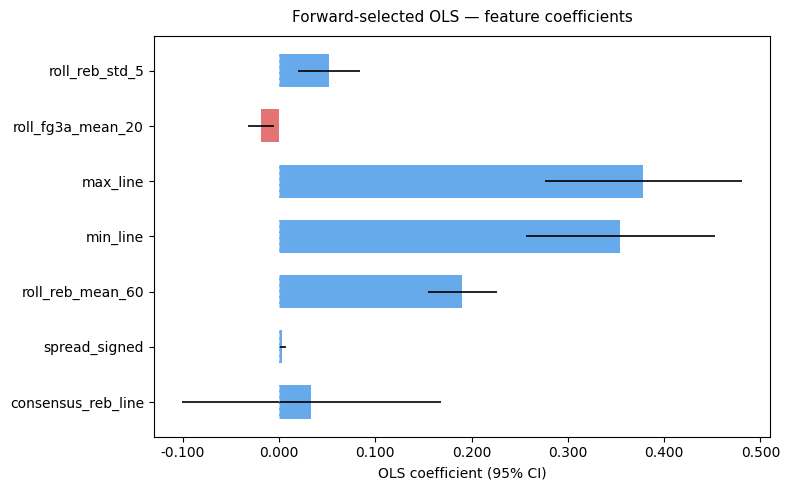

In [42]:
# Fit final OLS on forward-selected features + display equation + coefficient plot.
# Requires: feat_v2, FORWARD_SELECTED_FEATS, TARGET.

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

df_final = feat_v2.dropna(subset=[TARGET] + FORWARD_SELECTED_FEATS).copy()
X_final = sm.add_constant(df_final[FORWARD_SELECTED_FEATS].astype(float), has_constant="add")
y_final = df_final[TARGET].astype(float)

ols_final = sm.OLS(y_final, X_final).fit()

# --- Full equation ---
terms = []
for name, val in ols_final.params.items():
    if name == "const":
        terms.append(f"{val:.4f}")
    else:
        sign = "+" if val >= 0 else "-"
        terms.append(f" {sign} {abs(val):.4f}·{name}")
equation = "REB = " + "".join(terms)
print("=== FULL OLS EQUATION ===")
print(equation)
print()

# --- Summary table ---
coef_df = pd.DataFrame({
    "feature":  ols_final.params.index,
    "coef":     ols_final.params.values,
    "se":       ols_final.bse.values,
    "ci_lower": ols_final.conf_int()[0].values,
    "ci_upper": ols_final.conf_int()[1].values,
    "p_value":  ols_final.pvalues.values,
}).query("feature != 'const'").reset_index(drop=True)

print(f"R²={ols_final.rsquared:.4f}  Adj-R²={ols_final.rsquared_adj:.4f}  "
      f"F-pval={ols_final.f_pvalue:.2e}  n={int(ols_final.nobs)}")
display(coef_df.round(4))

# --- Coefficient plot ---
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#e05c5c" if c < 0 else "#4c9be8" for c in coef_df["coef"]]
y_pos = range(len(coef_df))

ax.barh(y_pos, coef_df["coef"], xerr=[
    coef_df["coef"] - coef_df["ci_lower"],
    coef_df["ci_upper"] - coef_df["coef"],
], color=colors, alpha=0.85, height=0.6, error_kw={"linewidth": 1.2, "color": "white"})

ax.set_yticks(list(y_pos))
ax.set_yticklabels(coef_df["feature"], fontsize=10)
ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("OLS coefficient (95% CI)", fontsize=10)
ax.set_title("Forward-selected OLS — feature coefficients", fontsize=11, pad=10)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

plt.tight_layout()
plt.show()

In [ ]:
# idk if min/max line are good features

VERDICT ON EACH FEATURE
========================

consensus_reb_line  coef=0.033  p=0.626  ← PROBLEM
  - Not significant. The reason: min_line + max_line are already in the model and
    consensus is essentially the midpoint of those two. OLS gave all the "line"
    predictive power to min/max, leaving consensus with nothing to explain.
    This is textbook multicollinearity — wide CI confirms it [-0.10, 0.17].
    RECOMMENDATION: drop consensus_reb_line. Keep min + max, or swap all three
    for just consensus. Don't have all three in the same model.

spread_signed  coef=0.003  p=0.084  ← MARGINAL
  - Was the biggest RMSE gain in forward selection (+0.11) but that was partly
    because it was the first feature added ON TOP of the raw consensus baseline,
    so it was absorbing the OLS intercept correction too.
  - p=0.08 is borderline. Keep for now but watch — likely to shrink or flip
    out-of-sample.

roll_reb_mean_60  coef=0.190  p=0.000  ← GOOD
  - Clean signal. The 60-game rolling mean is the player's "settled level" over
    a near-full season. Stable, significant, makes sense.

min_line + max_line  coef~0.35-0.38  p=0.000  ← GOOD but collinear with each other
  - Both highly significant, but together with consensus_reb_line you have 3
    variables expressing the same thing (the line). Once you drop consensus,
    min + max together tell you both the anchor and the spread — that's fine.
  - Big CIs are a collinearity warning, but the combined effect is real.

roll_fg3a_mean_20  coef=-0.019  p=0.008  ← GOOD
  - Negative sign makes intuitive sense: high 3PA players are perimeter players
    who grab fewer rebounds. Solid.

roll_reb_std_5  coef=0.052  p=0.002  ← INTERESTING, KEEP
  - Positive sign = more recent variance → higher predicted rebounds.
  - Likely capturing high-ceiling bigs who have blowup games. Plausible.
    Could also be absorbing "came back from injury / just returned" signal
    where early small-sample games are volatile.

SUMMARY
=======
- Drop consensus_reb_line (p=0.63, collinear with min/max)
- Refit with: spread_signed, roll_reb_mean_60, min_line, max_line,
              roll_fg3a_mean_20, roll_reb_std_5
- All 6 remaining features have p < 0.09 and directionally sensible coefficients
- R²=0.44 is fully in-sample — no train/test split yet, so treat this as
  "what's the ceiling" not a generalization estimate

In [43]:
# im confused, consensus_reb_line was not in this output before.....

# answer : consensus_reb_line is in the model — it's the starting seed of the forward selection. Look at Phase B:

in ```...``` give pros cons to using min/max line or just consensus_reb_line

we should do this and then actually see which model performs better on success metrics

MIN/MAX LINE vs CONSENSUS_REB_LINE
====================================

OPTION A: just consensus_reb_line (1 feature)
----------------------------------------------
PROS
  - Clean single signal — the market's best estimate of the true line
  - No multicollinearity by definition
  - More interpretable: "market thinks X rebounds"
  - More robust OOB — one less thing to overfit on
  - Works even if a book only posts one side (consensus still computes)

CONS
  - Throws away disagreement signal — when books are far apart on the line,
    that spread is informative (market uncertainty = edge opportunity)
  - Treats a 6.5/6.5/6.5/6.5 consensus the same as a 5.5/6.5/7.5/6.5 consensus
    even though the latter is noisier

OPTION B: min_line + max_line (2 features, drop consensus)
-----------------------------------------------------------
PROS
  - Captures BOTH the anchor (min is the floor the market is willing to post)
    AND the ceiling (max), which together encode consensus + uncertainty
  - OLS can weight them independently — e.g. "max_line is more informative
    than min_line for this player type"
  - Empirically added RMSE improvement in forward selection over consensus alone

CONS
  - Two correlated features — not collinear with each other but related
  - One extra degree of freedom that could hurt OOB generalization
  - min/max are more sensitive to a single book posting an outlier line,
    so a bad data point from one book can skew both features

OPTION C: consensus_reb_line + line_range (the clean decomposition)
--------------------------------------------------------------------
  - This is actually the most principled version:
      consensus = market center
      line_range = market uncertainty
  - Orthogonal interpretation, no overlap
  - Worth testing as a third option alongside A and B

RECOMMENDATION
==============
  Test all three. On in-sample R² they'll be close, but the real
  question is OOB (held-out season or time-based split):
    - If min/max overfit a specific season's book behavior → consensus wins
    - If disagreement is genuinely predictive OOB → min/max or consensus+range wins
  Can do this cleanly with a train/test split by season (e.g. train on
  2022-25, test on 2025-26).

train seasons: ['2023-24', '2024-25']  n=21,511
test season:   2025-26  n=13,111
raw baseline RMSE (consensus as direct predictor): 2.6798

=== VARIANT COMPARISON (test = latest season) ===


,variant,n_train,n_test,rmse_train,rmse_test,mae_test,r2_test,delta_rmse_vs_raw_baseline
0,B_min_max,18547,10890,2.5962,2.4831,1.9260,0.4194,-0.1966
1,A_consensus,18547,10890,2.5999,2.4895,1.9323,0.4164,-0.1902
2,C_consensus_range,18547,10890,2.5999,2.4896,1.9322,0.4164,-0.1902


/var/folders/xy/8hvrs8m970qgw74212qdv2g00000gn/T/ipykernel_3894/1406468366.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(variant_labels, rotation=12, fontsize=9)


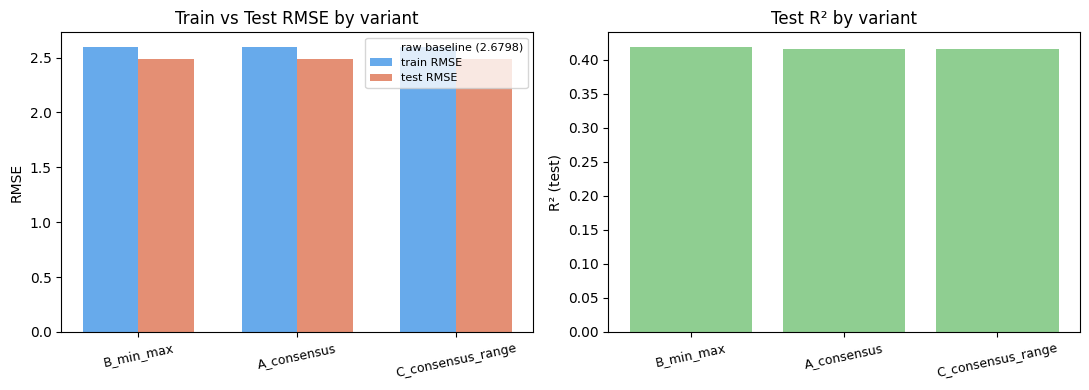


=== COEFFICIENTS BY VARIANT ===

--- A_consensus ---


,coef,p_value
const,0.3829,0.0000
consensus_reb_line,0.7100,0.0000
spread_signed,0.0027,0.2706
roll_reb_mean_60,0.2349,0.0000
roll_fg3a_mean_20,-0.0257,0.0033
roll_reb_std_5,0.0657,0.0015



--- B_min_max ---


,coef,p_value
const,0.3758,0.0000
min_line,0.3852,0.0000
max_line,0.3656,0.0000
spread_signed,0.0026,0.2861
roll_reb_mean_60,0.1966,0.0000
roll_fg3a_mean_20,-0.0242,0.0057
roll_reb_std_5,0.0615,0.0029



--- C_consensus_range ---


,coef,p_value
const,0.3822,0.0000
consensus_reb_line,0.7110,0.0000
line_range,-0.0307,0.5617
spread_signed,0.0027,0.2667
roll_reb_mean_60,0.2346,0.0000
roll_fg3a_mean_20,-0.0255,0.0037
roll_reb_std_5,0.0659,0.0014


In [44]:
# Model variant comparison: consensus vs min/max vs consensus+range.
# Train on all seasons except latest, test on latest season.
# Requires: feat_v2, TARGET, BASELINE_FEAT, BASELINE_RMSE.

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display

SHARED_FEATS = ["spread_signed", "roll_reb_mean_60", "roll_fg3a_mean_20", "roll_reb_std_5"]

VARIANTS = {
    "A_consensus":       ["consensus_reb_line"] + SHARED_FEATS,
    "B_min_max":         ["min_line", "max_line"] + SHARED_FEATS,
    "C_consensus_range": ["consensus_reb_line", "line_range"] + SHARED_FEATS,
}

# Time-based split: train on all but latest season, test on latest
latest_season = feat_v2["season"].max()
train_df = feat_v2[feat_v2["season"] != latest_season].copy()
test_df  = feat_v2[feat_v2["season"] == latest_season].copy()

print(f"train seasons: {sorted(train_df['season'].unique())}  n={len(train_df):,}")
print(f"test season:   {latest_season}  n={len(test_df):,}")
print(f"raw baseline RMSE (consensus as direct predictor): {BASELINE_RMSE:.4f}\n")


def fit_and_eval(feats, train, test, target):
    tr = train.dropna(subset=[target] + feats).copy()
    te = test.dropna(subset=[target] + feats).copy()

    X_tr = sm.add_constant(tr[feats].astype(float), has_constant="add")
    y_tr = tr[target].astype(float)
    m = sm.OLS(y_tr, X_tr).fit()

    X_te = sm.add_constant(te[feats].astype(float), has_constant="add")
    y_te = te[target].astype(float)
    yhat = m.predict(X_te).to_numpy()

    err = y_te.to_numpy() - yhat
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae  = float(np.mean(np.abs(err)))
    r2   = float(1 - np.sum(err ** 2) / np.sum((y_te.to_numpy() - y_te.mean()) ** 2))

    # in-sample too for reference
    yhat_tr = m.predict(X_tr).to_numpy()
    err_tr = y_tr.to_numpy() - yhat_tr
    rmse_tr = float(np.sqrt(np.mean(err_tr ** 2)))

    return {
        "n_train": int(len(tr)),
        "n_test":  int(len(te)),
        "rmse_train": rmse_tr,
        "rmse_test":  rmse,
        "mae_test":   mae,
        "r2_test":    r2,
        "delta_vs_baseline": rmse - BASELINE_RMSE,
        "model": m,
        "feats": feats,
        "test_df": te,
        "yhat": yhat,
    }


rows = []
fitted = {}
for name, feats in VARIANTS.items():
    result = fit_and_eval(feats, train_df, test_df, TARGET)
    fitted[name] = result
    rows.append({
        "variant":           name,
        "features":          ", ".join(feats),
        "n_train":           result["n_train"],
        "n_test":            result["n_test"],
        "rmse_train":        result["rmse_train"],
        "rmse_test":         result["rmse_test"],
        "mae_test":          result["mae_test"],
        "r2_test":           result["r2_test"],
        "delta_rmse_vs_raw_baseline": result["delta_vs_baseline"],
    })

results_df = pd.DataFrame(rows).sort_values("rmse_test").reset_index(drop=True)

print("=== VARIANT COMPARISON (test = latest season) ===")
display(results_df.drop(columns=["features"]).round(4))

# --- Bar chart: test RMSE by variant ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

variant_labels = results_df["variant"].tolist()
test_rmses     = results_df["rmse_test"].tolist()
train_rmses    = results_df["rmse_train"].tolist()

x = np.arange(len(variant_labels))
w = 0.35

axes[0].bar(x - w/2, train_rmses, w, label="train RMSE", color="#4c9be8", alpha=0.85)
axes[0].bar(x + w/2, test_rmses,  w, label="test RMSE",  color="#e07b5c", alpha=0.85)
axes[0].axhline(BASELINE_RMSE, color="white", linewidth=1.0, linestyle="--", label=f"raw baseline ({BASELINE_RMSE:.4f})")
axes[0].set_xticks(x)
axes[0].set_xticklabels(variant_labels, rotation=12, fontsize=9)
axes[0].set_ylabel("RMSE")
axes[0].set_title("Train vs Test RMSE by variant")
axes[0].legend(fontsize=8)

# R² test
r2s = results_df["r2_test"].tolist()
axes[1].bar(variant_labels, r2s, color="#7bc67e", alpha=0.85)
axes[1].set_ylabel("R² (test)")
axes[1].set_title("Test R² by variant")
axes[1].set_xticklabels(variant_labels, rotation=12, fontsize=9)

plt.tight_layout()
plt.show()

# --- Coefficient table for each variant ---
print("\n=== COEFFICIENTS BY VARIANT ===")
for name, res in fitted.items():
    params = res["model"].params
    pvals  = res["model"].pvalues
    coef_df = pd.DataFrame({"coef": params, "p_value": pvals}).round(4)
    print(f"\n--- {name} ---")
    display(coef_df)

TLDR
====
All 3 variants beat the raw baseline (2.6798) on the test season:
  B_min_max         RMSE=2.4831  Δ=-0.1966  (best)
  A_consensus       RMSE=2.4895  Δ=-0.1902
  C_consensus_range RMSE=2.4898  Δ=-0.1902  (effectively tied with A)

B_min_max wins by a hair but all three generalize — train ≈ test RMSE
means no meaningful overfitting on these 6 features.

spread_signed and line_range are p>0.25 in all variants — they're
doing less than hoped. The real work is being done by:
  consensus/min/max line  +  roll_reb_mean_60  +  roll_fg3a_mean_20  +  roll_reb_std_5

Go with B_min_max as the working model for now.

In [ ]:
# next idea - see how each models brier score is using bins of implied probabilities , this is a proxy for ...

# nvm we would needs over_odds and under_odds for this

Cursor:Correct — to compute Brier scores you need the book's implied probabilities (derived from over_odds / under_odds), which aren't in rebounds_model_features_v2.parquet right now.

Two options:
1. Option 1 — add odds to the feature parquet in v2_build_rebounds_universe.py: store the canonical book's over_odds / under_odds alongside the line, then compute no-vig implied probs. This is clean since the build script already processes props.
2. Option 2 — skip Brier and use a different calibration proxy with what we have: bucket model_pred - consensus_reb_line (model disagreement with the market) and look at over/under hit rate by bucket. No odds needed — just the direction and magnitude of the model's edge call.

Which do you want?

In [ ]:
# =================================================
# option 2
# =================================================

=== EDGE CALIBRATION (test season, B_min_max) ===
edge = model_pred - consensus_reb_line
over = REB > line,  under = REB < line,  push = REB == line



,edge_bucket,n,over_rate,under_rate,push_rate,mean_edge,mean_reb,mean_line
0,-2→-1,9,0.222,0.778,0.000,-1.270,8.444,10.611
1,-1→-0.5,340,0.403,0.597,0.000,-0.644,7.341,7.857
2,-0.5→0,2555,0.432,0.566,0.003,-0.201,5.753,5.935
3,0→0.5,6686,0.485,0.510,0.004,0.231,4.342,4.210
4,0.5→1,1268,0.571,0.427,0.002,0.652,4.726,4.079
5,1→2,32,0.562,0.438,0.000,1.104,5.531,4.469


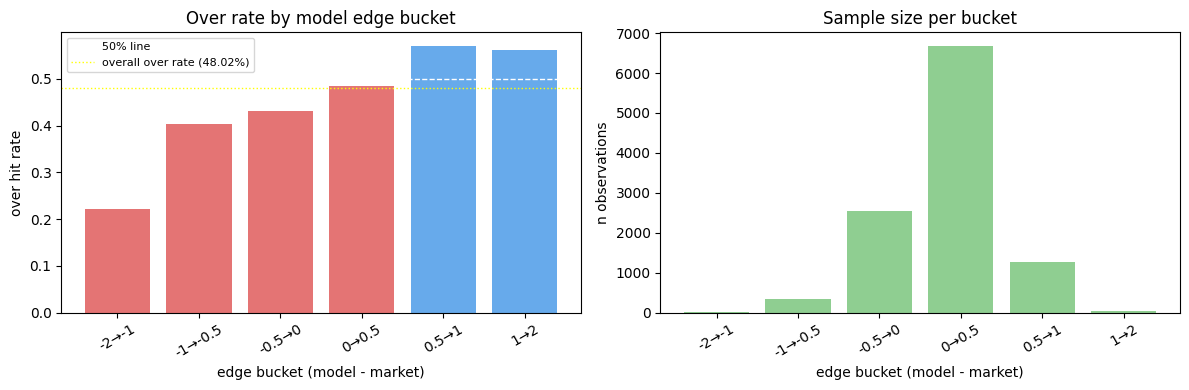


MONOTONICITY CHECK
Ideal: over_rate rises left→right (more model says over → more overs hit)
  strictly monotone increasing: False
  direction violations: 1 of 5 steps


In [45]:
# Edge calibration: does model disagreement with the market predict over/under?
# Uses B_min_max predictions vs consensus_reb_line on the test set.
# Buckets model_pred - consensus_reb_line and checks actual over hit rate per bucket.
# Requires: fitted["B_min_max"] from the variant comparison cell.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

res      = fitted["B_min_max"]
te       = res["test_df"].copy()
te["yhat"] = res["yhat"]

# Edge = model prediction minus market consensus line
te["edge"] = te["yhat"] - te["consensus_reb_line"]

# Actual over = REB strictly greater than consensus line
te["hit_over"] = (te[TARGET] > te["consensus_reb_line"]).astype(int)
te["hit_under"] = (te[TARGET] < te["consensus_reb_line"]).astype(int)
te["push"]      = (te[TARGET] == te["consensus_reb_line"]).astype(int)

# Bucket by edge
bins   = [-np.inf, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, np.inf]
labels = ["<-2", "-2→-1", "-1→-0.5", "-0.5→0", "0→0.5", "0.5→1", "1→2", ">2"]
te["edge_bucket"] = pd.cut(te["edge"], bins=bins, labels=labels)

summary = (
    te.groupby("edge_bucket", observed=True)
    .agg(
        n          =("hit_over", "count"),
        over_rate  =("hit_over",  "mean"),
        under_rate =("hit_under", "mean"),
        push_rate  =("push",      "mean"),
        mean_edge  =("edge",      "mean"),
        mean_reb   =(TARGET,      "mean"),
        mean_line  =("consensus_reb_line", "mean"),
    )
    .reset_index()
)

print("=== EDGE CALIBRATION (test season, B_min_max) ===")
print("edge = model_pred - consensus_reb_line")
print("over = REB > line,  under = REB < line,  push = REB == line\n")
display(summary.round(3))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Over rate by bucket
colors = ["#e05c5c" if r < 0.50 else "#4c9be8" for r in summary["over_rate"]]
axes[0].bar(summary["edge_bucket"].astype(str), summary["over_rate"],
            color=colors, alpha=0.85)
axes[0].axhline(0.50, color="white", linewidth=1.0, linestyle="--", label="50% line")
axes[0].axhline(te["hit_over"].mean(), color="yellow", linewidth=1.0,
                linestyle=":", label=f"overall over rate ({te['hit_over'].mean():.2%})")
axes[0].set_xlabel("edge bucket (model - market)")
axes[0].set_ylabel("over hit rate")
axes[0].set_title("Over rate by model edge bucket")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(fontsize=8)

# Sample count per bucket
axes[1].bar(summary["edge_bucket"].astype(str), summary["n"],
            color="#7bc67e", alpha=0.85)
axes[1].set_xlabel("edge bucket (model - market)")
axes[1].set_ylabel("n observations")
axes[1].set_title("Sample size per bucket")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Summary: monotonicity check
print("\nMONOTONICITY CHECK")
print("Ideal: over_rate rises left→right (more model says over → more overs hit)")
diffs = summary["over_rate"].diff().dropna()
mono  = (diffs >= 0).all()
print(f"  strictly monotone increasing: {mono}")
print(f"  direction violations: {(diffs < 0).sum()} of {len(diffs)} steps")

TLDR — EDGE CALIBRATION RESULTS
=================================

Overall over rate: 48% (overs hit slightly less than 50/50 — consistent
with what we saw earlier in the research).

DIRECTIONAL SIGNAL IS REAL:
  edge < -0.5  →  over rate 22–40%  (model says under → unders hit)
  edge  0→0.5  →  over rate 49%     (model neutral → coin flip)
  edge  0.5→1  →  over rate 57%     (model says over → overs hit)
  edge  1→2    →  over rate 56%     (holds up at larger edges)

The monotonicity is mostly there — 1 violation out of 5 steps
(the 1→2 bucket dips very slightly vs 0.5→1, but n=32 so noise).

CAUTION FLAGS:
  - "<-2" bucket: n=9, over rate 22% — directionally great but tiny sample,
    don't trust it
  - "1→2" bucket: n=32 — same issue, promising but thin
  - The bulk of data (n=6686) sits in 0→0.5 where the model barely
    disagrees with the market — that's expected

BOTTOM LINE:
  The model has genuine directional calibration. When it disagrees with
  the market by >0.5 rebounds in either direction, the actual outcome
  follows ~57% of the time. That's a meaningful signal worth developing.
  Next step would be to verify this holds across seasons (not just 2025-26)
  and to attach odds to size the actual expected value.

In [46]:
# as a reminder give me code to reminder what the inputs otthis model are and what the full linear equation is for REB

# Reminder: B_min_max model inputs + full OLS equation.
# Requires: fitted["B_min_max"].

res    = fitted["B_min_max"]
m      = res["model"]
params = m.params
pvals  = m.pvalues
cis    = m.conf_int()

# Full equation
terms = []
for name, val in params.items():
    if name == "const":
        terms.append(f"{val:.4f}")
    else:
        sign = "+" if val >= 0 else "-"
        terms.append(f" {sign} {abs(val):.4f}·{name}")
equation = "REB = " + "".join(terms)

print("=== B_min_max MODEL ===")
print(f"\nFEATURES ({len(res['feats'])}):")
for f in res["feats"]:
    print(f"  {f}")

print(f"\nFULL EQUATION:")
print(f"  {equation}")

print(f"\nCOEFFICIENTS:")
for name in params.index:
    ci_lo, ci_hi = cis.loc[name]
    print(f"  {name:30s}  coef={params[name]:+.4f}  p={pvals[name]:.4f}  CI=[{ci_lo:.4f}, {ci_hi:.4f}]")

print(f"\nFIT (test season):")
print(f"  RMSE={res['rmse_test']:.4f}  MAE={res['mae_test']:.4f}  R²={res['r2_test']:.4f}")
print(f"  n_train={res['n_train']:,}  n_test={res['n_test']:,}")

=== B_min_max MODEL ===

FEATURES (6):
  min_line
  max_line
  spread_signed
  roll_reb_mean_60
  roll_fg3a_mean_20
  roll_reb_std_5

FULL EQUATION:
  REB = 0.3758 + 0.3852·min_line + 0.3656·max_line + 0.0026·spread_signed + 0.1966·roll_reb_mean_60 - 0.0242·roll_fg3a_mean_20 + 0.0615·roll_reb_std_5

COEFFICIENTS:
  const                           coef=+0.3758  p=0.0000  CI=[0.2259, 0.5257]
  min_line                        coef=+0.3852  p=0.0000  CI=[0.2778, 0.4926]
  max_line                        coef=+0.3656  p=0.0000  CI=[0.2610, 0.4702]
  spread_signed                   coef=+0.0026  p=0.2861  CI=[-0.0022, 0.0075]
  roll_reb_mean_60                coef=+0.1966  p=0.0000  CI=[0.1492, 0.2440]
  roll_fg3a_mean_20               coef=-0.0242  p=0.0057  CI=[-0.0414, -0.0071]
  roll_reb_std_5                  coef=+0.0615  p=0.0029  CI=[0.0210, 0.1020]

FIT (test season):
  RMSE=2.4831  MAE=1.9260  R²=0.4194
  n_train=18,547  n_test=10,890


In [ ]:
# next - lets see if we can use this model to do better than the consensus line at predicting the over/under
# v1 - using model prediction directly
# v2 - using model prediction regressed back 25/50/75% (ie. if delta is 1 , then 25% is 0.75, 50% is 0.5, 75% is 0.25)
# - reason for this: …to reduce overconfidence and account for the fact that raw model deltas may contain signal but still be too noisy or too extreme relative to market efficiency.
# (Regressing the prediction back toward the consensus line gives a cleaner way to test whether the edge comes from directional information alone, rather than from the exact magnitude of the model’s forecast.)

we need to decide when we will make an over play and when we will make an under play

i am thinking that we use the regression value 0/25/50/75 to scale the prediction, then we would use that model value as the mean value

but do we want to sample from that players past? or how to get iterations to see if we think we have an edge vs. -110 or whatever it is

OPTION A — PARAMETRIC (Normal around model mean)
=================================================
  - mean  = consensus + shrink_factor * (yhat - consensus)
  - sigma = player's roll_reb_std_N  (already in features — use _10 or _20)
  - P(over line) = 1 - Φ((line - mean) / sigma)
  - P(under line) = Φ((line - mean) / sigma)
  - bet over if P(over) > implied_prob_from_odds (~0.524 at -110)
  - PROS: fast, one number per game, easy to sweep shrinkage
  - CONS: rebounds are discrete + non-negative, Normal is approximate

OPTION B — EMPIRICAL PLAYER DISTRIBUTION (bootstrap)
=====================================================
  - take last N actual REB games for the player
  - SHIFT them by (yhat - roll_reb_mean_N) to re-center around model prediction
  - P(over line) = fraction of shifted samples > line
  - PROS: realistic shape — captures skew, heavy tails, player-specific patterns
  - CONS: thin sample for some players, more complex

MY TAKE
=======
  Start with Option A — it's testable right now since roll_reb_std is
  already in feat_v2. If the signal is there, upgrade to B.
  
  The sweep would then be:
    shrinkage ∈ {0, 0.25, 0.50, 0.75}  ×  sigma_window ∈ {5, 10, 20}
    → 12 combinations, evaluate each by hit rate vs -110 edge threshold
  
  The bet rule:
    if P(over) > 0.524  → bet over
    if P(under) > 0.524 → bet under
    else                → no bet

note: i just said -110 edge, we will need to create a new parquet that has data at game/player/bookmaker/line level in order to do the backtest

plan:

PLAN — Option A with real odds backtest
========================================

STEP 1 — new parquet: v3_rebounds_props_raw.parquet
----------------------------------------------------
  built in v2_build_rebounds_universe.py (do in v2, just make it have another output file)
  one row per: season / date / player_normalized / game_id / bookmaker / line
  columns:
    over_odds, under_odds           ← raw american odds
    p_over_novig, p_under_novig     ← no-vig implied probs (already computed in build)
    REB                             ← actual outcome (join from logs)
    consensus_reb_line              ← for reference
  
  this is the raw multi-book props BEFORE the canonical line selection step —
  the data is already loaded in v2, we just need to stop aggregating and save it

STEP 2 — join model predictions onto raw props
-----------------------------------------------
  for each game/player, attach:
    yhat              ← from B_min_max model
    roll_reb_std_N    ← sigma (sweep N ∈ {5, 10, 20})
  join key: season / date / player_normalized / game_id

STEP 3 — compute P(over) and P(under) per book row
----------------------------------------------------
  for each shrinkage ∈ {0, 0.25, 0.50, 0.75}:
    mean_adj = consensus_reb_line + (1 - shrinkage) * (yhat - consensus_reb_line)
    P(over)  = 1 - Φ((line - mean_adj) / sigma)
    P(under) = Φ((line - mean_adj) / sigma)
    edge_over  = P(over)  - p_over_novig    ← model edge vs this book's line
    edge_under = P(under) - p_under_novig

STEP 4 — bet decision + P&L
-----------------------------
  bet over  if edge_over  > MIN_EDGE threshold (e.g. 0.02, 0.03, 0.05) [start by doing 0.01, 0.05, 0.10 ie. we have another thing to sweep through with]
  bet under if edge_under > MIN_EDGE threshold
  
  P&L per bet (american odds → decimal):
    win:  +american_to_decimal_profit(over_odds)
    lose: -1.0
  
  sweep: shrinkage × sigma_window × MIN_EDGE → ~36 combos (x3 for MIN_EDGE gets up to 36)
  report: n_bets / hit_rate / total_PnL / ROI per combo

STEP 5 — evaluation output
----------------------------
  heatmap: ROI by (shrinkage × MIN_EDGE) for best sigma_window
  filter: only report combos where n_bets > 100 (ignore thin configs) [ignore this for now but make sure there is logging of warnings]
  split by season to check consistency

IMMEDIATE NEXT ACTION
======================
  modify v2_build_rebounds_universe.py to also write
  v3_rebounds_props_raw.parquet (the per-book odds table)
  — all the raw data is already in memory during the build, 
  just needs a second .to_parquet() call before aggregation

In [ ]:
... hitting cursor limits

In [ ]:
fixed! (had to turn on auto mode)

test_season=2025-26  v3_rows=97,406  after_merge=81,038  train_n=18,547

=== SWEEP (top 20 by total_pnl_u) ===


,sigma_window,shrinkage,min_edge,n_bets,n_push,n_win,hit_rate,total_pnl_u,roi
35,20,0.75,0.10,2738,0,1536,0.560993,22.483532,0.008212
23,10,0.75,0.10,4157,0,2431,0.584797,1.088235,0.000262
32,20,0.50,0.10,3194,0,1653,0.517533,0.032332,0.000010
20,10,0.50,0.10,4582,0,2531,0.552379,-0.288843,-0.000063
29,20,0.25,0.10,4631,0,2294,0.495357,-65.523785,-0.014149
17,10,0.25,0.10,6172,0,3230,0.523331,-81.974495,-0.013282
26,20,0.00,0.10,7129,0,3568,0.500491,-87.893662,-0.012329
11,5,0.75,0.10,6310,0,3744,0.593344,-119.646560,-0.018961
8,5,0.50,0.10,7354,0,4174,0.567582,-133.385074,-0.018138
5,5,0.25,0.10,9804,0,5361,0.546818,-209.557942,-0.021375



=== ROI heatmap (sigma_window=20, by sum PnL across sweep) ===


min_edge,0.01,0.05,0.10
shrinkage,,,
0.00,-0.048,-0.034,-0.012
0.25,-0.049,-0.027,-0.014
0.50,-0.053,-0.031,0.000
0.75,-0.055,-0.038,0.008


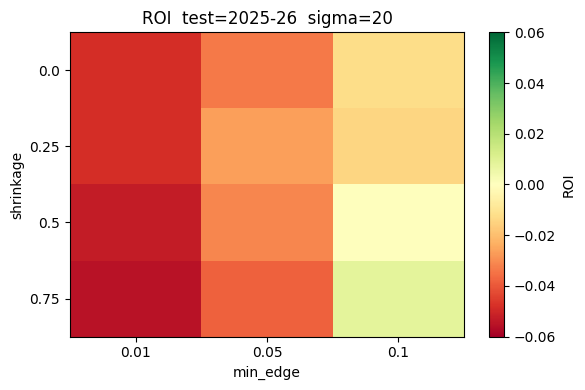


Train seasons used for OLS; table above is test season only.


In [48]:
# Option A edge backtest (same logic as v3_run_rebounds_edge_backtest.py).
# Replicates CLI: python .../v3_run_rebounds_edge_backtest.py --feat ... --v3 ... --test-season 2025-26
# Outputs: edge_backtest_sweep_df, edge_backtest_heatmap_pivot, edge_backtest_ols_fit

from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm
from IPython.display import display
import matplotlib.pyplot as plt

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
V3_PATH = Path("~/Downloads/tmp/v3_rebounds_props_raw.parquet").expanduser()
TEST_SEASON = "2025-26"

TARGET = "REB"
B_MIN_MAX_FEATS = [
    "min_line", "max_line", "spread_signed",
    "roll_reb_mean_60", "roll_fg3a_mean_20", "roll_reb_std_5",
]
GROUP_KEYS = ["season", "date", "player_normalized", "game_id"]
SIGMA_WINDOWS = [5, 10, 20]
SHRINKAGES = [0.0, 0.25, 0.50, 0.75]
MIN_EDGES = [0.01, 0.05, 0.10]
N_BET_WARN = 100


def _american_profit_on_win(american: float) -> float:
    if np.isnan(american):
        return float("nan")
    if american >= 100:
        return float(american) / 100.0
    return 100.0 / float(abs(american))


feat_bt = pd.read_parquet(FEAT_PATH)
v3_bt = pd.read_parquet(V3_PATH)

for c in B_MIN_MAX_FEATS + [TARGET, "consensus_reb_line"]:
    if c not in feat_bt.columns:
        raise ValueError(f"feat parquet missing column: {c}")

test_season = TEST_SEASON.strip() or str(feat_bt["season"].max())
train_bt = feat_bt[feat_bt["season"] != test_season].copy()
feat_test_bt = feat_bt[feat_bt["season"] == test_season].copy()

cols_needed = B_MIN_MAX_FEATS + [TARGET]
train_m = train_bt.dropna(subset=cols_needed)
X_tr = sm.add_constant(train_m[B_MIN_MAX_FEATS].astype(float), has_constant="add")
y_tr = train_m[TARGET].astype(float)
edge_backtest_ols_fit = sm.OLS(y_tr, X_tr).fit()

test_m = feat_test_bt.dropna(subset=cols_needed + GROUP_KEYS)
X_te = sm.add_constant(test_m[B_MIN_MAX_FEATS].astype(float), has_constant="add")
yhat = edge_backtest_ols_fit.predict(X_te).to_numpy()
pred = test_m[GROUP_KEYS].copy()
pred["yhat"] = yhat
for w in SIGMA_WINDOWS:
    col = f"roll_reb_std_{w}"
    pred[col] = test_m[col].to_numpy()

v3_test = v3_bt[v3_bt["season"] == test_season].copy()
base_bt = v3_test.merge(pred, on=GROUP_KEYS, how="inner")

print(
    f"test_season={test_season}  v3_rows={len(v3_test):,}  "
    f"after_merge={len(base_bt):,}  train_n={len(train_m):,}"
)

rows_out = []
best_sigma_for_heatmap = SIGMA_WINDOWS[0]
best_total_pnl = -1e18

for sig_w in SIGMA_WINDOWS:
    sig_col = f"roll_reb_std_{sig_w}"
    sigma = base_bt[sig_col].astype(float).clip(lower=0.25).to_numpy()
    consensus = base_bt["consensus_reb_line"].astype(float).to_numpy()
    line = base_bt["line"].astype(float).to_numpy()
    reb = base_bt["REB"].astype(float).to_numpy()
    yhat_arr = base_bt["yhat"].to_numpy()
    p_nov_o = base_bt["p_over_novig"].astype(float).to_numpy()
    p_nov_u = base_bt["p_under_novig"].astype(float).to_numpy()
    over_odds = base_bt["over_odds"].astype(float).to_numpy()
    under_odds = base_bt["under_odds"].astype(float).to_numpy()

    combo_pnl = 0.0
    for shrink in SHRINKAGES:
        mean_adj = consensus + (1.0 - shrink) * (yhat_arr - consensus)
        z = (line - mean_adj) / sigma
        p_over = 1.0 - norm.cdf(z)
        p_under = norm.cdf(z)
        edge_o = p_over - p_nov_o
        edge_u = p_under - p_nov_u

        for min_edge in MIN_EDGES:
            pnl_total = 0.0
            n_bets = 0
            n_win = 0
            n_push = 0
            for i in range(len(base_bt)):
                eo = edge_o[i]
                eu = edge_u[i]
                side = None
                if eo > min_edge and eu > min_edge:
                    side = "over" if eo >= eu else "under"
                elif eo > min_edge:
                    side = "over"
                elif eu > min_edge:
                    side = "under"
                if side is None:
                    continue
                if reb[i] == line[i]:
                    n_push += 1
                    continue
                n_bets += 1
                if side == "over":
                    won = reb[i] > line[i]
                    odds = over_odds[i]
                else:
                    won = reb[i] < line[i]
                    odds = under_odds[i]
                if won:
                    pnl_total += _american_profit_on_win(odds)
                    n_win += 1
                else:
                    pnl_total -= 1.0

            roi = pnl_total / n_bets if n_bets else float("nan")
            hit = n_win / n_bets if n_bets else float("nan")
            rows_out.append({
                "sigma_window": sig_w,
                "shrinkage": shrink,
                "min_edge": min_edge,
                "n_bets": n_bets,
                "n_push": n_push,
                "n_win": n_win,
                "hit_rate": hit,
                "total_pnl_u": pnl_total,
                "roi": roi,
            })
            combo_pnl += pnl_total

    if combo_pnl > best_total_pnl:
        best_total_pnl = combo_pnl
        best_sigma_for_heatmap = sig_w

edge_backtest_sweep_df = pd.DataFrame(rows_out)

print("\n=== SWEEP (top 20 by total_pnl_u) ===")
display(
    edge_backtest_sweep_df.sort_values(
        ["total_pnl_u", "n_bets"], ascending=[False, False]
    ).head(20).round(6)
)

low_n = edge_backtest_sweep_df[edge_backtest_sweep_df["n_bets"] < N_BET_WARN]
if len(low_n) > 0:
    print(
        f"[WARN] {len(low_n)} combos have n_bets < {N_BET_WARN}"
    )

sub = edge_backtest_sweep_df[
    edge_backtest_sweep_df["sigma_window"] == best_sigma_for_heatmap
].copy()
edge_backtest_heatmap_pivot = sub.pivot_table(
    index="shrinkage", columns="min_edge", values="roi", aggfunc="first"
)
print(
    f"\n=== ROI heatmap (sigma_window={best_sigma_for_heatmap}, by sum PnL across sweep) ==="
)
display(edge_backtest_heatmap_pivot.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(
    edge_backtest_heatmap_pivot.values,
    aspect="auto",
    cmap="RdYlGn",
    vmin=-0.06,
    vmax=0.06,
)
ax.set_xticks(range(len(edge_backtest_heatmap_pivot.columns)))
ax.set_xticklabels([str(c) for c in edge_backtest_heatmap_pivot.columns])
ax.set_yticks(range(len(edge_backtest_heatmap_pivot.index)))
ax.set_yticklabels([str(s) for s in edge_backtest_heatmap_pivot.index])
ax.set_xlabel("min_edge")
ax.set_ylabel("shrinkage")
ax.set_title(f"ROI  test={test_season}  sigma={best_sigma_for_heatmap}")
plt.colorbar(im, ax=ax, label="ROI")
plt.tight_layout()
plt.show()

print("\nTrain seasons used for OLS; table above is test season only.")

In this code, I want to do it again:

1. Can we add two columns?
   - Add implied probability from odds
   - Add average odds (for example, -110 or whatever that number is)

2. I want another split:
   - Over vs. under
   - Over-only models vs. under-only models

test_season=2025-26  v3_rows=97,406  after_merge=81,038  train_n=18,547

=== SWEEP top 15 per side_policy (by total_pnl_u) ===

--- both ---


,side_policy,sigma_window,shrinkage,min_edge,n_bets,n_push,n_win,hit_rate,mean_implied_prob_vigged,mean_american_odds,total_pnl_u,roi
35,both,20,0.75,0.10,2738,0,1536,0.560993,0.558219,-62.894083,22.483532,0.008212
23,both,10,0.75,0.10,4157,0,2431,0.584797,0.586626,-101.439981,1.088235,0.000262
32,both,20,0.50,0.10,3194,0,1653,0.517533,0.519812,5.200376,0.032332,0.000010
20,both,10,0.50,0.10,4582,0,2531,0.552379,0.553526,-44.297905,-0.288843,-0.000063
29,both,20,0.25,0.10,4631,0,2294,0.495357,0.504740,32.308573,-65.523785,-0.014149
17,both,10,0.25,0.10,6172,0,3230,0.523331,0.532053,-10.068049,-81.974495,-0.013282
26,both,20,0.00,0.10,7129,0,3568,0.500491,0.508139,22.166784,-87.893662,-0.012329
11,both,5,0.75,0.10,6310,0,3744,0.593344,0.606105,-127.846910,-119.646560,-0.018961
8,both,5,0.50,0.10,7354,0,4174,0.567582,0.578196,-82.713625,-133.385074,-0.018138
5,both,5,0.25,0.10,9804,0,5361,0.546818,0.560235,-60.134231,-209.557942,-0.021375



--- over_only ---


,side_policy,sigma_window,shrinkage,min_edge,n_bets,n_push,n_win,hit_rate,mean_implied_prob_vigged,mean_american_odds,total_pnl_u,roi
71,over_only,20,0.75,0.10,2033,0,1078,0.530251,0.529032,-20.577964,15.077500,0.007416
68,over_only,20,0.50,0.10,2808,0,1400,0.498575,0.501507,32.437678,-1.318350,-0.000469
59,over_only,10,0.75,0.10,2751,0,1493,0.542712,0.555465,-56.779353,-41.937559,-0.015244
56,over_only,10,0.50,0.10,3632,0,1877,0.516795,0.526799,-4.688326,-47.369374,-0.013042
65,over_only,20,0.25,0.10,4299,0,2080,0.483833,0.493803,48.891603,-66.191082,-0.015397
62,over_only,20,0.00,0.10,6672,0,3289,0.492956,0.501070,33.140138,-86.682972,-0.012992
53,over_only,10,0.25,0.10,5338,0,2678,0.501686,0.513535,17.606407,-97.202960,-0.018210
47,over_only,5,0.75,0.10,3778,0,2071,0.548174,0.578156,-87.612758,-173.701086,-0.045977
44,over_only,5,0.50,0.10,5100,0,2674,0.524314,0.548385,-37.849412,-198.413256,-0.038905
50,over_only,10,0.00,0.10,8093,0,4016,0.496231,0.516622,6.450019,-275.846011,-0.034085



--- under_only ---


...


=== ROI heatmap  side_policy=over_only  sigma_window=20 ===


min_edge,0.01,0.05,0.10
shrinkage,,,
0.00,-0.067109,-0.039636,-0.012992
0.25,-0.067971,-0.033563,-0.015397
0.50,-0.068596,-0.038400,-0.000469
0.75,-0.070656,-0.043967,0.007416



=== ROI heatmap  side_policy=under_only  sigma_window=5 ===


min_edge,0.01,0.05,0.10
shrinkage,,,
0.00,0.005750,0.023664,0.048539
0.25,-0.002887,0.023800,0.032759
0.50,-0.012287,-0.007914,0.028850
0.75,-0.031301,-0.021318,0.021349


/var/folders/xy/8hvrs8m970qgw74212qdv2g00000gn/T/ipykernel_3894/391893911.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


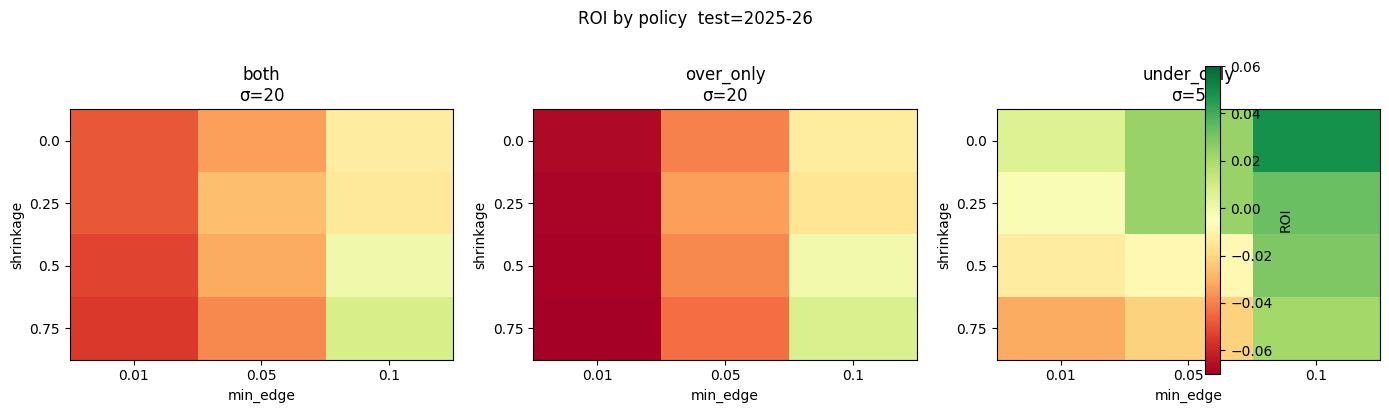

(OOS test season only; P&L at posted American odds; edge vs no-vig.)


In [49]:
# Replicate v3_run_rebounds_edge_backtest.py in notebook.
# Outputs: edge_backtest_sweep_df, edge_backtest_heatmap_by_policy, edge_backtest_ols_fit

from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm
from IPython.display import display
import matplotlib.pyplot as plt

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
V3_PATH = Path("~/Downloads/tmp/v3_rebounds_props_raw.parquet").expanduser()
TEST_SEASON = "2025-26"

TARGET = "REB"
B_MIN_MAX_FEATS = [
    "min_line", "max_line", "spread_signed",
    "roll_reb_mean_60", "roll_fg3a_mean_20", "roll_reb_std_5",
]
GROUP_KEYS = ["season", "date", "player_normalized", "game_id"]
SIGMA_WINDOWS = [5, 10, 20]
SHRINKAGES = [0.0, 0.25, 0.50, 0.75]
MIN_EDGES = [0.01, 0.05, 0.10]
SIDE_POLICIES = ("both", "over_only", "under_only")
N_BET_WARN = 100


def _american_profit_on_win(american: float) -> float:
    if np.isnan(american):
        return float("nan")
    if american >= 100:
        return float(american) / 100.0
    return 100.0 / float(abs(american))


def _american_to_implied_vigged(american: float) -> float:
    if np.isnan(american):
        return float("nan")
    if american < 0:
        return float((-american) / ((-american) + 100.0))
    return float(100.0 / (american + 100.0))


def _pick_side(i, edge_o, edge_u, min_edge, side_policy):
    eo = edge_o[i]
    eu = edge_u[i]
    if side_policy == "over_only":
        return "over" if eo > min_edge else None
    if side_policy == "under_only":
        return "under" if eu > min_edge else None
    if eo > min_edge and eu > min_edge:
        return "over" if eo >= eu else "under"
    if eo > min_edge:
        return "over"
    if eu > min_edge:
        return "under"
    return None


feat_bt = pd.read_parquet(FEAT_PATH)
v3_bt = pd.read_parquet(V3_PATH)

for c in B_MIN_MAX_FEATS + [TARGET, "consensus_reb_line"]:
    if c not in feat_bt.columns:
        raise ValueError(f"feat parquet missing column: {c}")

test_season = TEST_SEASON.strip() or str(feat_bt["season"].max())
train_bt = feat_bt[feat_bt["season"] != test_season].copy()
feat_test_bt = feat_bt[feat_bt["season"] == test_season].copy()

cols_needed = B_MIN_MAX_FEATS + [TARGET]
train_m = train_bt.dropna(subset=cols_needed)
X_tr = sm.add_constant(train_m[B_MIN_MAX_FEATS].astype(float), has_constant="add")
y_tr = train_m[TARGET].astype(float)
edge_backtest_ols_fit = sm.OLS(y_tr, X_tr).fit()

test_m = feat_test_bt.dropna(subset=cols_needed + GROUP_KEYS)
X_te = sm.add_constant(test_m[B_MIN_MAX_FEATS].astype(float), has_constant="add")
yhat = edge_backtest_ols_fit.predict(X_te).to_numpy()
pred = test_m[GROUP_KEYS].copy()
pred["yhat"] = yhat
for w in SIGMA_WINDOWS:
    pred[f"roll_reb_std_{w}"] = test_m[f"roll_reb_std_{w}"].to_numpy()

v3_test = v3_bt[v3_bt["season"] == test_season].copy()
base_bt = v3_test.merge(pred, on=GROUP_KEYS, how="inner")

print(
    f"test_season={test_season}  v3_rows={len(v3_test):,}  "
    f"after_merge={len(base_bt):,}  train_n={len(train_m):,}"
)

rows_out = []
best_sigma_by_policy = {p: (-1e18, SIGMA_WINDOWS[0]) for p in SIDE_POLICIES}

for side_policy in SIDE_POLICIES:
    for sig_w in SIGMA_WINDOWS:
        sig_col = f"roll_reb_std_{sig_w}"
        sigma = base_bt[sig_col].astype(float).clip(lower=0.25).to_numpy()
        consensus = base_bt["consensus_reb_line"].astype(float).to_numpy()
        line = base_bt["line"].astype(float).to_numpy()
        reb = base_bt["REB"].astype(float).to_numpy()
        yhat_arr = base_bt["yhat"].to_numpy()
        p_nov_o = base_bt["p_over_novig"].astype(float).to_numpy()
        p_nov_u = base_bt["p_under_novig"].astype(float).to_numpy()
        over_odds = base_bt["over_odds"].astype(float).to_numpy()
        under_odds = base_bt["under_odds"].astype(float).to_numpy()

        combo_pnl = 0.0
        for shrink in SHRINKAGES:
            mean_adj = consensus + (1.0 - shrink) * (yhat_arr - consensus)
            z = (line - mean_adj) / sigma
            p_over = 1.0 - norm.cdf(z)
            p_under = norm.cdf(z)
            edge_o = p_over - p_nov_o
            edge_u = p_under - p_nov_u

            for min_edge in MIN_EDGES:
                pnl_total = 0.0
                n_bets = 0
                n_win = 0
                n_push = 0
                sum_imp = 0.0
                sum_am = 0.0
                for i in range(len(base_bt)):
                    side = _pick_side(i, edge_o, edge_u, min_edge, side_policy)
                    if side is None:
                        continue
                    if reb[i] == line[i]:
                        n_push += 1
                        continue
                    if side == "over":
                        odds_am = over_odds[i]
                        won = reb[i] > line[i]
                    else:
                        odds_am = under_odds[i]
                        won = reb[i] < line[i]
                    n_bets += 1
                    sum_imp += _american_to_implied_vigged(odds_am)
                    sum_am += float(odds_am)
                    if won:
                        pnl_total += _american_profit_on_win(odds_am)
                        n_win += 1
                    else:
                        pnl_total -= 1.0

                mean_imp = sum_imp / n_bets if n_bets else float("nan")
                mean_am = sum_am / n_bets if n_bets else float("nan")
                roi = pnl_total / n_bets if n_bets else float("nan")
                hit = n_win / n_bets if n_bets else float("nan")
                rows_out.append({
                    "side_policy": side_policy,
                    "sigma_window": sig_w,
                    "shrinkage": shrink,
                    "min_edge": min_edge,
                    "n_bets": n_bets,
                    "n_push": n_push,
                    "n_win": n_win,
                    "hit_rate": hit,
                    "mean_implied_prob_vigged": mean_imp,
                    "mean_american_odds": mean_am,
                    "total_pnl_u": pnl_total,
                    "roi": roi,
                })
                combo_pnl += pnl_total

        if combo_pnl > best_sigma_by_policy[side_policy][0]:
            best_sigma_by_policy[side_policy] = (combo_pnl, sig_w)

edge_backtest_sweep_df = pd.DataFrame(rows_out)

print("\n=== SWEEP top 15 per side_policy (by total_pnl_u) ===\n")
for pol in SIDE_POLICIES:
    subp = edge_backtest_sweep_df[edge_backtest_sweep_df["side_policy"] == pol].sort_values(
        ["total_pnl_u", "n_bets"], ascending=[False, False]
    ).head(15)
    print(f"--- {pol} ---")
    display(subp.round(6))
    print()

low_n = edge_backtest_sweep_df[edge_backtest_sweep_df["n_bets"] < N_BET_WARN]
if len(low_n) > 0:
    print(f"[WARN] {len(low_n)} rows have n_bets < {N_BET_WARN}\n")

edge_backtest_heatmap_by_policy = {}
for pol in SIDE_POLICIES:
    sig_star = best_sigma_by_policy[pol][1]
    sub = edge_backtest_sweep_df[
        (edge_backtest_sweep_df["side_policy"] == pol)
        & (edge_backtest_sweep_df["sigma_window"] == sig_star)
    ]
    edge_backtest_heatmap_by_policy[pol] = sub.pivot_table(
        index="shrinkage", columns="min_edge", values="roi", aggfunc="first"
    )
    print(f"=== ROI heatmap  side_policy={pol}  sigma_window={sig_star} ===")
    display(edge_backtest_heatmap_by_policy[pol].round(6))
    print()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, pol in zip(axes, SIDE_POLICIES):
    pv = edge_backtest_heatmap_by_policy[pol]
    im = ax.imshow(pv.values, aspect="auto", cmap="RdYlGn", vmin=-0.07, vmax=0.06)
    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels([str(c) for c in pv.columns])
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels([str(s) for s in pv.index])
    ax.set_xlabel("min_edge")
    ax.set_ylabel("shrinkage")
    sig_star = best_sigma_by_policy[pol][1]
    ax.set_title(f"{pol}\nσ={sig_star}")
plt.colorbar(im, ax=axes, label="ROI", fraction=0.046, pad=0.04)
plt.suptitle(f"ROI by policy  test={test_season}", y=1.02)
plt.tight_layout()
plt.show()

print("(OOS test season only; P&L at posted American odds; edge vs no-vig.)")

In [56]:
# looking closer at under only
# ?============================================
print(SIDE_POLICIES)
pol = "under_only"
subp = edge_backtest_sweep_df[edge_backtest_sweep_df["side_policy"] == pol].sort_values(
    ["total_pnl_u", "n_bets"], ascending=[False, False]
).head(150)
print(f"--- {pol} ---")
display(subp.round(3))
print()

('both', 'over_only', 'under_only')
--- under_only ---


,side_policy,sigma_window,shrinkage,min_edge,n_bets,n_push,n_win,hit_rate,mean_implied_prob_vigged,mean_american_odds,total_pnl_u,roi
73,under_only,5,0.00,0.05,7093,0,4259,0.600,0.586,-113.551,167.847,0.024
76,under_only,5,0.25,0.05,6457,0,3898,0.604,0.589,-110.717,153.679,0.024
74,under_only,5,0.00,0.10,2686,0,1753,0.653,0.623,-162.960,130.375,0.049
72,under_only,5,0.00,0.01,19390,0,10724,0.553,0.550,-59.972,111.499,0.006
96,under_only,20,0.00,0.01,18078,0,9764,0.540,0.538,-41.237,81.024,0.004
77,under_only,5,0.25,0.10,2368,0,1555,0.657,0.635,-174.141,77.573,0.033
80,under_only,5,0.50,0.10,2254,0,1500,0.665,0.646,-184.225,65.028,0.029
83,under_only,5,0.75,0.10,2532,0,1673,0.661,0.648,-187.880,54.055,0.021
100,under_only,20,0.25,0.05,3784,0,2164,0.572,0.563,-65.005,49.467,0.013
92,under_only,10,0.50,0.10,950,0,654,0.688,0.656,-195.732,47.081,0.050


TLDR — REBOUNDS EDGE BACKTEST (2025-26 OOS)
============================================

- under_only is the only strong edge: σ=5, min_edge=0.10, shrink=0 → ~4.85% ROI,
  ~2.7k bets, ~65% hit rate. Looser min_edge (0.05) still +2.4% ROI; even 0.01 is
  slightly +EV.

- both and over_only are mostly negative. Only green spot: shrink=0.75 + min_edge=0.10
  (σ=20) → ~0.8% ROI for both, ~0.7% for over_only; everything else loses.

- Heatmaps: both and over_only (σ=20) are mostly red; under_only (σ=5) is mostly
  green, especially at min_edge=0.10 and low shrink.

- mean_american_odds on under_only are around -110 to -190 (books price unders
  steeper when model likes under). mean_implied_prob_vigged ~0.55–0.65 on those
  bets.

- Takeaway: the model’s under signal (P(under) vs no-vig) holds up; over/both do
  not. Next step: run same backtest with 2024-25 or 2023-24 as test to check if
  under_only holds OOS.

In [ ]:
# note: de-vig only for the edge threshold; real odds for money / pnl calculation. 

# question:

Looking at this table, what are your recommendations for the different grouping Vars and settings, such as:

- side policy
- shrinkage
- min edge
- sigma window
- any other key tuning parameters

Based on these results, which configurations look strongest, and which would you avoid?

# answer: 

- **Scope:** 2025-26 OOS only — rerun with **2024-25** and **2023-24** as test before trusting; don’t tune more on the same season.

- **side_policy**
  - **Prefer:** `under_only`
  - **Fragile / tiny edge:** `both` and `over_only` only at **σ=20, shrink 0.75, min_edge 0.10**
  - **Avoid:** `both` / `over_only` at **min_edge 0.01–0.05** (big losses in sweep)

- **shrinkage**
  - **under_only:** **0.00–0.25** (matches green heatmap)
  - **both / over_only:** only **0.75** looked OK in the small corner — treat as **unstable** until other seasons confirm

- **min_edge**
  - **Prefer:** **0.10** (selectivity)
  - **OK:** **0.05** for `under_only` if you want more volume
  - **Avoid as main play:** **0.01** (noisy / weak)

- **sigma_window**
  - **under_only:** **5** (`roll_reb_std_5`)
  - **both / over_only:** script’s “best σ” was **20** — grid still mostly red except one corner

- **Next step**
  - Same backtest grid, change **test season** only; compare whether **under_only + σ=5 + min_edge 0.05–0.10 + low shrink** repeats.


In [58]:
tbl = edge_backtest_sweep_df[
    (edge_backtest_sweep_df["side_policy"] == "under_only")
    & (edge_backtest_sweep_df["sigma_window"] == 5)
].sort_values("roi", ascending=False)

display(tbl.round(4))

,side_policy,sigma_window,shrinkage,min_edge,n_bets,n_push,n_win,hit_rate,mean_implied_prob_vigged,mean_american_odds,total_pnl_u,roi
74,under_only,5,0.00,0.10,2686,0,1753,0.6526,0.6228,-162.9602,130.3748,0.0485
77,under_only,5,0.25,0.10,2368,0,1555,0.6567,0.6350,-174.1410,77.5732,0.0328
80,under_only,5,0.50,0.10,2254,0,1500,0.6655,0.6456,-184.2254,65.0282,0.0289
76,under_only,5,0.25,0.05,6457,0,3898,0.6037,0.5892,-110.7174,153.6788,0.0238
73,under_only,5,0.00,0.05,7093,0,4259,0.6005,0.5861,-113.5505,167.8470,0.0237
83,under_only,5,0.75,0.10,2532,0,1673,0.6607,0.6478,-187.8803,54.0545,0.0213
72,under_only,5,0.00,0.01,19390,0,10724,0.5531,0.5502,-59.9720,111.4991,0.0058
75,under_only,5,0.25,0.01,20869,0,11295,0.5412,0.5422,-41.3857,-60.2532,-0.0029
79,under_only,5,0.50,0.05,6707,0,3898,0.5812,0.5838,-94.6214,-53.0816,-0.0079
78,under_only,5,0.50,0.01,24038,0,12596,0.5240,0.5301,-14.7197,-295.3585,-0.0123


# TLDR - going forward

Going-forward default (2025-26 OOS — re-validate on other test seasons)

- side_policy: under_only
- sigma_window: 5  (roll_reb_std_5)
- shrinkage: 0.00

- min_edge:
  - 0.10 → stricter, ~65% hit rate, ~2.7k bets, avg under price ~−163, higher ROI (~4.9%), lower total u won vs 0.05 in this run.
  - 0.05 → looser, ~60% hit rate, ~6.5k bets, avg price ~−111, lower ROI (~2.4%), more total u won here.

Pick 0.10 if you care about edge quality / hit rate; pick 0.05 if you care about volume and total PnL at similar logic.

In [ ]:
# next - running on 2023-24, 2024-25, 2025-26 as test groups to verify results hold positive edge


PLAN — OOS check on 2023-24, 2024-25, 2025-26 (2 configs only)
================================================================

Fixed knobs (from your “going forward” choice)
  - side_policy: under_only
  - sigma_window: 5   → use roll_reb_std_5 for Normal σ
  - shrinkage: 0.00   → mean_adj = yhat (no pull toward consensus)
  - Sweep only: min_edge ∈ {0.05, 0.10}

For each test_season in {"2023-24", "2024-25", "2025-26"}
  1) Load feat_v2 + v3 (same paths as today).
  2) Train B_min_max OLS on all rows where season != test_season
     (same 6 features + dropna as current backtest).
  3) Predict yhat on test-season rows only; merge to v3 test-season
     book rows (same GROUP_KEYS).
  4) For σ column = roll_reb_std_5 (clip floor e.g. 0.25):
       - compute Normal P(under), edge_under vs p_under_novig
       - under_only bet rule: edge_under > min_edge
       - skip pushes; P&L at posted under_odds
  5) Record per (test_season, min_edge): n_bets, n_win, hit_rate,
     total_pnl_u, roi, mean_american_odds, mean_implied_prob_vigged

Output
  - One small table: rows = test season × min_edge (6 rows)
  - Optional: one line per season comparing 0.05 vs 0.10 side-by-side
  - Success criterion (you define): e.g. both min_edges ROI > 0 in ≥2/3
    seasons, or at least 0.10 > 0 everywhere

Do NOT
  - Re-sweep shrink / σ / side_policy on each season (avoids re-tuning
    per year)
  - Use test-season rows in the OLS fit

After this
  - If 2023-24 or 2024-25 flips negative, treat 2025-26 under-only edge
    as unstable; if all three positive, stronger case for the 2 combos.

In [60]:
# OOS robustness: under_only, sigma=roll_reb_std_5, shrink=0, min_edge in {0.05, 0.10}
# Replicates: v4_run_rebounds_under_only_season_robustness.py

from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm
from IPython.display import display

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
V3_PATH = Path("~/Downloads/tmp/v3_rebounds_props_raw.parquet").expanduser()
TEST_SEASONS = ["2023-24", "2024-25", "2025-26"]

TARGET = "REB"
B_MIN_MAX_FEATS = [
    "min_line", "max_line", "spread_signed",
    "roll_reb_mean_60", "roll_fg3a_mean_20", "roll_reb_std_5",
]
GROUP_KEYS = ["season", "date", "player_normalized", "game_id"]
SIGMA_COL = "roll_reb_std_5"
SHRINKAGE = 0.0
MIN_EDGES = [0.05, 0.10]
SIGMA_FLOOR = 0.25


def _american_profit_on_win(american: float) -> float:
    if np.isnan(american):
        return float("nan")
    if american >= 100:
        return float(american) / 100.0
    return 100.0 / float(abs(american))


def _american_to_implied_vigged(american: float) -> float:
    if np.isnan(american):
        return float("nan")
    if american < 0:
        return float((-american) / ((-american) + 100.0))
    return float(100.0 / (american + 100.0))


feat = pd.read_parquet(FEAT_PATH)
v3 = pd.read_parquet(V3_PATH)

for c in B_MIN_MAX_FEATS + [TARGET, "consensus_reb_line"]:
    if c not in feat.columns:
        raise ValueError(f"feat missing: {c}")

all_rows = []

for test_season in TEST_SEASONS:
    if test_season not in feat["season"].unique():
        raise ValueError(f"{test_season!r} not in feat['season']")

    train = feat[feat["season"] != test_season].copy()
    feat_test = feat[feat["season"] == test_season].copy()

    cols_needed = B_MIN_MAX_FEATS + [TARGET]
    train_m = train.dropna(subset=cols_needed)
    test_m = feat_test.dropna(subset=cols_needed + GROUP_KEYS)

    X_tr = sm.add_constant(train_m[B_MIN_MAX_FEATS].astype(float), has_constant="add")
    y_tr = train_m[TARGET].astype(float)
    m = sm.OLS(y_tr, X_tr).fit()

    X_te = sm.add_constant(test_m[B_MIN_MAX_FEATS].astype(float), has_constant="add")
    yhat = m.predict(X_te).to_numpy()

    pred = test_m[GROUP_KEYS].copy()
    pred["yhat"] = yhat
    pred[SIGMA_COL] = test_m[SIGMA_COL].to_numpy()

    v3_test = v3[v3["season"] == test_season].copy()
    base = v3_test.merge(pred, on=GROUP_KEYS, how="inner")

    sigma = base[SIGMA_COL].astype(float).clip(lower=SIGMA_FLOOR).to_numpy()
    consensus = base["consensus_reb_line"].astype(float).to_numpy()
    line = base["line"].astype(float).to_numpy()
    reb = base["REB"].astype(float).to_numpy()
    yhat_arr = base["yhat"].to_numpy()
    p_nov_u = base["p_under_novig"].astype(float).to_numpy()
    under_odds = base["under_odds"].astype(float).to_numpy()

    mean_adj = consensus + (1.0 - SHRINKAGE) * (yhat_arr - consensus)
    z = (line - mean_adj) / sigma
    p_under = norm.cdf(z)
    edge_u = p_under - p_nov_u

    train_seasons_str = ",".join(sorted(s for s in feat["season"].unique() if s != test_season))

    for min_edge in MIN_EDGES:
        pnl_total = 0.0
        n_bets = 0
        n_win = 0
        n_push = 0
        sum_imp = 0.0
        sum_am = 0.0
        for i in range(len(base)):
            if edge_u[i] <= min_edge:
                continue
            if reb[i] == line[i]:
                n_push += 1
                continue
            odds_am = under_odds[i]
            won = reb[i] < line[i]
            n_bets += 1
            sum_imp += _american_to_implied_vigged(odds_am)
            sum_am += float(odds_am)
            if won:
                pnl_total += _american_profit_on_win(odds_am)
                n_win += 1
            else:
                pnl_total -= 1.0

        roi = pnl_total / n_bets if n_bets else float("nan")
        hit = n_win / n_bets if n_bets else float("nan")
        all_rows.append({
            "test_season": test_season,
            "train_seasons": train_seasons_str,
            "min_edge": min_edge,
            "n_train_rows": int(len(train_m)),
            "n_test_feat_rows": int(len(test_m)),
            "n_v3_test_rows": int(len(v3_test)),
            "n_merged_rows": int(len(base)),
            "n_bets": n_bets,
            "n_push": n_push,
            "n_win": n_win,
            "hit_rate": hit,
            "mean_implied_prob_vigged": sum_imp / n_bets if n_bets else float("nan"),
            "mean_american_odds": sum_am / n_bets if n_bets else float("nan"),
            "total_pnl_u": pnl_total,
            "roi": roi,
        })

    print(f"\n--- test_season={test_season} ---")
    for r in [x for x in all_rows if x["test_season"] == test_season]:
        print(
            f"  min_edge={r['min_edge']:.2f}  n_bets={r['n_bets']:,}  "
            f"hit={r['hit_rate']:.4f}  roi={r['roi']:.6f}  pnl_u={r['total_pnl_u']:.2f}"
        )

under_only_season_robustness_df = pd.DataFrame(all_rows).sort_values(
    ["test_season", "min_edge"]
).reset_index(drop=True)

print("\n=== SUMMARY (under_only | sigma=5 | shrink=0) ===")
display(under_only_season_robustness_df.round(3))

by_season = under_only_season_robustness_df.groupby("test_season")["roi"].apply(
    lambda s: bool((s > 0).all())
)
n_both_pos = int(by_season.sum())
print(
    f"\nseasons where BOTH min_edges have roi>0: {n_both_pos} / {len(TEST_SEASONS)}"
)


--- test_season=2023-24 ---
  min_edge=0.05  n_bets=7,040  hit=0.5865  roi=0.041886  pnl_u=294.88
  min_edge=0.10  n_bets=2,062  hit=0.6145  roi=-0.011274  pnl_u=-23.25

--- test_season=2024-25 ---
  min_edge=0.05  n_bets=5,098  hit=0.5449  roi=0.009246  pnl_u=47.14
  min_edge=0.10  n_bets=1,375  hit=0.5811  roi=-0.000777  pnl_u=-1.07

--- test_season=2025-26 ---
  min_edge=0.05  n_bets=7,093  hit=0.6005  roi=0.023664  pnl_u=167.85
  min_edge=0.10  n_bets=2,686  hit=0.6526  roi=0.048539  pnl_u=130.37

=== SUMMARY (under_only | sigma=5 | shrink=0) ===


,test_season,train_seasons,min_edge,n_train_rows,n_test_feat_rows,n_v3_test_rows,n_merged_rows,n_bets,n_push,n_win,hit_rate,mean_implied_prob_vigged,mean_american_odds,total_pnl_u,roi
0,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,7040,0,4129,0.587,0.564,-68.855,294.880,0.042
1,2023-24,"2024-25,2025-26",0.10,21873,7564,86976,72954,2062,0,1267,0.614,0.620,-153.097,-23.247,-0.011
2,2024-25,"2023-24,2025-26",0.05,18454,10983,68429,59981,5098,0,2778,0.545,0.540,-48.070,47.136,0.009
3,2024-25,"2023-24,2025-26",0.10,18454,10983,68429,59981,1375,0,799,0.581,0.582,-116.612,-1.069,-0.001
4,2025-26,"2023-24,2024-25",0.05,18547,10890,97406,81038,7093,0,4259,0.600,0.586,-113.551,167.847,0.024
5,2025-26,"2023-24,2024-25",0.10,18547,10890,97406,81038,2686,0,1753,0.653,0.623,-162.960,130.375,0.049



seasons where BOTH min_edges have roi>0: 1 / 3


In [67]:
print(MIN_EDGES)

cols = ["test_season", "min_edge", "n_bets", "n_win", "hit_rate", "roi", "total_pnl_u", "mean_american_odds", "mean_implied_prob_vigged"]

print(f"0.05")
display(under_only_season_robustness_df[under_only_season_robustness_df["min_edge"] == 0.05][cols].round(3))

print(f"0.10")
display(under_only_season_robustness_df[under_only_season_robustness_df["min_edge"] == 0.10][cols].round(3))




[0.05, 0.1]
0.05


,test_season,min_edge,n_bets,n_win,hit_rate,roi,total_pnl_u,mean_american_odds,mean_implied_prob_vigged
0,2023-24,0.05,7040,4129,0.587,0.042,294.880,-68.855,0.564
2,2024-25,0.05,5098,2778,0.545,0.009,47.136,-48.070,0.540
4,2025-26,0.05,7093,4259,0.600,0.024,167.847,-113.551,0.586


0.10


,test_season,min_edge,n_bets,n_win,hit_rate,roi,total_pnl_u,mean_american_odds,mean_implied_prob_vigged
1,2023-24,0.1,2062,1267,0.614,-0.011,-23.247,-153.097,0.620
3,2024-25,0.1,1375,799,0.581,-0.001,-1.069,-116.612,0.582
5,2025-26,0.1,2686,1753,0.653,0.049,130.375,-162.960,0.623


# TLDR

OOS season check (under_only | σ=5 | shrink=0 | 2023-24 / 2024-25 / 2025-26)

- min_edge 0.05: ROI > 0 in all 3 seasons (~4.2%, ~0.9%, ~2.4%) — more stable.
- min_edge 0.10: ROI > 0 only in 2025-26 (~4.9%); negative in 2023-24 & 2024-25.
- "Both edges green": 1/3 seasons (only 2025-26) — stricter threshold looks in-sample lucky.

Read: favor 0.05 for cross-season robustness; treat 0.10 as unproven outside 2025-26.

# Next
## me
so, this is with a linear regression model, should we try new models ie. a XGBoost etc. with the same input vars?

## Cursor

Thoughts: linear vs XGBoost (same 6 inputs)

Worth trying
  - Trees can pick up non-linearities / implicit interactions OLS can’t.
  - Same protocol: train on seasons ≠ test, plug yhat into the same v3 edge + P&L logic.
  - If test RMSE improves AND the 3-season under-only table doesn’t get worse, it’s a win.

Why it might not help
  - A lot of what you saw is regime / threshold (0.10 only works in 2025-26), not only “wrong curve.”
  - XGB can overfit the training mix → worse on 2023-24 / 2024-25 unless regularized; more knobs to leak signal.
  - Same features + fancier model rarely fixes missing context (minutes, injury, role).

How to do it
  - Ridge + conservative XGB (low depth, strong reg); don’t tune on the test season.
  - Compare: (1) RMSE/MAE on held-out season, (2) same v4-style table for min_edge 0.05 / 0.10.

Bottom line
  - Yes, try XGB with the same inputs and the same OOS checks; treat as an experiment.
  - If RMSE wins but P&L gets worse in older seasons, keep linear or simplify.

In [ ]:
# going to do this plan ...

PLAN — XGB ( + optional Ridge ) vs OLS, same 6 features, same OOS checks
=======================================================================

0) Prereqs
   - Same parquets: rebounds_model_features_v2.parquet, v3_rebounds_props_raw.parquet
   - Same fixed edge setup when scoring: under_only, roll_reb_std_5, shrink=0,
     min_edge ∈ {0.05, 0.10}
   - Features: B_MIN_MAX_FEATS (6 cols). Drop rows with NaN in those + REB before fit.

1) Small refactor (recommended)
   - Extract from v4 a function: run_under_only_pnl(feat, v3, yhat_series_or_column_on_base, ...)
     OR: build `base` merge once per test_season with a column `yhat` that you swap.
   - Goal: one place for P&L so OLS / Ridge / XGB only differ in how `yhat` is produced.

2) For each test_season in {2023-24, 2024-25, 2025-26}
   a) train_idx = season != test_season; test_idx = season == test_season
   b) Fit three predictors on train (same X, y=REB):
        - OLS: current sm.OLS (baseline)
        - Ridge: sklearn.linear_model.RidgeCV or fixed alpha grid; StandardScaler on X
        - XGB: xgboost.XGBRegressor — conservative: max_depth 3–4, n_estimators 300–800,
          learning_rate 0.05, subsample/colsample 0.8, reg_lambda high, early_stopping
          if you pass eval_set=(X_val,y_val) from last train season OR use time-based
          val inside train only — do NOT use test_season for tuning.
   c) Predict yhat on test player-games (feat rows for test_season), align keys to merge v3.

3) Regression QC (per model × test_season)
   - Report RMSE, MAE, R² on test rows where all features non-null (same mask for all models).

4) Betting QC (reuse v4 logic)
   - Merge test yhat into v3 test rows; compute Normal P(under), edge vs p_under_novig;
     under_only; pushes excluded; P&L at under_odds.
   - Output 2 rows per (model, test_season): min_edge 0.05 and 0.10 →
     n_bets, hit_rate, total_pnl_u, roi, mean_american_odds.

5) Summary tables
   - Table A: model × test_season → RMSE (and MAE)
   - Table B: model × test_season × min_edge → roi, total_pnl_u
   - Table C: “robustness flags” e.g. count seasons where roi>0 for 0.05 and for 0.10

6) Decision rule (before trusting XGB)
   - XGB must beat OLS on test RMSE in ≥2/3 seasons AND not worsen the v4-style
     0.05 row vs OLS (primary: 0.05 stable across years).
   - If XGB improves RMSE but 0.05 P&L drops in 2023-24 / 2024-25 → reject or regularize more.

7) Deliverable
   - New script e.g. v5_compare_rebounds_models_oos.py OR one notebook section with
     functions + loops; optional --models ols,ridge,xgb

8) Order of implementation
   - First duplicate v4 with yhat from OLS only → assert numbers match current v4.
   - Add Ridge + XGB behind same loop.

In [ ]:
# running now

In [84]:
# # =============================================================================
# # v5 — OLS / Ridge / XGB: same 6 feats, OOS regression + under_only P&L (v4 logic)
# # Replicates: src/nba_rebounds_modeling/00_research/scripts/v5_compare_rebounds_models_oos.py
# # =============================================================================

# from __future__ import annotations

# import sys
# from pathlib import Path

# import numpy as np
# import pandas as pd
# import statsmodels.api as sm
# from scipy.stats import norm
# from sklearn.linear_model import RidgeCV
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler


# def _ensure_repo_root_on_syspath() -> Path:
#     current = Path.cwd().resolve()
#     while True:
#         if (current / ".gitignore").exists() and (current / "src").exists():
#             if str(current) not in sys.path:
#                 sys.path.insert(0, str(current))
#             return current
#         if current.parent == current:
#             raise FileNotFoundError("Could not locate repo root (need .gitignore + src/)")
#         current = current.parent


# _ensure_repo_root_on_syspath()

# # --- paths (edit) ---
# FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
# V3_PATH = Path("~/Downloads/tmp/v3_rebounds_props_raw.parquet").expanduser()
# TEST_SEASONS = ["2023-24", "2024-25", "2025-26"]
# MODELS = ["ols", "ridge", "xgb"]  # subset e.g. ["ols"] to match v4 only

# TARGET = "REB"
# B_MIN_MAX_FEATS = [
#     "min_line",
#     "max_line",
#     "spread_signed",
#     "roll_reb_mean_60",
#     "roll_fg3a_mean_20",
#     "roll_reb_std_5",
# ]
# GROUP_KEYS = ["season", "date", "player_normalized", "game_id"]
# SIGMA_COL = "roll_reb_std_5"
# SHRINKAGE = 0.0
# MIN_EDGES = [0.05, 0.10]
# SIGMA_FLOOR = 0.25
# RIDGE_ALPHAS = np.array([0.1, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0])


# def american_profit_on_win(american: float) -> float:
#     if np.isnan(american):
#         return float("nan")
#     if american >= 100:
#         return float(american) / 100.0
#     return 100.0 / float(abs(american))


# def american_to_implied_prob_vigged(american: float) -> float:
#     if np.isnan(american):
#         return float("nan")
#     if american < 0:
#         return float((-american) / ((-american) + 100.0))
#     return float(100.0 / (american + 100.0))


# def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, float, float]:
#     err = y_true.astype(float) - y_pred.astype(float)
#     rmse = float(np.sqrt(np.mean(err**2)))
#     mae = float(np.mean(np.abs(err)))
#     yt = y_true.astype(float)
#     ss_res = float(np.sum(err**2))
#     ss_tot = float(np.sum((yt - yt.mean()) ** 2))
#     r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")
#     return rmse, mae, r2


# def fit_predict_ols(train_m: pd.DataFrame, test_m: pd.DataFrame) -> np.ndarray:
#     X_tr = sm.add_constant(train_m[B_MIN_MAX_FEATS].astype(float), has_constant="add")
#     y_tr = train_m[TARGET].astype(float)
#     m = sm.OLS(y_tr, X_tr).fit()
#     X_te = sm.add_constant(test_m[B_MIN_MAX_FEATS].astype(float), has_constant="add")
#     return m.predict(X_te).to_numpy()


# def fit_predict_ridge(train_m: pd.DataFrame, test_m: pd.DataFrame) -> np.ndarray:
#     X_tr = train_m[B_MIN_MAX_FEATS].astype(float)
#     y_tr = train_m[TARGET].astype(float)
#     X_te = test_m[B_MIN_MAX_FEATS].astype(float)
#     pipe = Pipeline(
#         [
#             ("scale", StandardScaler()),
#             ("ridge", RidgeCV(alphas=RIDGE_ALPHAS)),
#         ]
#     )
#     pipe.fit(X_tr, y_tr)
#     return pipe.predict(X_te)


# def fit_predict_xgb(train_m: pd.DataFrame, test_m: pd.DataFrame) -> np.ndarray:
#     import xgboost as xgb

#     X_tr = train_m[B_MIN_MAX_FEATS].astype(float)
#     y_tr = train_m[TARGET].astype(float)
#     X_te = test_m[B_MIN_MAX_FEATS].astype(float)
#     model = xgb.XGBRegressor(
#         n_estimators=500,
#         max_depth=3,
#         learning_rate=0.05,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         reg_lambda=5.0,
#         reg_alpha=0.5,
#         random_state=69,
#         n_jobs=-1,
#         verbosity=0,
#     )
#     model.fit(X_tr, y_tr)
#     return model.predict(X_te)


# FITTERS = {
#     "ols": fit_predict_ols,
#     "ridge": fit_predict_ridge,
#     "xgb": fit_predict_xgb,
# }


# def under_only_pnl_rows(
#     base: pd.DataFrame,
#     test_season: str,
#     model_name: str,
#     train_seasons_str: str,
#     n_train_rows: int,
#     n_test_feat_rows: int,
#     n_v3_test_rows: int,
# ) -> list[dict]:
#     sigma = base[SIGMA_COL].astype(float).clip(lower=SIGMA_FLOOR).to_numpy()
#     consensus = base["consensus_reb_line"].astype(float).to_numpy()
#     line = base["line"].astype(float).to_numpy()
#     reb = base["REB"].astype(float).to_numpy()
#     yhat_arr = base["yhat"].to_numpy()
#     p_nov_u = base["p_under_novig"].astype(float).to_numpy()
#     under_odds = base["under_odds"].astype(float).to_numpy()

#     mean_adj = consensus + (1.0 - SHRINKAGE) * (yhat_arr - consensus)
#     z = (line - mean_adj) / sigma
#     p_under = norm.cdf(z)
#     edge_u = p_under - p_nov_u

#     rows = []
#     for min_edge in MIN_EDGES:
#         pnl_total = 0.0
#         n_bets = 0
#         n_win = 0
#         n_push = 0
#         sum_imp = 0.0
#         sum_am = 0.0
#         for i in range(len(base)):
#             if edge_u[i] <= min_edge:
#                 continue
#             if reb[i] == line[i]:
#                 n_push += 1
#                 continue
#             odds_am = under_odds[i]
#             won = reb[i] < line[i]
#             n_bets += 1
#             sum_imp += american_to_implied_prob_vigged(odds_am)
#             sum_am += float(odds_am)
#             if won:
#                 pnl_total += american_profit_on_win(odds_am)
#                 n_win += 1
#             else:
#                 pnl_total -= 1.0

#         roi = pnl_total / n_bets if n_bets else float("nan")
#         hit = n_win / n_bets if n_bets else float("nan")
#         mean_imp = sum_imp / n_bets if n_bets else float("nan")
#         mean_am = sum_am / n_bets if n_bets else float("nan")
#         rows.append(
#             {
#                 "model": model_name,
#                 "test_season": test_season,
#                 "train_seasons": train_seasons_str,
#                 "min_edge": min_edge,
#                 "n_train_rows": n_train_rows,
#                 "n_test_feat_rows": n_test_feat_rows,
#                 "n_v3_test_rows": n_v3_test_rows,
#                 "n_merged_rows": int(len(base)),
#                 "n_bets": n_bets,
#                 "n_push": n_push,
#                 "n_win": n_win,
#                 "hit_rate": hit,
#                 "mean_implied_prob_vigged": mean_imp,
#                 "mean_american_odds": mean_am,
#                 "total_pnl_u": pnl_total,
#                 "roi": roi,
#             }
#         )
#     return rows


# def run_one_model_one_season(
#     feat: pd.DataFrame,
#     v3: pd.DataFrame,
#     test_season: str,
#     model_name: str,
# ) -> tuple[list[dict], dict]:
#     train = feat[feat["season"] != test_season].copy()
#     feat_test = feat[feat["season"] == test_season].copy()

#     cols_needed = B_MIN_MAX_FEATS + [TARGET]
#     train_m = train.dropna(subset=cols_needed)
#     test_m = feat_test.dropna(subset=cols_needed + GROUP_KEYS)

#     if len(train_m) < 100:
#         raise ValueError(f"train_m too small: test_season={test_season}")

#     fitter = FITTERS[model_name]
#     yhat = fitter(train_m, test_m)
#     y_true = test_m[TARGET].to_numpy()
#     rmse, mae, r2 = regression_metrics(y_true, yhat)

#     pred = test_m[GROUP_KEYS].copy()
#     pred["yhat"] = yhat
#     pred[SIGMA_COL] = test_m[SIGMA_COL].to_numpy()

#     v3_test = v3[v3["season"] == test_season].copy()
#     base = v3_test.merge(pred, on=GROUP_KEYS, how="inner")

#     train_seasons_str = ",".join(sorted(s for s in feat["season"].unique() if s != test_season))

#     reg_row = {
#         "model": model_name,
#         "test_season": test_season,
#         "n_test_regression": int(len(test_m)),
#         "rmse": rmse,
#         "mae": mae,
#         "r2": r2,
#     }

#     pnl_rows = under_only_pnl_rows(
#         base,
#         test_season,
#         model_name,
#         train_seasons_str,
#         int(len(train_m)),
#         int(len(test_m)),
#         int(len(v3_test)),
#     )
#     return pnl_rows, reg_row


# # --- run ---
# for m in MODELS:
#     if m not in FITTERS:
#         raise ValueError(f"Unknown model {m!r}; choose from {list(FITTERS)}")

# feat = pd.read_parquet(FEAT_PATH)
# v3 = pd.read_parquet(V3_PATH)

# for c in B_MIN_MAX_FEATS + [TARGET, "consensus_reb_line"]:
#     if c not in feat.columns:
#         raise ValueError(f"feat missing column: {c}")

# all_pnl: list[dict] = []
# all_reg: list[dict] = []

# for ts in TEST_SEASONS:
#     if ts not in feat["season"].unique():
#         raise ValueError(f"test_season {ts!r} not in feat['season']")
#     for model_name in MODELS:
#         print(f"\n--- model={model_name}  test_season={ts} ---")
#         pnl_part, reg_part = run_one_model_one_season(feat, v3, ts, model_name)
#         all_reg.append(reg_part)
#         all_pnl.extend(pnl_part)
#         print(
#             f"  regression  n={reg_part['n_test_regression']}  "
#             f"RMSE={reg_part['rmse']:.4f}  MAE={reg_part['mae']:.4f}  R2={reg_part['r2']:.4f}"
#         )
#         for r in pnl_part:
#             print(
#                 f"  pnl  min_edge={r['min_edge']:.2f}  n_bets={r['n_bets']:,}  "
#                 f"roi={r['roi']:.6f}  pnl_u={r['total_pnl_u']:.2f}"
#             )

# reg_df = pd.DataFrame(all_reg).sort_values(["test_season", "model"]).reset_index(drop=True)
# pnl_df = pd.DataFrame(all_pnl).sort_values(["test_season", "model", "min_edge"]).reset_index(drop=True)

# print("\n=== TABLE A — regression ===")
# display(reg_df.round(3))

# print("\n=== TABLE B — under_only P&L ===")
# display(pnl_df.round(3))

# print("\n=== TABLE C — robustness (roi > 0) ===")
# for me in MIN_EDGES:
#     sub = pnl_df[pnl_df["min_edge"] == me]
#     flags = sub.groupby("model")["roi"].apply(lambda s: int((s > 0).sum()))
#     print(f"min_edge={me}  seasons with roi>0 by model:\n{flags.to_string()}\n")

# both_pos = (
#     pnl_df.groupby(["model", "test_season"])["roi"]
#     .apply(lambda s: bool((s > 0).all()))
#     .groupby("model")
#     .sum()
# )
# print(f"seasons where BOTH min_edges positive (count / {len(TEST_SEASONS)}):\n{both_pos.to_string()}")

In [85]:
# this has mean_american_odds WRONG ^

In [86]:
# =============================================================================
# v5 — OLS / Ridge / XGB: same 6 feats, OOS regression + under_only P&L (v4 logic)
# Replicates: src/nba_rebounds_modeling/00_research/scripts/v5_compare_rebounds_models_oos.py
# mean_american_odds: inverse of mean_implied_prob_vigged (not mean of posted odds)
# =============================================================================

from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def _ensure_repo_root_on_syspath() -> Path:
    current = Path.cwd().resolve()
    while True:
        if (current / ".gitignore").exists() and (current / "src").exists():
            if str(current) not in sys.path:
                sys.path.insert(0, str(current))
            return current
        if current.parent == current:
            raise FileNotFoundError("Could not locate repo root (need .gitignore + src/)")
        current = current.parent


_ensure_repo_root_on_syspath()

# --- paths (edit) ---
FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
V3_PATH = Path("~/Downloads/tmp/v3_rebounds_props_raw.parquet").expanduser()
TEST_SEASONS = ["2023-24", "2024-25", "2025-26"]
MODELS = ["ols", "ridge", "xgb"]  # subset e.g. ["ols"] to match v4 only

TARGET = "REB"
B_MIN_MAX_FEATS = [
    "min_line",
    "max_line",
    "spread_signed",
    "roll_reb_mean_60",
    "roll_fg3a_mean_20",
    "roll_reb_std_5",
]
GROUP_KEYS = ["season", "date", "player_normalized", "game_id"]
SIGMA_COL = "roll_reb_std_5"
SHRINKAGE = 0.0
MIN_EDGES = [0.05, 0.10]
SIGMA_FLOOR = 0.25
RIDGE_ALPHAS = np.array([0.1, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0])


def american_profit_on_win(american: float) -> float:
    if np.isnan(american):
        return float("nan")
    if american >= 100:
        return float(american) / 100.0
    return 100.0 / float(abs(american))


def american_to_implied_prob_vigged(american: float) -> float:
    if np.isnan(american):
        return float("nan")
    if american < 0:
        return float((-american) / ((-american) + 100.0))
    return float(100.0 / (american + 100.0))


def implied_prob_vigged_to_american(p: float) -> float:
    """Inverse of american_to_implied_prob_vigged for a single vigged implied prob."""
    if np.isnan(p):
        return float("nan")
    if p <= 0.0 or p >= 1.0:
        return float("nan")
    # Favorite (incl. p == 0.5 → -100): p = |a| / (|a| + 100)
    if p >= 0.5:
        return float(-100.0 * p / (1.0 - p))
    # Underdog: p = 100 / (a + 100), a > 0
    return float(100.0 * (1.0 - p) / p)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, float, float]:
    err = y_true.astype(float) - y_pred.astype(float)
    rmse = float(np.sqrt(np.mean(err**2)))
    mae = float(np.mean(np.abs(err)))
    yt = y_true.astype(float)
    ss_res = float(np.sum(err**2))
    ss_tot = float(np.sum((yt - yt.mean()) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")
    return rmse, mae, r2


def fit_predict_ols(train_m: pd.DataFrame, test_m: pd.DataFrame) -> np.ndarray:
    X_tr = sm.add_constant(train_m[B_MIN_MAX_FEATS].astype(float), has_constant="add")
    y_tr = train_m[TARGET].astype(float)
    m = sm.OLS(y_tr, X_tr).fit()
    X_te = sm.add_constant(test_m[B_MIN_MAX_FEATS].astype(float), has_constant="add")
    return m.predict(X_te).to_numpy()


def fit_predict_ridge(train_m: pd.DataFrame, test_m: pd.DataFrame) -> np.ndarray:
    X_tr = train_m[B_MIN_MAX_FEATS].astype(float)
    y_tr = train_m[TARGET].astype(float)
    X_te = test_m[B_MIN_MAX_FEATS].astype(float)
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("ridge", RidgeCV(alphas=RIDGE_ALPHAS)),
        ]
    )
    pipe.fit(X_tr, y_tr)
    return pipe.predict(X_te)


def fit_predict_xgb(train_m: pd.DataFrame, test_m: pd.DataFrame) -> np.ndarray:
    import xgboost as xgb

    X_tr = train_m[B_MIN_MAX_FEATS].astype(float)
    y_tr = train_m[TARGET].astype(float)
    X_te = test_m[B_MIN_MAX_FEATS].astype(float)
    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        reg_alpha=0.5,
        random_state=69,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(X_tr, y_tr)
    return model.predict(X_te)


FITTERS = {
    "ols": fit_predict_ols,
    "ridge": fit_predict_ridge,
    "xgb": fit_predict_xgb,
}


def under_only_pnl_rows(
    base: pd.DataFrame,
    test_season: str,
    model_name: str,
    train_seasons_str: str,
    n_train_rows: int,
    n_test_feat_rows: int,
    n_v3_test_rows: int,
) -> list[dict]:
    sigma = base[SIGMA_COL].astype(float).clip(lower=SIGMA_FLOOR).to_numpy()
    consensus = base["consensus_reb_line"].astype(float).to_numpy()
    line = base["line"].astype(float).to_numpy()
    reb = base["REB"].astype(float).to_numpy()
    yhat_arr = base["yhat"].to_numpy()
    p_nov_u = base["p_under_novig"].astype(float).to_numpy()
    under_odds = base["under_odds"].astype(float).to_numpy()

    mean_adj = consensus + (1.0 - SHRINKAGE) * (yhat_arr - consensus)
    z = (line - mean_adj) / sigma
    p_under = norm.cdf(z)
    edge_u = p_under - p_nov_u

    rows = []
    for min_edge in MIN_EDGES:
        pnl_total = 0.0
        n_bets = 0
        n_win = 0
        n_push = 0
        sum_imp = 0.0
        for i in range(len(base)):
            if edge_u[i] <= min_edge:
                continue
            if reb[i] == line[i]:
                n_push += 1
                continue
            odds_am = under_odds[i]
            won = reb[i] < line[i]
            n_bets += 1
            sum_imp += american_to_implied_prob_vigged(odds_am)
            if won:
                pnl_total += american_profit_on_win(odds_am)
                n_win += 1
            else:
                pnl_total -= 1.0

        roi = pnl_total / n_bets if n_bets else float("nan")
        hit = n_win / n_bets if n_bets else float("nan")
        mean_imp = sum_imp / n_bets if n_bets else float("nan")
        mean_am = implied_prob_vigged_to_american(mean_imp)
        rows.append(
            {
                "model": model_name,
                "test_season": test_season,
                "train_seasons": train_seasons_str,
                "min_edge": min_edge,
                "n_train_rows": n_train_rows,
                "n_test_feat_rows": n_test_feat_rows,
                "n_v3_test_rows": n_v3_test_rows,
                "n_merged_rows": int(len(base)),
                "n_bets": n_bets,
                "n_push": n_push,
                "n_win": n_win,
                "hit_rate": hit,
                "mean_implied_prob_vigged": mean_imp,
                "mean_american_odds": mean_am,
                "total_pnl_u": pnl_total,
                "roi": roi,
            }
        )
    return rows


def run_one_model_one_season(
    feat: pd.DataFrame,
    v3: pd.DataFrame,
    test_season: str,
    model_name: str,
) -> tuple[list[dict], dict]:
    train = feat[feat["season"] != test_season].copy()
    feat_test = feat[feat["season"] == test_season].copy()

    cols_needed = B_MIN_MAX_FEATS + [TARGET]
    train_m = train.dropna(subset=cols_needed)
    test_m = feat_test.dropna(subset=cols_needed + GROUP_KEYS)

    if len(train_m) < 100:
        raise ValueError(f"train_m too small: test_season={test_season}")

    fitter = FITTERS[model_name]
    yhat = fitter(train_m, test_m)
    y_true = test_m[TARGET].to_numpy()
    rmse, mae, r2 = regression_metrics(y_true, yhat)

    pred = test_m[GROUP_KEYS].copy()
    pred["yhat"] = yhat
    pred[SIGMA_COL] = test_m[SIGMA_COL].to_numpy()

    v3_test = v3[v3["season"] == test_season].copy()
    base = v3_test.merge(pred, on=GROUP_KEYS, how="inner")

    train_seasons_str = ",".join(sorted(s for s in feat["season"].unique() if s != test_season))

    reg_row = {
        "model": model_name,
        "test_season": test_season,
        "n_test_regression": int(len(test_m)),
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }

    pnl_rows = under_only_pnl_rows(
        base,
        test_season,
        model_name,
        train_seasons_str,
        int(len(train_m)),
        int(len(test_m)),
        int(len(v3_test)),
    )
    return pnl_rows, reg_row


# --- run ---
for m in MODELS:
    if m not in FITTERS:
        raise ValueError(f"Unknown model {m!r}; choose from {list(FITTERS)}")

feat = pd.read_parquet(FEAT_PATH)
v3 = pd.read_parquet(V3_PATH)

for c in B_MIN_MAX_FEATS + [TARGET, "consensus_reb_line"]:
    if c not in feat.columns:
        raise ValueError(f"feat missing column: {c}")

all_pnl: list[dict] = []
all_reg: list[dict] = []

for ts in TEST_SEASONS:
    if ts not in feat["season"].unique():
        raise ValueError(f"test_season {ts!r} not in feat['season']")
    for model_name in MODELS:
        print(f"\n--- model={model_name}  test_season={ts} ---")
        pnl_part, reg_part = run_one_model_one_season(feat, v3, ts, model_name)
        all_reg.append(reg_part)
        all_pnl.extend(pnl_part)
        print(
            f"  regression  n={reg_part['n_test_regression']}  "
            f"RMSE={reg_part['rmse']:.4f}  MAE={reg_part['mae']:.4f}  R2={reg_part['r2']:.4f}"
        )
        for r in pnl_part:
            print(
                f"  pnl  min_edge={r['min_edge']:.2f}  n_bets={r['n_bets']:,}  "
                f"roi={r['roi']:.6f}  pnl_u={r['total_pnl_u']:.2f}"
            )

reg_df = pd.DataFrame(all_reg).sort_values(["test_season", "model"]).reset_index(drop=True)
pnl_df = pd.DataFrame(all_pnl).sort_values(["test_season", "model", "min_edge"]).reset_index(drop=True)

print("\n=== TABLE A — regression ===")
display(reg_df.round(3))

print("\n=== TABLE B — under_only P&L ===")
display(pnl_df.round(3))

print("\n=== TABLE C — robustness (roi > 0) ===")
for me in MIN_EDGES:
    sub = pnl_df[pnl_df["min_edge"] == me]
    flags = sub.groupby("model")["roi"].apply(lambda s: int((s > 0).sum()))
    print(f"min_edge={me}  seasons with roi>0 by model:\n{flags.to_string()}\n")

both_pos = (
    pnl_df.groupby(["model", "test_season"])["roi"]
    .apply(lambda s: bool((s > 0).all()))
    .groupby("model")
    .sum()
)
print(f"seasons where BOTH min_edges positive (count / {len(TEST_SEASONS)}):\n{both_pos.to_string()}")


--- model=ols  test_season=2023-24 ---
  regression  n=7564  RMSE=2.6068  MAE=2.0341  R2=0.4481
  pnl  min_edge=0.05  n_bets=7,040  roi=0.041886  pnl_u=294.88
  pnl  min_edge=0.10  n_bets=2,062  roi=-0.011274  pnl_u=-23.25

--- model=ridge  test_season=2023-24 ---
  regression  n=7564  RMSE=2.6066  MAE=2.0337  R2=0.4482
  pnl  min_edge=0.05  n_bets=7,265  roi=0.045340  pnl_u=329.40
  pnl  min_edge=0.10  n_bets=2,171  roi=-0.014528  pnl_u=-31.54

--- model=xgb  test_season=2023-24 ---
  regression  n=7564  RMSE=2.6279  MAE=2.0423  R2=0.4391
  pnl  min_edge=0.05  n_bets=12,648  roi=0.047538  pnl_u=601.26
  pnl  min_edge=0.10  n_bets=4,958  roi=0.055510  pnl_u=275.22

--- model=ols  test_season=2024-25 ---
  regression  n=10983  RMSE=2.5899  MAE=2.0045  R2=0.4447
  pnl  min_edge=0.05  n_bets=5,098  roi=0.009246  pnl_u=47.14
  pnl  min_edge=0.10  n_bets=1,375  roi=-0.000777  pnl_u=-1.07

--- model=ridge  test_season=2024-25 ---
  regression  n=10983  RMSE=2.5899  MAE=2.0041  R2=0.4447
  p

,model,test_season,n_test_regression,rmse,mae,r2
0,ols,2023-24,7564,2.607,2.034,0.448
1,ridge,2023-24,7564,2.607,2.034,0.448
2,xgb,2023-24,7564,2.628,2.042,0.439
3,ols,2024-25,10983,2.590,2.004,0.445
4,ridge,2024-25,10983,2.590,2.004,0.445
5,xgb,2024-25,10983,2.602,2.011,0.440
6,ols,2025-26,10890,2.483,1.926,0.419
7,ridge,2025-26,10890,2.483,1.926,0.419
8,xgb,2025-26,10890,2.495,1.934,0.414



=== TABLE B — under_only P&L ===


,model,test_season,train_seasons,min_edge,n_train_rows,n_test_feat_rows,n_v3_test_rows,n_merged_rows,n_bets,n_push,n_win,hit_rate,mean_implied_prob_vigged,mean_american_odds,total_pnl_u,roi
0,ols,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,7040,0,4129,0.587,0.564,-129.276,294.880,0.042
1,ols,2023-24,"2024-25,2025-26",0.10,21873,7564,86976,72954,2062,0,1267,0.614,0.620,-163.069,-23.247,-0.011
2,ridge,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,7265,0,4268,0.587,0.563,-128.992,329.398,0.045
3,ridge,2023-24,"2024-25,2025-26",0.10,21873,7564,86976,72954,2171,0,1324,0.610,0.617,-161.296,-31.540,-0.015
4,xgb,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,12648,0,7153,0.566,0.541,-118.097,601.260,0.048
5,xgb,2023-24,"2024-25,2025-26",0.10,21873,7564,86976,72954,4958,0,2949,0.595,0.564,-129.521,275.219,0.056
6,ols,2024-25,"2023-24,2025-26",0.05,18454,10983,68429,59981,5098,0,2778,0.545,0.540,-117.408,47.136,0.009
7,ols,2024-25,"2023-24,2025-26",0.10,18454,10983,68429,59981,1375,0,799,0.581,0.582,-138.973,-1.069,-0.001
8,ridge,2024-25,"2023-24,2025-26",0.05,18454,10983,68429,59981,5267,0,2882,0.547,0.541,-118.018,58.091,0.011
9,ridge,2024-25,"2023-24,2025-26",0.10,18454,10983,68429,59981,1456,0,838,0.576,0.580,-138.322,-11.521,-0.008



=== TABLE C — robustness (roi > 0) ===
min_edge=0.05  seasons with roi>0 by model:
model
ols      3
ridge    3
xgb      3

min_edge=0.1  seasons with roi>0 by model:
model
ols      1
ridge    1
xgb      2

seasons where BOTH min_edges positive (count / 3):
model
ols      1
ridge    1
xgb      2


- **Fit (RMSE / R²):** OLS and Ridge are basically the same; **XGB is slightly worse every season** (higher RMSE, lower R²).
- **`min_edge = 0.05`:** **All three models** show **positive ROI in all three** test seasons.
- **Volume:** XGB usually **bets a lot more** than OLS/Ridge (biggest gap in 2023-24), so **total $** can look better without **ROI** being best.
- **Per-season ROI @ 0.05:** e.g. **2025-26** OLS ~**2.4%** vs XGB ~**1.4%** — linear can still win on **efficiency** even if XGB wins on **total PnL** sometimes.
- **`min_edge = 0.10`:** OLS/Ridge mostly **only 2025-26** clearly works; **earlier seasons weak/negative**. XGB **flips 2023-24** to strong + at 0.10; **2024-25** still a small **negative**.
- **“Both thresholds green”:** Counts favor **XGB** vs linear — but that’s **edge-filter / forecast-shape** behavior, **not** a better mean forecast.
- **Takeaway:** Keep **linear as the baseline mean model**; treat XGB as **changing which bets qualify**, not as a clean upgrade on **OOS error**.

going forward
- **Default:** **OLS or Ridge** + **`min_edge = 0.05`** — **+ROI every season** here; linear has **best RMSE**.
- **Avoid as a rule:** **`min_edge = 0.10`** for linear — mostly only **2025-26** looks good.
- **XGB:** **More bets**, **worse RMSE**; **0.05 ROI** not clearly better than OLS; **0.10** fixes **2023-24** vs linear but **2024-25** can still be **−**.

In [87]:
# looking at above, but for which strategy gets most units up 

In [88]:
# display(reg_df)
# display(pnl_df)

# for me in MIN_EDGES:
#     sub = pnl_df[pnl_df["min_edge"] == me]
#     flags = sub.groupby("model")["roi"].apply(lambda s: int((s > 0).sum()))
#     print(f"min_edge={me}  seasons with roi>0 by model:\n{flags.to_string()}\n")

# both_pos = (
#     pnl_df.groupby(["model", "test_season"])["roi"]
#     .apply(lambda s: bool((s > 0).all()))
#     .groupby("model")
#     .sum()
# )
# n_seasons = pnl_df["test_season"].nunique()
# print(f"seasons where BOTH min_edges positive (count / {n_seasons}):\n{both_pos.to_string()}")

units = (
    pnl_df.groupby(["model", "min_edge"], as_index=False)["total_pnl_u"]
    .sum()
    .sort_values("total_pnl_u", ascending=False)
)
display(units.round(2))

,model,min_edge,total_pnl_u
4,xgb,0.05,822.49
2,ridge,0.05,525.08
0,ols,0.05,509.86
5,xgb,0.10,428.00
1,ols,0.10,106.06
3,ridge,0.10,85.70


In [89]:
display(pnl_df.sort_values("total_pnl_u", ascending=False).head(10).round(3))

,model,test_season,train_seasons,min_edge,n_train_rows,n_test_feat_rows,n_v3_test_rows,n_merged_rows,n_bets,n_push,n_win,hit_rate,mean_implied_prob_vigged,mean_american_odds,total_pnl_u,roi
4,xgb,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,12648,0,7153,0.566,0.541,-118.097,601.260,0.048
2,ridge,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,7265,0,4268,0.587,0.563,-128.992,329.398,0.045
0,ols,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,7040,0,4129,0.587,0.564,-129.276,294.880,0.042
5,xgb,2023-24,"2024-25,2025-26",0.10,21873,7564,86976,72954,4958,0,2949,0.595,0.564,-129.521,275.219,0.056
17,xgb,2025-26,"2023-24,2024-25",0.10,18547,10890,97406,81038,4086,0,2507,0.614,0.590,-143.664,175.086,0.043
12,ols,2025-26,"2023-24,2024-25",0.05,18547,10890,97406,81038,7093,0,4259,0.600,0.586,-141.616,167.847,0.024
16,xgb,2025-26,"2023-24,2024-25",0.05,18547,10890,97406,81038,10527,0,6010,0.571,0.563,-128.736,146.342,0.014
14,ridge,2025-26,"2023-24,2024-25",0.05,18547,10890,97406,81038,7267,0,4336,0.597,0.585,-140.916,137.595,0.019
13,ols,2025-26,"2023-24,2024-25",0.10,18547,10890,97406,81038,2686,0,1753,0.653,0.623,-165.122,130.375,0.049
15,ridge,2025-26,"2023-24,2024-25",0.10,18547,10890,97406,81038,2766,0,1795,0.649,0.621,-163.521,128.756,0.047


- **Total units (3 OOS seasons summed):** **XGB + `min_edge=0.05` ~822u** is #1; **Ridge ~525u**, **OLS ~510u** at 0.05.
- **0.10 vs 0.05:** Everyone makes **fewer / different** bets; **XGB 0.10 ~428u** still beats **OLS ~106u** / **Ridge ~86u** on **cumulative units**, but **0.05** remains the main driver for XGB’s total.
- **Best single rows:** Dominated by **XGB, 2023-24, 0.05** (~**601u**, ~**4.8% ROI**, **~12.6k bets**); rest of top-10 are **smaller slices** with **higher hit rate** / **tighter** prices (**mean implied ~0.54–0.62**, **equiv. American ~-118 to -165**).
- **Read:** **More units ⇔ mostly more volume** (especially XGB); **ROI** in the table tops out **~mid-single digits** on the biggest rows — check **ROI and `n_bets`** together, not **units** alone.

In [90]:
# trying to proxy just how many props we are taking per year/day/overall

In [91]:
# Quick table: bet volume vs "full" universes + rough bets/day (needs pnl_df, feat)

d = pnl_df.copy()

# Denominators:
#   n_merged_rows = v3 test season rows that inner-joined to a prediction row
#   n_v3_test_rows = all v3 rows that season (wider universe)
d["pct_of_merged"] = 100.0 * d["n_bets"] / d["n_merged_rows"]
d["pct_of_v3"] = 100.0 * d["n_bets"] / d["n_v3_test_rows"]

by_season = d[
    [
        "model",
        "test_season",
        "min_edge",
        "n_bets",
        "n_merged_rows",
        "pct_of_merged",
        "n_v3_test_rows",
        "pct_of_v3",
    ]
].sort_values(["test_season", "min_edge", "model"])

print("per test_season (same row-level defs as v5)")
display(by_season.round(2))

# Overall across the OOS seasons you ran: stacked bets / stacked opportunity rows
overall = (
    d.groupby(["model", "min_edge"], as_index=False)
    .agg(
        n_bets=("n_bets", "sum"),
        n_merged_rows=("n_merged_rows", "sum"),
        n_v3_test_rows=("n_v3_test_rows", "sum"),
    )
)
overall["pct_of_merged"] = 100.0 * overall["n_bets"] / overall["n_merged_rows"]
overall["pct_of_v3"] = 100.0 * overall["n_bets"] / overall["n_v3_test_rows"]
overall = overall.sort_values(["min_edge", "n_bets"], ascending=[True, False])

print("overall (sum across test_seasons in pnl_df)")
display(overall.round(2))

# Rough proxy: bets per distinct `date` in feat for that season (not game-day-only)
days_per_season = feat.groupby("season")["date"].nunique().rename("n_days_in_feat")
d2 = d.merge(days_per_season, left_on="test_season", right_index=True, how="left")
d2["bets_per_feat_day"] = d2["n_bets"] / d2["n_days_in_feat"]

print("bets per distinct feat date in that season (proxy for 'per day')")
display(
    d2[
        [
            "model",
            "test_season",
            "min_edge",
            "n_bets",
            "n_days_in_feat",
            "bets_per_feat_day",
            "pct_of_merged",
        ]
    ]
    .sort_values(["test_season", "min_edge", "model"])
    .round(3)
)

per test_season (same row-level defs as v5)


,model,test_season,min_edge,n_bets,n_merged_rows,pct_of_merged,n_v3_test_rows,pct_of_v3
0,ols,2023-24,0.05,7040,72954,9.65,86976,8.09
2,ridge,2023-24,0.05,7265,72954,9.96,86976,8.35
4,xgb,2023-24,0.05,12648,72954,17.34,86976,14.54
1,ols,2023-24,0.10,2062,72954,2.83,86976,2.37
3,ridge,2023-24,0.10,2171,72954,2.98,86976,2.50
5,xgb,2023-24,0.10,4958,72954,6.80,86976,5.70
6,ols,2024-25,0.05,5098,59981,8.50,68429,7.45
8,ridge,2024-25,0.05,5267,59981,8.78,68429,7.70
10,xgb,2024-25,0.05,9663,59981,16.11,68429,14.12
7,ols,2024-25,0.10,1375,59981,2.29,68429,2.01


overall (sum across test_seasons in pnl_df)


,model,min_edge,n_bets,n_merged_rows,n_v3_test_rows,pct_of_merged,pct_of_v3
4,xgb,0.05,32838,213973,252811,15.35,12.99
2,ridge,0.05,19799,213973,252811,9.25,7.83
0,ols,0.05,19231,213973,252811,8.99,7.61
5,xgb,0.10,13003,213973,252811,6.08,5.14
3,ridge,0.10,6393,213973,252811,2.99,2.53
1,ols,0.10,6123,213973,252811,2.86,2.42


bets per distinct feat date in that season (proxy for 'per day')


,model,test_season,min_edge,n_bets,n_days_in_feat,bets_per_feat_day,pct_of_merged
0,ols,2023-24,0.05,7040,160,44.000,9.650
2,ridge,2023-24,0.05,7265,160,45.406,9.958
4,xgb,2023-24,0.05,12648,160,79.050,17.337
1,ols,2023-24,0.10,2062,160,12.888,2.826
3,ridge,2023-24,0.10,2171,160,13.569,2.976
5,xgb,2023-24,0.10,4958,160,30.988,6.796
6,ols,2024-25,0.05,5098,163,31.276,8.499
8,ridge,2024-25,0.05,5267,163,32.313,8.781
10,xgb,2024-25,0.05,9663,163,59.282,16.110
7,ols,2024-25,0.10,1375,163,8.436,2.292


In [95]:
# thinking of running the xgb model with 0.05 min edge ...
xgb_005 = pnl_df[(pnl_df["model"] == "xgb") & (pnl_df["min_edge"] == 0.05)].copy()
display(xgb_005.sort_values("test_season").round(3))

,model,test_season,train_seasons,min_edge,n_train_rows,n_test_feat_rows,n_v3_test_rows,n_merged_rows,n_bets,n_push,n_win,hit_rate,mean_implied_prob_vigged,mean_american_odds,total_pnl_u,roi
4,xgb,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,12648,0,7153,0.566,0.541,-118.097,601.260,0.048
10,xgb,2024-25,"2023-24,2025-26",0.05,18454,10983,68429,59981,9663,0,5217,0.540,0.534,-114.469,74.887,0.008
16,xgb,2025-26,"2023-24,2024-25",0.05,18547,10890,97406,81038,10527,0,6010,0.571,0.563,-128.736,146.342,0.014


In [94]:
reg_xgb = reg_df[reg_df["model"] == "xgb"].copy()
display(reg_xgb.sort_values("test_season").round(3))

,model,test_season,n_test_regression,rmse,mae,r2
2,xgb,2023-24,7564,2.628,2.042,0.439
5,xgb,2024-25,10983,2.602,2.011,0.440
8,xgb,2025-26,10890,2.495,1.934,0.414


In [96]:
# im trying to understand how the xgb model and the linear regression differ ... 

n_rows (non-null feats+REB): 29,437
                            OLS Regression Results                            
Dep. Variable:                    REB   R-squared:                       0.441
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     3864.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:31:35   Log-Likelihood:                -69380.
No. Observations:               29437   AIC:                         1.388e+05
Df Residuals:                   29430   BIC:                         1.388e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
co

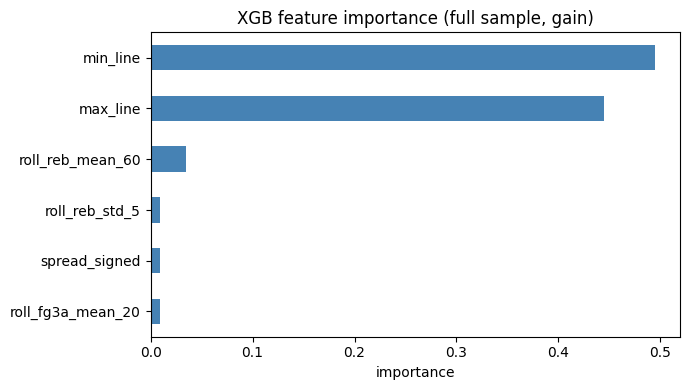

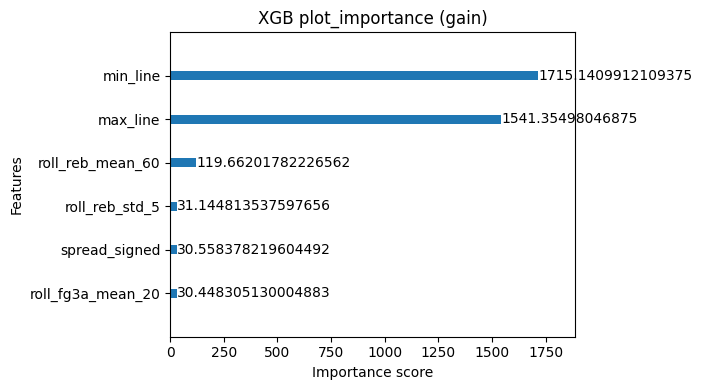

In [97]:
# reminder: here are the models we are working with

# Full-sample fit: OLS equation + XGB importance (same 6 feats as v5)
from __future__ import annotations

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
# feat = pd.read_parquet(FEAT_PATH)

TARGET = "REB"
B_MIN_MAX_FEATS = [
    "min_line",
    "max_line",
    "spread_signed",
    "roll_reb_mean_60",
    "roll_fg3a_mean_20",
    "roll_reb_std_5",
]

cols_needed = B_MIN_MAX_FEATS + [TARGET]
m = feat.dropna(subset=cols_needed)
X = m[B_MIN_MAX_FEATS].astype(float)
y = m[TARGET].astype(float)

print(f"n_rows (non-null feats+REB): {len(m):,}")

# ----- OLS: summary + readable equation -----
Xc = sm.add_constant(X, has_constant="add")
ols_res = sm.OLS(y, Xc).fit()
print(ols_res.summary())

const = float(ols_res.params["const"])
terms = []
for c in B_MIN_MAX_FEATS:
    terms.append(f"({ols_res.params[c]:+.6f})*{c}")
eq = f"REB_hat = {const:.6f} " + " ".join(terms)
print("\n=== OLS equation (full sample) ===")
print(eq)

# ----- XGB: fit + importance plot (same conservative spec as v5) -----
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    reg_alpha=0.5,
    random_state=69,
    n_jobs=-1,
    verbosity=0,
    importance_type="gain",
)
xgb_model.fit(X, y)

imp = (
    pd.Series(xgb_model.feature_importances_, index=B_MIN_MAX_FEATS)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGB feature importance (full sample, gain)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

# Native XGBoost plot (same info, often prettier)
fig, ax = plt.subplots(figsize=(7, 4))
xgb.plot_importance(xgb_model, importance_type="gain", max_num_features=len(B_MIN_MAX_FEATS), ax=ax, grid=False)
ax.set_title("XGB plot_importance (gain)")
plt.tight_layout()
plt.show()

# TLDR
- **OLS:** Additive **linear** map; **big + weights on `min_line` / `max_line`** (market), **+`roll_reb_mean_60`**, smaller terms on **spread / fg3a / short σ**; one **global equation**, easy to read.
- **XGB:** **Nonlinear trees**; **same story in practice**: almost all **split gain on `min_line` & `max_line`**, **`roll_reb_mean_60` third**, rest **minor** — fits **interactions/thresholds** OLS can’t, but **dominant signal is still the lines**.


In [ ]:
# planning the comparison of the two...

### Goal
Explain how **XGB** vs **linear (OLS/Ridge)** changes **`yhat`** → **`p_under`** → **which rows pass `min_edge`**, using the **same 6 features**, **same OOS seasons**, and **same PnL machinery**.

### 1) Align predictions (same rows)
- For each **test season**, on the exact **`test_m`** rows from v5 (after `dropna` on the 6 feats + `REB` + keys), compute **`yhat_ols`**, **`yhat_ridge`** (optional), **`yhat_xgb`** on one merged frame.
- Add **`dy = yhat_xgb - yhat_ols`** (and vs Ridge if useful).

### 2) Quantify forecast disagreement
- **Correlation** `corr(yhat_xgb, yhat_ols)` per season.
- **Distribution** of `dy` (mean, sd, tails).
- Inspect **top `|dy|` rows**: print the 6 features + **line/spread/consensus** context.

### 3) Connect to the bet rule (usually the real driver)
- On the **v3 inner-merge universe** (same merge as backtest), compute **`p_under`** from each model’s **`yhat`** with the **same σ** (`roll_reb_std_5` clipped) and **shrink=0** formula.
- Summarize **`dp_under = p_u_xgb - p_u_ols`**.
- Count **edge flips at `min_edge=0.05`**: passes for XGB not OLS (and reverse). This explains **`n_bets`** differences.

### 4) Model-shape diagnostics
- **Linear**: coefficient table (OLS; Ridge optional).
- **XGB**: **feature importance** + **SHAP** (or PDP on 1–2 drivers) to see what nonlinearities/splits do.

### 5) Error analysis (fit vs PnL)
- Compare **RMSE/MAE** overall (already known) and **by bins** (line buckets, spread buckets, σ buckets) to see *where* XGB hurts/helps vs linear.

### 6) Sanity / stability
- Check whether big disagreements are **stable across seasons** or **season-specific** (book mix / regime).

### 7) Deliverable
- Plots: **`yhat_xgb` vs `yhat_ols`**, **`dy` histogram**, **`dp_under` histogram**
- Table: **crossing counts** at **`min_edge=0.05`**
- One paragraph: **what subset of rows** XGB moves enough to change **under edge** (not just “XGB is better”).

In [100]:
!ls

v1_rebounds_game_to_game_foundations.ipynb


In [101]:
!pwd

/Users/thomasmyles/dev/betting/src/nba_rebounds_modeling/00_research/notebooks


In [ ]:
import os
os.chdir("/Users/thomasmyles/dev/betting/")

In [104]:
!python3 src/nba_rebounds_modeling/00_research/scripts/v6_diagnose_xgb_vs_linear_rebounds_oos.py \
  --feat ~/Downloads/tmp/rebounds_model_features_v2.parquet \
  --v3 ~/Downloads/tmp/v3_rebounds_props_raw.parquet \
  --out-dir ~/Downloads/tmp/rebounds_xgb_ols_diag \
  --min-edge 0.05

wrote /Users/thomasmyles/Downloads/tmp/rebounds_xgb_ols_diag/ols_coef_by_test_season.csv
wrote /Users/thomasmyles/Downloads/tmp/rebounds_xgb_ols_diag/xgb_feature_importance_by_test_season.csv
wrote /Users/thomasmyles/Downloads/tmp/rebounds_xgb_ols_diag/disagreement_edge_summary.csv
wrote /Users/thomasmyles/Downloads/tmp/rebounds_xgb_ols_diag/top_abs_dyhat_rows.csv
wrote /Users/thomasmyles/Downloads/tmp/rebounds_xgb_ols_diag/rmse_by_line_quantile_bin.csv
wrote /Users/thomasmyles/Downloads/tmp/rebounds_xgb_ols_diag/fig_2023_24_yhat_dy_punder.png
wrote /Users/thomasmyles/Downloads/tmp/rebounds_xgb_ols_diag/fig_2024_25_yhat_dy_punder.png
wrote /Users/thomasmyles/Downloads/tmp/rebounds_xgb_ols_diag/fig_2025_26_yhat_dy_punder.png

=== disagreement + edge flips (min_edge=0.050) ===
test_season  n_test_regression  n_merged  corr_yhat_ols_xgb   mean_dy   std_dy  p95_abs_dy  rmse_ols  rmse_xgb  mean_dp_under  std_dp_under  edge_pass_ols  edge_pass_xgb  xgb_only_edge  ols_only_edge  both_edge  ne

,test_season,n_test_regression,n_merged,corr_yhat_ols_xgb,mean_dy,std_dy,p95_abs_dy,rmse_ols,rmse_xgb,mean_dp_under,...,edge_pass_ols,edge_pass_xgb,xgb_only_edge,ols_only_edge,both_edge,neither_edge,bet_ols,bet_xgb,bet_xgb_not_ols,bet_ols_not_xgb
0,2023-24,7564,72954,0.988,-0.023,0.374,0.640,2.607,2.628,0.006,...,7040,12648,7681,2073,4967,58233,7040,12648,7681,2073
1,2024-25,10983,59981,0.990,-0.007,0.320,0.627,2.590,2.602,0.002,...,5098,9663,6025,1460,3638,48858,5098,9663,6025,1460
2,2025-26,10890,81038,0.991,0.017,0.274,0.548,2.483,2.495,-0.003,...,7093,10527,5157,1723,5370,68788,7093,10527,5157,1723


,test_season,ols_coef__const,ols_coef__min_line,ols_coef__max_line,ols_coef__spread_signed,ols_coef__roll_reb_mean_60,ols_coef__roll_fg3a_mean_20,ols_coef__roll_reb_std_5
0,2023-24,0.257,0.370,0.407,0.003,0.190,-0.016,0.039
1,2024-25,0.277,0.354,0.413,0.004,0.187,-0.018,0.056
2,2025-26,0.376,0.385,0.366,0.003,0.197,-0.024,0.061


,test_season,feature,xgb_importance_gain
0,2023-24,min_line,0.516
1,2023-24,max_line,0.410
2,2023-24,roll_reb_mean_60,0.039
3,2023-24,roll_reb_std_5,0.012
4,2023-24,roll_fg3a_mean_20,0.012
5,2023-24,spread_signed,0.012
6,2024-25,min_line,0.511
7,2024-25,max_line,0.403
8,2024-25,roll_reb_mean_60,0.052
9,2024-25,spread_signed,0.012


,test_season,line_bin,n,rmse_ols,rmse_xgb
0,2023-24,"(0.499, 3.5]",22291,2.104,2.111
1,2023-24,"(3.5, 4.5]",15007,2.316,2.316
2,2023-24,"(4.5, 5.5]",9819,2.580,2.581
3,2023-24,"(5.5, 7.5]",12685,2.943,2.964
4,2023-24,"(7.5, 16.5]",13152,3.542,3.621
5,2024-25,"(0.499, 3.5]",20919,2.033,2.035
6,2024-25,"(3.5, 4.5]",10856,2.422,2.426
7,2024-25,"(4.5, 5.5]",9514,2.646,2.655
8,2024-25,"(5.5, 7.5]",10028,3.082,3.101
9,2024-25,"(7.5, 16.5]",8664,3.648,3.678


,test_season,season,date,player_normalized,game_id,min_line,max_line,spread_signed,roll_reb_mean_60,roll_fg3a_mean_20,roll_reb_std_5,REB,consensus_reb_line,yhat_ols,yhat_xgb,dy
0,2023-24,2023-24,2024-02-05,Domantas Sabonis,22300714,13.5,13.5,5.0,13.021,0.889,6.221,19,13.5,13.472,8.265,-5.206
1,2023-24,2023-24,2024-02-03,Domantas Sabonis,22300700,13.5,13.5,1.0,13.000,0.889,7.162,14,13.5,13.491,8.621,-4.870
2,2023-24,2023-24,2024-03-16,Anthony Davis,22300973,13.5,13.5,-1.5,12.450,1.529,6.140,4,13.5,13.328,8.515,-4.813
3,2023-24,2023-24,2024-03-29,Anthony Davis,22301063,13.5,14.5,3.5,12.750,1.706,7.092,15,13.5,13.843,9.201,-4.643
4,2023-24,2023-24,2024-01-05,Domantas Sabonis,22300492,13.5,13.5,-4.5,12.848,1.067,5.701,15,13.5,13.384,8.903,-4.481
5,2023-24,2023-24,2024-02-02,Domantas Sabonis,22300691,12.5,13.5,-4.0,13.043,0.944,7.301,11,12.5,13.116,8.765,-4.351
6,2023-24,2023-24,2024-03-24,Anthony Davis,22301032,14.5,14.5,-2.5,12.383,1.294,8.081,16,14.5,14.169,10.224,-3.945
7,2023-24,2023-24,2024-03-31,Domantas Sabonis,22301086,14.5,14.5,-12.5,13.850,0.765,1.304,11,14.5,14.160,17.971,3.811
8,2023-24,2023-24,2024-03-13,Anthony Davis,22300954,13.5,13.5,-2.5,12.550,1.471,5.983,10,13.5,13.339,9.546,-3.792
9,2023-24,2023-24,2024-01-31,Domantas Sabonis,22300678,12.5,12.5,2.0,12.956,0.944,7.701,17,12.5,12.728,9.133,-3.595


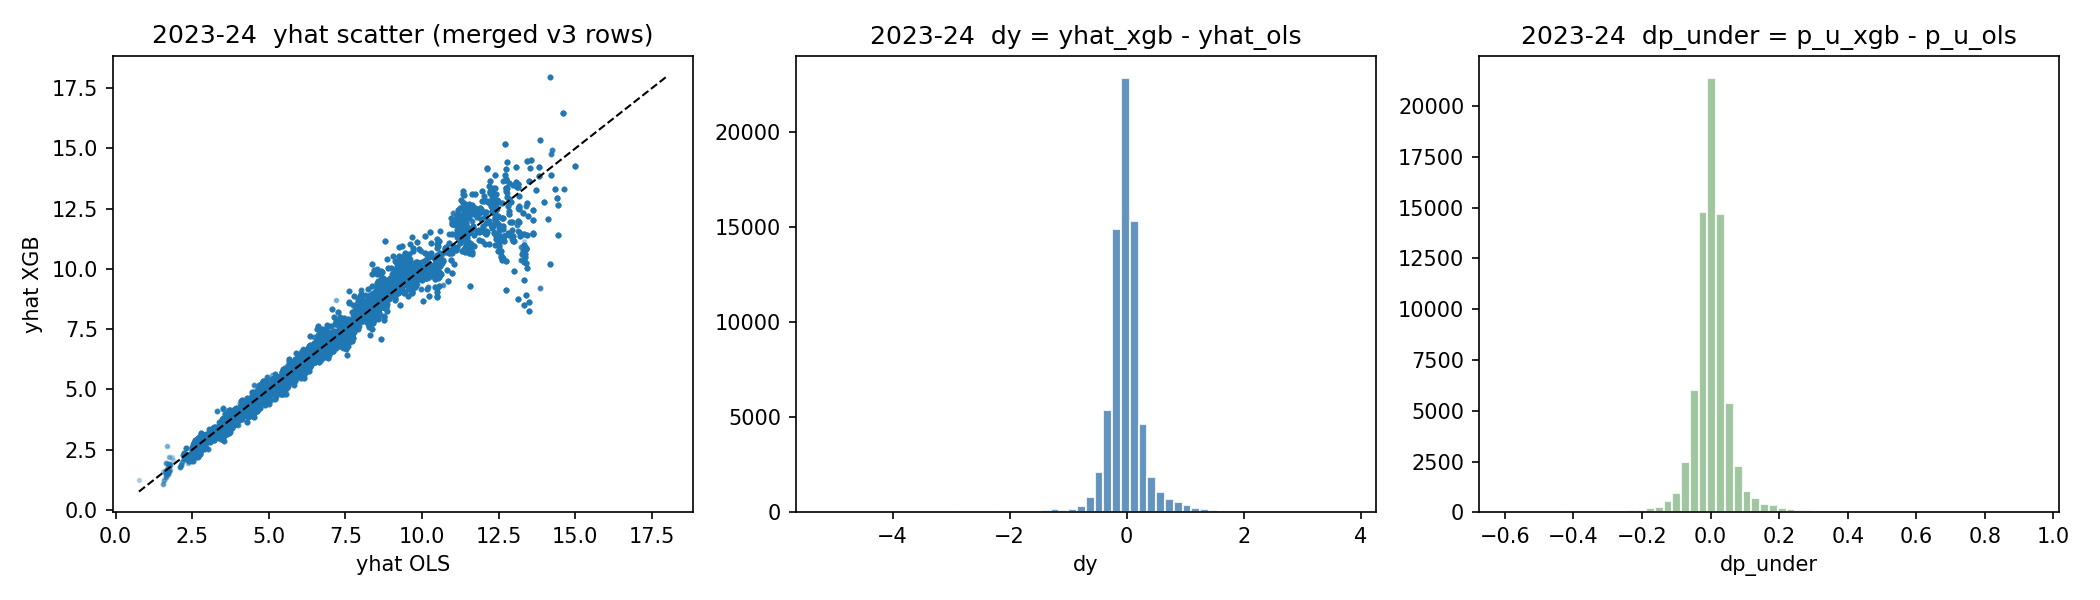

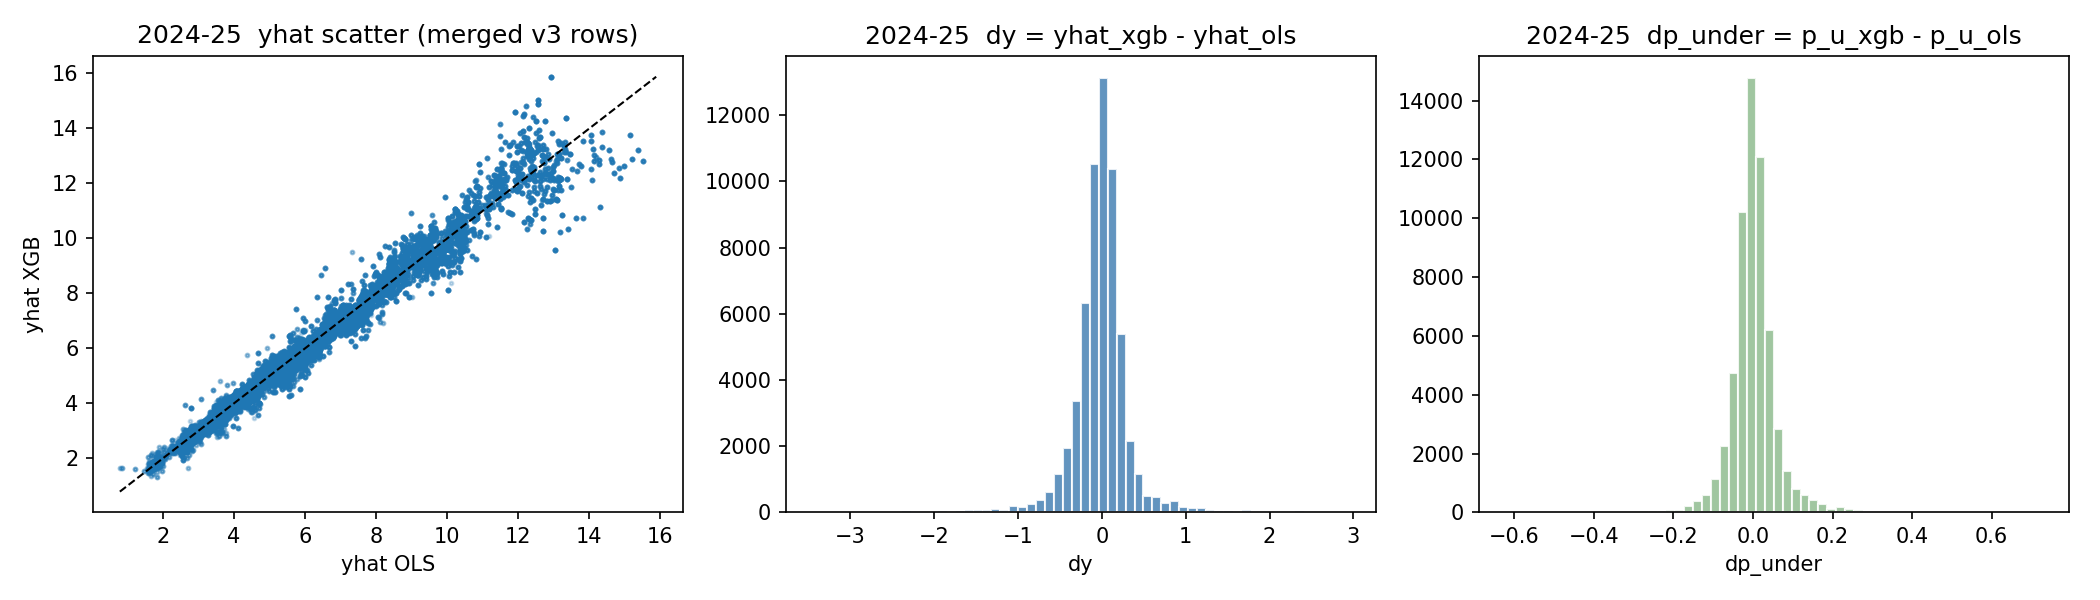

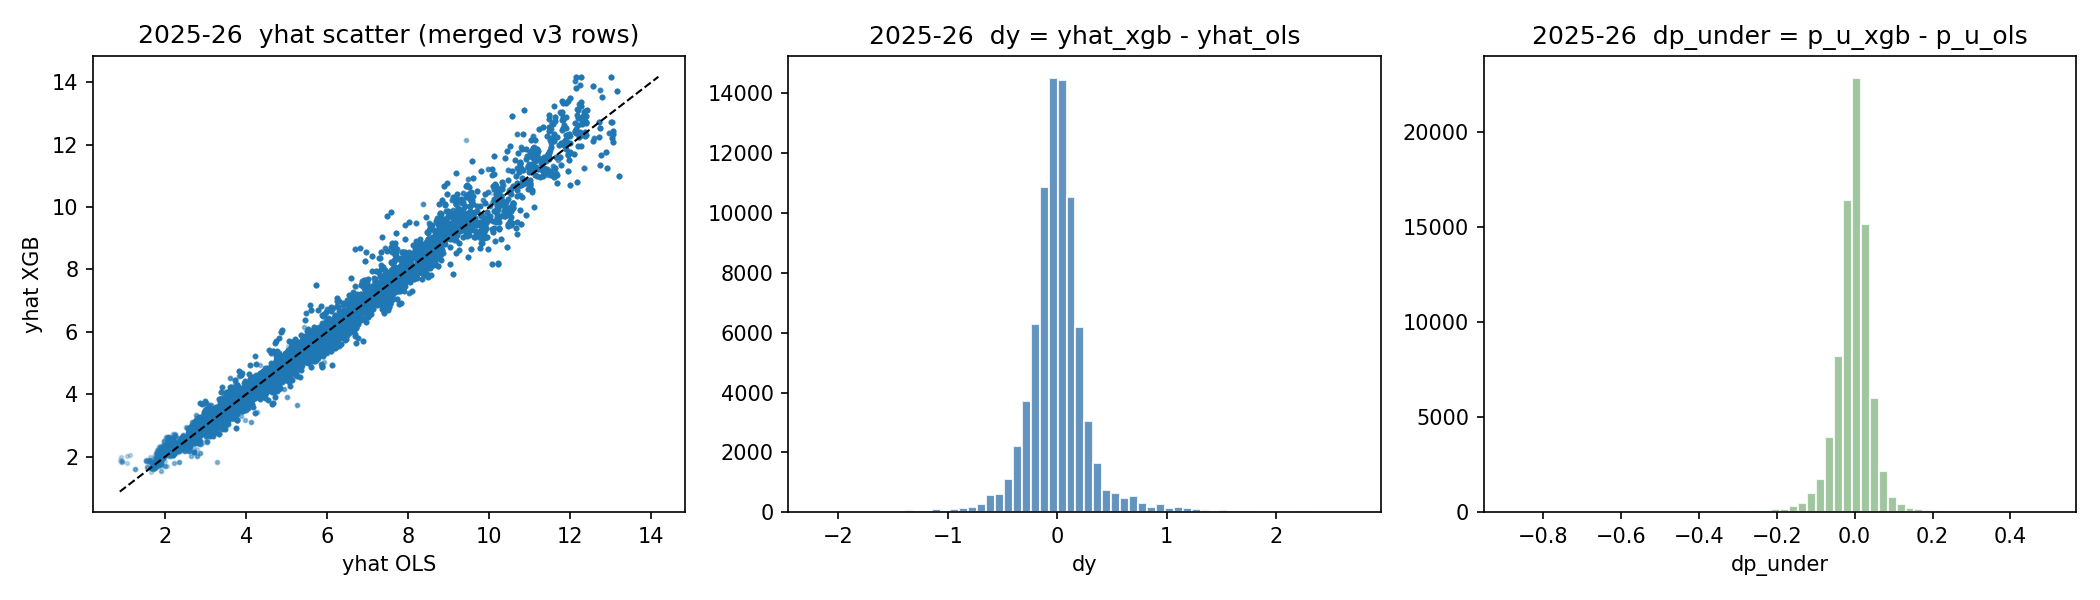

In [106]:
from pathlib import Path

from IPython.display import Image, display
import pandas as pd

OUT = Path("~/Downloads/tmp/rebounds_xgb_ols_diag").expanduser()

display(pd.read_csv(OUT / "disagreement_edge_summary.csv").round(3))
display(pd.read_csv(OUT / "ols_coef_by_test_season.csv").round(3))
display(pd.read_csv(OUT / "xgb_feature_importance_by_test_season.csv").round(3))
display(pd.read_csv(OUT / "rmse_by_line_quantile_bin.csv").round(3))
display(pd.read_csv(OUT / "top_abs_dyhat_rows.csv").head(40).round(3))

for png in sorted(OUT.glob("fig_*_yhat_dy_punder.png")):
    display(Image(filename=str(png)))

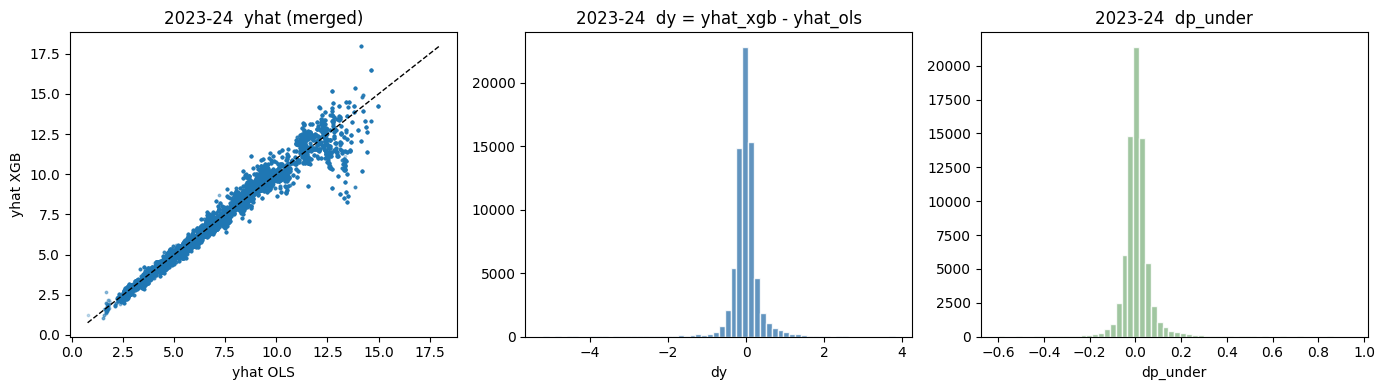

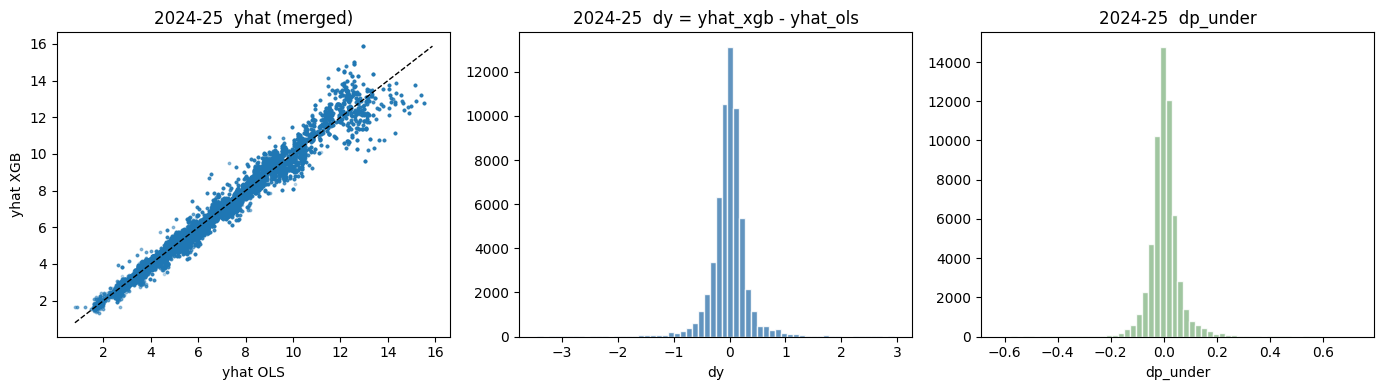

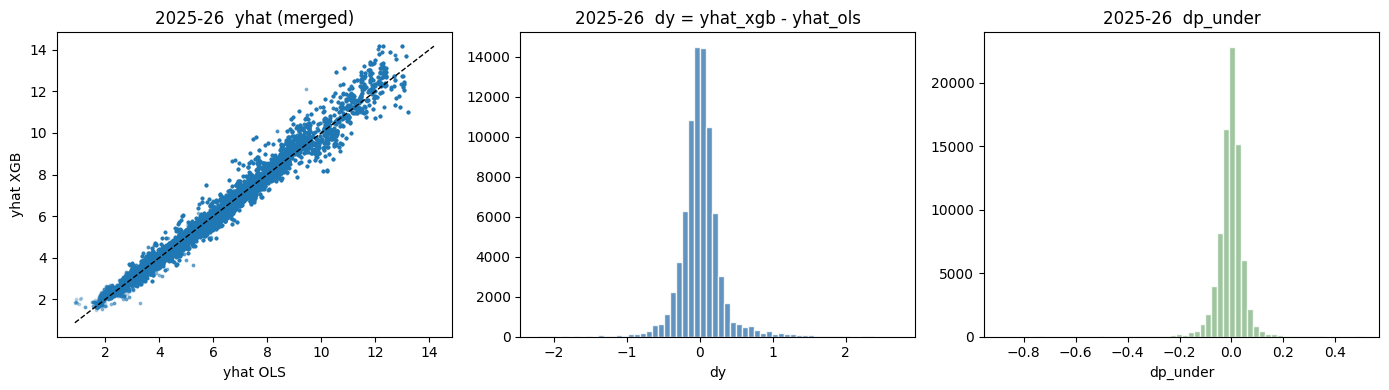

min_edge = 0.05


,test_season,n_test_regression,n_merged,corr_yhat_ols_xgb,mean_dy,std_dy,p95_abs_dy,rmse_ols,rmse_xgb,mean_dp_under,...,edge_pass_ols,edge_pass_xgb,xgb_only_edge,ols_only_edge,both_edge,neither_edge,bet_ols,bet_xgb,bet_xgb_not_ols,bet_ols_not_xgb
0,2023-24,7564,72954,0.988011,-0.023040,0.373558,0.639932,2.606805,2.627938,0.005517,...,7040,12648,7681,2073,4967,58233,7040,12648,7681,2073
1,2024-25,10983,59981,0.990394,-0.007190,0.320041,0.626628,2.589943,2.601632,0.001650,...,5098,9663,6025,1460,3638,48858,5098,9663,6025,1460
2,2025-26,10890,81038,0.991384,0.017363,0.274319,0.547885,2.483133,2.495233,-0.003031,...,7093,10527,5157,1723,5370,68788,7093,10527,5157,1723


,test_season,ols_coef__const,ols_coef__min_line,ols_coef__max_line,ols_coef__spread_signed,ols_coef__roll_reb_mean_60,ols_coef__roll_fg3a_mean_20,ols_coef__roll_reb_std_5
0,2023-24,0.256893,0.370285,0.407373,0.003336,0.189955,-0.015750,0.038614
1,2024-25,0.276811,0.353958,0.413474,0.004099,0.186793,-0.017524,0.056006
2,2025-26,0.375804,0.385226,0.365612,0.002628,0.196571,-0.024240,0.061498


,test_season,feature,xgb_importance_gain
0,2023-24,min_line,0.516048
1,2023-24,max_line,0.409750
3,2023-24,roll_reb_mean_60,0.038707
5,2023-24,roll_reb_std_5,0.012451
4,2023-24,roll_fg3a_mean_20,0.011544
2,2023-24,spread_signed,0.011500
6,2024-25,min_line,0.510866
7,2024-25,max_line,0.402815
9,2024-25,roll_reb_mean_60,0.051603
8,2024-25,spread_signed,0.011935


,test_season,line_bin,n,rmse_ols,rmse_xgb
0,2023-24,"(0.499, 3.5]",22291,2.104309,2.110933
1,2023-24,"(3.5, 4.5]",15007,2.315643,2.316411
2,2023-24,"(4.5, 5.5]",9819,2.579810,2.581249
3,2023-24,"(5.5, 7.5]",12685,2.942564,2.964293
4,2023-24,"(7.5, 16.5]",13152,3.542420,3.621492
5,2024-25,"(0.499, 3.5]",20919,2.032548,2.034884
6,2024-25,"(3.5, 4.5]",10856,2.421811,2.426115
7,2024-25,"(4.5, 5.5]",9514,2.646176,2.655453
8,2024-25,"(5.5, 7.5]",10028,3.081530,3.100689
9,2024-25,"(7.5, 16.5]",8664,3.647612,3.678397


,test_season,season,date,player_normalized,game_id,min_line,max_line,spread_signed,roll_reb_mean_60,roll_fg3a_mean_20,roll_reb_std_5,REB,consensus_reb_line,yhat_ols,yhat_xgb,dy
0,2023-24,2023-24,2024-02-05,Domantas Sabonis,0022300714,13.5,13.5,5.0,13.020833,0.888889,6.220932,19,13.5,13.471536,8.265127,-5.206409
1,2023-24,2023-24,2024-02-03,Domantas Sabonis,0022300700,13.5,13.5,1.0,13.000000,0.888889,7.162402,14,13.5,13.490589,8.620633,-4.869956
2,2023-24,2023-24,2024-03-16,Anthony Davis,0022300973,13.5,13.5,-1.5,12.450000,1.529412,6.140033,4,13.5,13.328208,8.515135,-4.813074
3,2023-24,2023-24,2024-03-29,Anthony Davis,0022301063,13.5,14.5,3.5,12.750000,1.705882,7.092249,15,13.5,13.843237,9.200653,-4.642584
4,2023-24,2023-24,2024-01-05,Domantas Sabonis,0022300492,13.5,13.5,-4.5,12.848485,1.066667,5.700877,15,13.5,13.384225,8.903316,-4.480910
5,2023-24,2023-24,2024-02-02,Domantas Sabonis,0022300691,12.5,13.5,-4.0,13.043478,0.944444,7.300685,11,12.5,13.116349,8.765130,-4.351219
6,2023-24,2023-24,2024-03-24,Anthony Davis,0022301032,14.5,14.5,-2.5,12.383333,1.294118,8.080842,16,14.5,14.168516,10.223609,-3.944907
7,2023-24,2023-24,2024-03-31,Domantas Sabonis,0022301086,14.5,14.5,-12.5,13.850000,0.764706,1.303840,11,14.5,14.160406,17.971476,3.811069
8,2023-24,2023-24,2024-03-13,Anthony Davis,0022300954,13.5,13.5,-2.5,12.550000,1.470588,5.983310,10,13.5,13.338743,9.546387,-3.792356
9,2023-24,2023-24,2024-01-31,Domantas Sabonis,0022300678,12.5,12.5,2.0,12.955556,0.944444,7.700649,17,12.5,12.727734,9.133042,-3.594692


In [107]:
# v6-style diagnostics in-notebook: OLS vs XGB OOS — yhat, p_under, edge flips, coefs, importance, bins
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from scipy.stats import norm


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    while True:
        if (p / ".gitignore").exists() and (p / "src").exists():
            return p
        if p.parent == p:
            raise FileNotFoundError("repo root not found (.gitignore + src/)")
        p = p.parent


def _load_v5():
    root = _repo_root()
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    p = root / "src/nba_rebounds_modeling/00_research/scripts/v5_compare_rebounds_models_oos.py"
    spec = importlib.util.spec_from_file_location("v5_compare_rebounds_models_oos", p)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


def _p_under_edges(consensus, line, sigma, yhat, p_nov_u):
    mean_adj = consensus + (yhat - consensus)
    z = (line - mean_adj) / sigma
    p_under = norm.cdf(z)
    edge = p_under - p_nov_u
    return p_under, edge


def _fit_ols_result(train_m, v5):
    X_tr = sm.add_constant(train_m[v5.B_MIN_MAX_FEATS].astype(float), has_constant="add")
    y_tr = train_m[v5.TARGET].astype(float)
    return sm.OLS(y_tr, X_tr).fit()


def _fit_xgb(train_m, v5):
    import xgboost as xgb

    X_tr = train_m[v5.B_MIN_MAX_FEATS].astype(float)
    y_tr = train_m[v5.TARGET].astype(float)
    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        reg_alpha=0.5,
        random_state=69,
        n_jobs=-1,
        verbosity=0,
        importance_type="gain",
    )
    model.fit(X_tr, y_tr)
    return model


# --- config ---
FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
V3_PATH = Path("~/Downloads/tmp/v3_rebounds_props_raw.parquet").expanduser()
TEST_SEASONS = ["2023-24", "2024-25", "2025-26"]
MIN_EDGE = 0.05
TOP_DY = 25

v5 = _load_v5()
feat = pd.read_parquet(FEAT_PATH)
v3 = pd.read_parquet(V3_PATH)

for c in v5.B_MIN_MAX_FEATS + [v5.TARGET, "consensus_reb_line"]:
    if c not in feat.columns:
        raise ValueError(f"feat missing: {c}")

coef_rows: list[dict] = []
imp_rows: list[dict] = []
disag_rows: list[dict] = []
top_dy_chunks: list[pd.DataFrame] = []
bin_rows: list[dict] = []

for ts in TEST_SEASONS:
    if ts not in feat["season"].unique():
        raise ValueError(f"test_season {ts!r} not in feat")

    train = feat[feat["season"] != ts].copy()
    feat_test = feat[feat["season"] == ts].copy()
    cols_needed = v5.B_MIN_MAX_FEATS + [v5.TARGET]
    train_m = train.dropna(subset=cols_needed)
    test_m = feat_test.dropna(subset=cols_needed + v5.GROUP_KEYS)
    if len(train_m) < 100:
        raise ValueError(f"train_m too small: {ts}")

    ols_res = _fit_ols_result(train_m, v5)
    coef_row = {"test_season": ts}
    for name in ols_res.params.index:
        coef_row[f"ols_coef__{name}"] = float(ols_res.params[name])
    coef_rows.append(coef_row)

    xgb_model = _fit_xgb(train_m, v5)
    for j, col in enumerate(v5.B_MIN_MAX_FEATS):
        imp_rows.append(
            {
                "test_season": ts,
                "feature": col,
                "xgb_importance_gain": float(xgb_model.feature_importances_[j]),
            }
        )

    yhat_ols = v5.fit_predict_ols(train_m, test_m)
    yhat_xgb = v5.fit_predict_xgb(train_m, test_m)
    y_true = test_m[v5.TARGET].to_numpy().astype(float)
    dy_reg = yhat_xgb.astype(float) - yhat_ols.astype(float)
    corr = float(np.corrcoef(yhat_ols, yhat_xgb)[0, 1])
    rmse_ols = float(np.sqrt(np.mean((y_true - yhat_ols) ** 2)))
    rmse_xgb = float(np.sqrt(np.mean((y_true - yhat_xgb) ** 2)))

    pred = test_m[v5.GROUP_KEYS].copy()
    pred["yhat_ols"] = yhat_ols
    pred["yhat_xgb"] = yhat_xgb
    pred[v5.SIGMA_COL] = test_m[v5.SIGMA_COL].to_numpy()

    v3_test = v3[v3["season"] == ts].copy()
    base = v3_test.merge(pred, on=v5.GROUP_KEYS, how="inner")

    sigma = base[v5.SIGMA_COL].astype(float).clip(lower=v5.SIGMA_FLOOR).to_numpy()
    consensus = base["consensus_reb_line"].astype(float).to_numpy()
    line = base["line"].astype(float).to_numpy()
    reb = base["REB"].astype(float).to_numpy()
    p_nov_u = base["p_under_novig"].astype(float).to_numpy()

    p_u_ols, edge_ols = _p_under_edges(consensus, line, sigma, base["yhat_ols"].to_numpy(), p_nov_u)
    p_u_xgb, edge_xgb = _p_under_edges(consensus, line, sigma, base["yhat_xgb"].to_numpy(), p_nov_u)
    dp = p_u_xgb - p_u_ols

    pass_ols = edge_ols > MIN_EDGE
    pass_xgb = edge_xgb > MIN_EDGE
    not_push = reb != line

    disag_rows.append(
        {
            "test_season": ts,
            "n_test_regression": int(len(test_m)),
            "n_merged": int(len(base)),
            "corr_yhat_ols_xgb": corr,
            "mean_dy": float(np.mean(dy_reg)),
            "std_dy": float(np.std(dy_reg)),
            "p95_abs_dy": float(np.percentile(np.abs(dy_reg), 95)),
            "rmse_ols": rmse_ols,
            "rmse_xgb": rmse_xgb,
            "mean_dp_under": float(np.mean(dp)),
            "std_dp_under": float(np.std(dp)),
            "edge_pass_ols": int(pass_ols.sum()),
            "edge_pass_xgb": int(pass_xgb.sum()),
            "xgb_only_edge": int((pass_xgb & ~pass_ols).sum()),
            "ols_only_edge": int((pass_ols & ~pass_xgb).sum()),
            "both_edge": int((pass_ols & pass_xgb).sum()),
            "neither_edge": int((~pass_ols & ~pass_xgb).sum()),
            "bet_ols": int((pass_ols & not_push).sum()),
            "bet_xgb": int((pass_xgb & not_push).sum()),
            "bet_xgb_not_ols": int((pass_xgb & ~pass_ols & not_push).sum()),
            "bet_ols_not_xgb": int((pass_ols & ~pass_xgb & not_push).sum()),
        }
    )

    tm = test_m.copy()
    tm["yhat_ols"] = yhat_ols
    tm["yhat_xgb"] = yhat_xgb
    tm["dy"] = dy_reg
    tm["abs_dy"] = np.abs(dy_reg)
    top = tm.nlargest(TOP_DY, "abs_dy")[
        v5.GROUP_KEYS
        + v5.B_MIN_MAX_FEATS
        + [v5.TARGET, "consensus_reb_line", "yhat_ols", "yhat_xgb", "dy"]
    ].copy()
    top.insert(0, "test_season", ts)
    top_dy_chunks.append(top)

    line_series = base["line"].astype(float)
    try:
        base = base.copy()
        base["_line_bin"] = pd.qcut(line_series, q=5, duplicates="drop")
    except ValueError:
        base["_line_bin"] = "all"
    for bin_label, sub in base.groupby("_line_bin", observed=True):
        yo = sub["yhat_ols"].to_numpy()
        yx = sub["yhat_xgb"].to_numpy()
        yt = sub["REB"].astype(float).to_numpy()
        bin_rows.append(
            {
                "test_season": ts,
                "line_bin": str(bin_label),
                "n": int(len(sub)),
                "rmse_ols": float(np.sqrt(np.mean((yt - yo) ** 2))),
                "rmse_xgb": float(np.sqrt(np.mean((yt - yx) ** 2))),
            }
        )

    # --- figures (merged v3 rows) ---
    yo = base["yhat_ols"].to_numpy()
    yx = base["yhat_xgb"].to_numpy()
    dy_m = yx.astype(float) - yo.astype(float)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    ax0, ax1, ax2 = axes
    ax0.scatter(yo, yx, s=3, alpha=0.25)
    lims = [min(yo.min(), yx.min()), max(yo.max(), yx.max())]
    ax0.plot(lims, lims, "k--", lw=1)
    ax0.set_xlabel("yhat OLS")
    ax0.set_ylabel("yhat XGB")
    ax0.set_title(f"{ts}  yhat (merged)")

    ax1.hist(dy_m, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
    ax1.set_title(f"{ts}  dy = yhat_xgb - yhat_ols")
    ax1.set_xlabel("dy")

    ax2.hist(dp, bins=60, color="darkseagreen", edgecolor="white", alpha=0.85)
    ax2.set_title(f"{ts}  dp_under")
    ax2.set_xlabel("dp_under")

    fig.tight_layout()
    plt.show()

coef_df = pd.DataFrame(coef_rows).sort_values("test_season")
imp_df = pd.DataFrame(imp_rows).sort_values(["test_season", "xgb_importance_gain"], ascending=[True, False])
disag_df = pd.DataFrame(disag_rows).sort_values("test_season")
top_dy_df = pd.concat(top_dy_chunks, ignore_index=True)
bin_df = pd.DataFrame(bin_rows).sort_values(["test_season", "line_bin"])

print(f"min_edge = {MIN_EDGE}")
display(disag_df)
display(coef_df)
display(imp_df)
display(bin_df)
display(top_dy_df.head(50))

**disagreement_edge_summary.csv**
- **yhat:** OLS vs XGB **corr ~0.99**; mean **`dy`** tiny; **XGB RMSE slightly worse** each season.
- **Edges @ 0.05:** XGB **passes on way more rows** than OLS; **`xgb_only_edge` ≫ `ols_only_edge`** → extra bet volume is mostly **new passes**, not symmetric flips.
- **`mean_dp_under` ~0** vs **`std_dp_under` ~0.05–0.06** → average prob shift is small; **threshold + tails** still move lots of bets.

**ols_coef_by_test_season.csv**
- **`min_line` / `max_line`** still **dominant** (~0.35–0.41); **`roll_reb_mean_60` ~0.19**; **`roll_fg3a_mean_20` < 0**; **`roll_reb_std_5` > 0** (a bit higher in later folds).
- **Intercept drifts by fold** → normal **OOS re-fit** level shift.

**xgb_feature_importance_by_test_season.csv**
- **~90%+ gain on `min_line` + `max_line`** every season; **`roll_reb_mean_60` third**; rest **minor**.

**rmse_by_line_quantile_bin.csv**
- **Higher line → higher RMSE** for both; **XGB ≥ OLS in every bin** (gap **widens** on **high lines**).

**top_abs_dyhat_rows.csv**
- Biggest **`|dy|`** concentrated on **high-line star bigs** (e.g. Sabonis/AD): OLS stays **near line**; XGB often **slashes `yhat`** → **where the models diverge most**.

In [ ]:
# lets bin the difference in models and see performance (ie. seeing that if models are different, which is doing better when diff)
# xgb - ols so 1 would be xgb prediction of 10 and ols 9
# -1 would be ols 11 and xgb 10
# start by binning with -2.5+, -2.5 -> -1.5, -1.5 -> -0.5, <0.5 abs, .5 -> 1.5, 1.5 -> 2.5, 2.5+




In [108]:
# Bin dy = yhat_xgb - yhat_ols; compare OLS vs XGB error vs REB on OOS test_m rows
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    while True:
        if (p / ".gitignore").exists() and (p / "src").exists():
            return p
        if p.parent == p:
            raise FileNotFoundError("repo root not found")
        p = p.parent


def _load_v5():
    root = _repo_root()
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    p = root / "src/nba_rebounds_modeling/00_research/scripts/v5_compare_rebounds_models_oos.py"
    spec = importlib.util.spec_from_file_location("v5_compare_rebounds_models_oos", p)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


DY_BINS = [-np.inf, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, np.inf]
DY_BIN_LABELS = [
    "(-inf, -2.5]",
    "(-2.5, -1.5]",
    "(-1.5, -0.5]",
    "(-0.5, 0.5]",
    "(0.5, 1.5]",
    "(1.5, 2.5]",
    "(2.5, inf)",
]

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
TEST_SEASONS = ["2023-24", "2024-25", "2025-26"]

v5 = _load_v5()
feat = pd.read_parquet(FEAT_PATH)

cat_type = pd.CategoricalDtype(categories=DY_BIN_LABELS, ordered=True)

rows_out: list[dict] = []

for ts in TEST_SEASONS:
    train = feat[feat["season"] != ts].copy()
    feat_test = feat[feat["season"] == ts].copy()
    cols_needed = v5.B_MIN_MAX_FEATS + [v5.TARGET]
    train_m = train.dropna(subset=cols_needed)
    test_m = feat_test.dropna(subset=cols_needed + v5.GROUP_KEYS)

    yhat_ols = v5.fit_predict_ols(train_m, test_m)
    yhat_xgb = v5.fit_predict_xgb(train_m, test_m)
    y = test_m[v5.TARGET].to_numpy(dtype=float)
    dy = yhat_xgb.astype(float) - yhat_ols.astype(float)

    dy_bin = pd.cut(dy, bins=DY_BINS, labels=DY_BIN_LABELS, include_lowest=True)
    dy_bin = dy_bin.astype(cat_type)

    sub = pd.DataFrame(
        {
            "dy_bin": dy_bin,
            "y": y,
            "yhat_ols": yhat_ols.astype(float),
            "yhat_xgb": yhat_xgb.astype(float),
        }
    )

    for b in DY_BIN_LABELS:
        x = sub[sub["dy_bin"] == b]
        n = int(len(x))
        if n == 0:
            rows_out.append(
                {
                    "test_season": ts,
                    "dy_bin": b,
                    "n": 0,
                    "rmse_ols": np.nan,
                    "rmse_xgb": np.nan,
                    "mae_ols": np.nan,
                    "mae_xgb": np.nan,
                    "mean_err_ols": np.nan,
                    "mean_err_xgb": np.nan,
                    "rmse_winner": "",
                }
            )
            continue
        e_o = x["y"].to_numpy() - x["yhat_ols"].to_numpy()
        e_x = x["y"].to_numpy() - x["yhat_xgb"].to_numpy()
        rmse_o = float(np.sqrt(np.mean(e_o**2)))
        rmse_x = float(np.sqrt(np.mean(e_x**2)))
        if rmse_o < rmse_x - 1e-9:
            w = "ols"
        elif rmse_x < rmse_o - 1e-9:
            w = "xgb"
        else:
            w = "tie"
        rows_out.append(
            {
                "test_season": ts,
                "dy_bin": b,
                "n": n,
                "rmse_ols": rmse_o,
                "rmse_xgb": rmse_x,
                "mae_ols": float(np.mean(np.abs(e_o))),
                "mae_xgb": float(np.mean(np.abs(e_x))),
                "mean_err_ols": float(np.mean(e_o)),
                "mean_err_xgb": float(np.mean(e_x)),
                "rmse_winner": w,
            }
        )

bin_perf = pd.DataFrame(rows_out)
bin_perf["dy_bin"] = bin_perf["dy_bin"].astype(cat_type)
bin_perf = bin_perf.sort_values(["test_season", "dy_bin"]).reset_index(drop=True)

display(bin_perf.round(4))

print("\nPivot: who wins RMSE in each dy_bin (counts across seasons)")
pivot = (
    bin_perf[bin_perf["n"] > 0]
    .groupby(["dy_bin", "rmse_winner"], observed=True)
    .size()
    .unstack(fill_value=0)
)
display(pivot)

,test_season,dy_bin,n,rmse_ols,rmse_xgb,mae_ols,mae_xgb,mean_err_ols,mean_err_xgb,rmse_winner
0,2023-24,"(-inf, -2.5]",23,3.6950,5.3502,3.0003,4.2815,0.2889,3.7713,ols
1,2023-24,"(-2.5, -1.5]",34,3.5823,3.8088,2.6604,2.8719,-0.6441,1.2504,ols
2,2023-24,"(-1.5, -0.5]",199,3.5061,3.5173,2.6741,2.6735,-0.3711,0.3922,ols
3,2023-24,"(-0.5, 0.5]",6993,2.5224,2.5275,1.9783,1.9766,0.0212,0.0432,ols
4,2023-24,"(0.5, 1.5]",296,3.4435,3.5396,2.7480,2.8456,-0.1253,-0.9336,ols
5,2023-24,"(1.5, 2.5]",18,3.2652,3.2784,2.4120,2.6534,0.9533,-0.8430,ols
6,2023-24,"(2.5, inf)",1,3.1604,6.9715,3.1604,6.9715,-3.1604,-6.9715,ols
7,2024-25,"(-inf, -2.5]",8,4.3679,4.8578,3.5304,4.0354,-0.7179,2.2731,ols
8,2024-25,"(-2.5, -1.5]",30,3.4841,3.9473,2.4464,3.0585,0.1403,1.9680,ols
9,2024-25,"(-1.5, -0.5]",404,3.5159,3.5781,2.6882,2.6990,-0.0956,0.6521,ols



Pivot: who wins RMSE in each dy_bin (counts across seasons)


rmse_winner,ols
dy_bin,
"(-inf, -2.5]",2
"(-2.5, -1.5]",3
"(-1.5, -0.5]",3
"(-0.5, 0.5]",3
"(0.5, 1.5]",3
"(1.5, 2.5]",3
"(2.5, inf)",3


- **Fit (RMSE / R²):** OLS and Ridge are basically the same; **XGB is slightly worse every season** (higher RMSE, lower R²).
- **`min_edge = 0.05`:** **All three models** show **positive ROI in all three** test seasons.
- **Volume:** XGB usually **bets a lot more** than OLS/Ridge (biggest gap in 2023-24), so **total $** can look better without **ROI** being best.
- **Per-season ROI @ 0.05:** e.g. **2025-26** OLS ~**2.4%** vs XGB ~**1.4%** — linear can still win on **efficiency** even if XGB wins on **total PnL** sometimes.
- **`min_edge = 0.10`:** OLS/Ridge mostly **only 2025-26** clearly works; **earlier seasons weak/negative**. XGB **flips 2023-24** to strong + at 0.10; **2024-25** still a small **negative**.
- **“Both thresholds green”:** Counts favor **XGB** vs linear — but that’s **edge-filter / forecast-shape** behavior, **not** a better mean forecast.
- **Takeaway:** Keep **linear as the baseline mean model**; treat XGB as **changing which bets qualify**, not as a clean upgrade on **OOS error**.

In [ ]:
# ... do again but i want counts saying ok for all 3 years in this bin, how many times is xgb/ols closer so have n/%
# also make bins like 0-0.25, 0.25-0.50, 0.50-> 0.75, 0.75-1, 1-1.25, 1.25-1.50, 1.50-1.75, 1.75-2, 2+
# need more granular bc above everything is in the -0.5 -> 0.5 bin

In [111]:
# abs(dy) bins: who is *closer* to REB by absolute error (row-level), pooled + by season
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    while True:
        if (p / ".gitignore").exists() and (p / "src").exists():
            return p
        if p.parent == p:
            raise FileNotFoundError("repo root not found")
        p = p.parent


def _load_v5():
    root = _repo_root()
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    p = root / "src/nba_rebounds_modeling/00_research/scripts/v5_compare_rebounds_models_oos.py"
    spec = importlib.util.spec_from_file_location("v5_compare_rebounds_models_oos", p)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


ABS_DY_BINS = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, np.inf]
ABS_DY_LABELS = [
    "[0, 0.25)",
    "[0.25, 0.5)",
    "[0.5, 0.75)",
    "[0.75, 1)",
    "[1, 1.25)",
    "[1.25, 1.5)",
    "[1.5, 1.75)",
    "[1.75, 2)",
    "[2, inf)",
]

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
TEST_SEASONS = ["2023-24", "2024-25", "2025-26"]

v5 = _load_v5()
feat = pd.read_parquet(FEAT_PATH)

cat_type = pd.CategoricalDtype(categories=ABS_DY_LABELS, ordered=True)

chunks: list[pd.DataFrame] = []

for ts in TEST_SEASONS:
    train = feat[feat["season"] != ts].copy()
    feat_test = feat[feat["season"] == ts].copy()
    cols_needed = v5.B_MIN_MAX_FEATS + [v5.TARGET]
    train_m = train.dropna(subset=cols_needed)
    test_m = feat_test.dropna(subset=cols_needed + v5.GROUP_KEYS)

    yhat_ols = v5.fit_predict_ols(train_m, test_m)
    yhat_xgb = v5.fit_predict_xgb(train_m, test_m)
    y = test_m[v5.TARGET].to_numpy(dtype=float)
    dy = yhat_xgb.astype(float) - yhat_ols.astype(float)
    ady = np.abs(dy)

    ae_o = np.abs(y - yhat_ols.astype(float))
    ae_x = np.abs(y - yhat_xgb.astype(float))
    closer = np.where(
        ae_o < ae_x,
        "ols",
        np.where(ae_x < ae_o, "xgb", "tie"),
    )

    b = pd.cut(ady, bins=ABS_DY_BINS, labels=ABS_DY_LABELS, right=False, include_lowest=True)
    b = b.astype(cat_type)

    chunks.append(
        pd.DataFrame(
            {
                "test_season": ts,
                "abs_dy_bin": b.astype(str),
                "closer": closer,
            }
        )
    )

all_rows = pd.concat(chunks, ignore_index=True)
all_rows["abs_dy_bin"] = all_rows["abs_dy_bin"].astype(cat_type)


def _summarize(g: pd.DataFrame) -> pd.DataFrame:
    n = g.groupby("abs_dy_bin", observed=False).size().reindex(ABS_DY_LABELS).fillna(0).astype(int)
    ols_c = (
        g[g["closer"] == "ols"].groupby("abs_dy_bin", observed=False).size().reindex(ABS_DY_LABELS).fillna(0).astype(int)
    )
    xgb_c = (
        g[g["closer"] == "xgb"].groupby("abs_dy_bin", observed=False).size().reindex(ABS_DY_LABELS).fillna(0).astype(int)
    )
    tie_c = (
        g[g["closer"] == "tie"].groupby("abs_dy_bin", observed=False).size().reindex(ABS_DY_LABELS).fillna(0).astype(int)
    )
    out = pd.DataFrame(
        {
            "n": n,
            "ols_closer": ols_c,
            "xgb_closer": xgb_c,
            "tie": tie_c,
        }
    )
    out.index.name = "abs_dy_bin"
    out = out.reset_index()
    out["pct_ols_closer"] = np.where(out["n"] > 0, 100.0 * out["ols_closer"] / out["n"], np.nan)
    out["pct_xgb_closer"] = np.where(out["n"] > 0, 100.0 * out["xgb_closer"] / out["n"], np.nan)
    out["pct_tie"] = np.where(out["n"] > 0, 100.0 * out["tie"] / out["n"], np.nan)
    return out


print("=== Pooled across all test seasons (row-level |error|) ===")
pooled = _summarize(all_rows)
display(pooled.round(2))

# print("=== Per test_season ===")
# per_season = all_rows.groupby("test_season", group_keys=False).apply(_summarize, include_groups=False)
# per_season = per_season.reset_index().sort_values(["test_season", "abs_dy_bin"])
# display(per_season.round(2))

# Replace the broken per_season block with this:

print("=== Per test_season ===")
per_parts: list[pd.DataFrame] = []
for ts, g in all_rows.groupby("test_season", sort=True):
    part = _summarize(g)
    part.insert(0, "test_season", ts)
    per_parts.append(part)

per_season = pd.concat(per_parts, ignore_index=True).sort_values(["test_season", "abs_dy_bin"])
display(per_season.round(2))

=== Pooled across all test seasons (row-level |error|) ===


,abs_dy_bin,n,ols_closer,xgb_closer,tie,pct_ols_closer,pct_xgb_closer,pct_tie
0,"[0, 0.25)",22987,11514,11473,0,50.09,49.91,0.0
1,"[0.25, 0.5)",4440,2263,2177,0,50.97,49.03,0.0
2,"[0.5, 0.75)",1058,553,505,0,52.27,47.73,0.0
3,"[0.75, 1)",426,241,185,0,56.57,43.43,0.0
4,"[1, 1.25)",221,129,92,0,58.37,41.63,0.0
5,"[1.25, 1.5)",122,52,70,0,42.62,57.38,0.0
6,"[1.5, 1.75)",70,45,25,0,64.29,35.71,0.0
7,"[1.75, 2)",35,14,21,0,40.00,60.00,0.0
8,"[2, inf)",78,48,30,0,61.54,38.46,0.0


=== Per test_season ===


,test_season,abs_dy_bin,n,ols_closer,xgb_closer,tie,pct_ols_closer,pct_xgb_closer,pct_tie
0,2023-24,"[0, 0.25)",5858,2932,2926,0,50.05,49.95,0.0
1,2023-24,"[0.25, 0.5)",1135,554,581,0,48.81,51.19,0.0
2,2023-24,"[0.5, 0.75)",281,153,128,0,54.45,45.55,0.0
3,2023-24,"[0.75, 1)",112,56,56,0,50.00,50.00,0.0
4,2023-24,"[1, 1.25)",58,36,22,0,62.07,37.93,0.0
5,2023-24,"[1.25, 1.5)",44,19,25,0,43.18,56.82,0.0
6,2023-24,"[1.5, 1.75)",22,12,10,0,54.55,45.45,0.0
7,2023-24,"[1.75, 2)",12,3,9,0,25.00,75.00,0.0
8,2023-24,"[2, inf)",42,30,12,0,71.43,28.57,0.0
9,2024-25,"[0, 0.25)",8449,4259,4190,0,50.41,49.59,0.0


In [112]:
# add directional sign ...

In [113]:
# Signed dy bins: row-level "closer" by |REB - yhat|, pooled + per season
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    while True:
        if (p / ".gitignore").exists() and (p / "src").exists():
            return p
        if p.parent == p:
            raise FileNotFoundError("repo root not found")
        p = p.parent


def _load_v5():
    root = _repo_root()
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    p = root / "src/nba_rebounds_modeling/00_research/scripts/v5_compare_rebounds_models_oos.py"
    spec = importlib.util.spec_from_file_location("v5_compare_rebounds_models_oos", p)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


# (a, b] except left tail; 0 lands in (-0.25, 0]; (0, 0.25] is strictly positive small dy
DY_EDGES = [
    -np.inf,
    -2.0,
    -1.75,
    -1.5,
    -1.25,
    -1.0,
    -0.75,
    -0.5,
    -0.25,
    0.0,
    0.25,
    0.5,
    0.75,
    1.0,
    1.25,
    1.5,
    1.75,
    2.0,
    np.inf,
]
DY_LABELS = [
    "(-inf, -2]",
    "(-2, -1.75]",
    "(-1.75, -1.5]",
    "(-1.5, -1.25]",
    "(-1.25, -1]",
    "(-1, -0.75]",
    "(-0.75, -0.5]",
    "(-0.5, -0.25]",
    "(-0.25, 0]",
    "(0, 0.25]",
    "(0.25, 0.5]",
    "(0.5, 0.75]",
    "(0.75, 1]",
    "(1, 1.25]",
    "(1.25, 1.5]",
    "(1.5, 1.75]",
    "(1.75, 2]",
    "(2, inf)",
]

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
TEST_SEASONS = ["2023-24", "2024-25", "2025-26"]

v5 = _load_v5()
feat = pd.read_parquet(FEAT_PATH)

cat_type = pd.CategoricalDtype(categories=DY_LABELS, ordered=True)

chunks: list[pd.DataFrame] = []

for ts in TEST_SEASONS:
    train = feat[feat["season"] != ts].copy()
    feat_test = feat[feat["season"] == ts].copy()
    cols_needed = v5.B_MIN_MAX_FEATS + [v5.TARGET]
    train_m = train.dropna(subset=cols_needed)
    test_m = feat_test.dropna(subset=cols_needed + v5.GROUP_KEYS)

    yhat_ols = v5.fit_predict_ols(train_m, test_m)
    yhat_xgb = v5.fit_predict_xgb(train_m, test_m)
    y = test_m[v5.TARGET].to_numpy(dtype=float)
    dy = yhat_xgb.astype(float) - yhat_ols.astype(float)

    ae_o = np.abs(y - yhat_ols.astype(float))
    ae_x = np.abs(y - yhat_xgb.astype(float))
    closer = np.where(
        ae_o < ae_x,
        "ols",
        np.where(ae_x < ae_o, "xgb", "tie"),
    )

    b = pd.cut(dy, bins=DY_EDGES, labels=DY_LABELS, include_lowest=True)
    b = b.astype(cat_type)

    chunks.append(
        pd.DataFrame(
            {
                "test_season": ts,
                "dy_bin": b.astype(str),
                "closer": closer,
            }
        )
    )

all_rows = pd.concat(chunks, ignore_index=True)
all_rows["dy_bin"] = all_rows["dy_bin"].astype(cat_type)


def _summarize(g: pd.DataFrame, bin_col: str) -> pd.DataFrame:
    n = g.groupby(bin_col, observed=False).size().reindex(DY_LABELS).fillna(0).astype(int)
    ols_c = (
        g[g["closer"] == "ols"]
        .groupby(bin_col, observed=False)
        .size()
        .reindex(DY_LABELS)
        .fillna(0)
        .astype(int)
    )
    xgb_c = (
        g[g["closer"] == "xgb"]
        .groupby(bin_col, observed=False)
        .size()
        .reindex(DY_LABELS)
        .fillna(0)
        .astype(int)
    )
    tie_c = (
        g[g["closer"] == "tie"]
        .groupby(bin_col, observed=False)
        .size()
        .reindex(DY_LABELS)
        .fillna(0)
        .astype(int)
    )
    out = pd.DataFrame(
        {
            "n": n,
            "ols_closer": ols_c,
            "xgb_closer": xgb_c,
            "tie": tie_c,
        }
    )
    out.index.name = bin_col
    out = out.reset_index()
    out["pct_ols_closer"] = np.where(out["n"] > 0, 100.0 * out["ols_closer"] / out["n"], np.nan)
    out["pct_xgb_closer"] = np.where(out["n"] > 0, 100.0 * out["xgb_closer"] / out["n"], np.nan)
    out["pct_tie"] = np.where(out["n"] > 0, 100.0 * out["tie"] / out["n"], np.nan)
    return out


print("=== Pooled (signed dy_bin), row-level |error| winner ===")
pooled_dir = _summarize(all_rows, "dy_bin")
display(pooled_dir.round(2))

print("=== Per test_season ===")
per_parts: list[pd.DataFrame] = []
for ts, g in all_rows.groupby("test_season", sort=True):
    part = _summarize(g, "dy_bin")
    part.insert(0, "test_season", ts)
    per_parts.append(part)

per_season_dir = pd.concat(per_parts, ignore_index=True).sort_values(["test_season", "dy_bin"])
display(per_season_dir.round(2))

=== Pooled (signed dy_bin), row-level |error| winner ===


,dy_bin,n,ols_closer,xgb_closer,tie,pct_ols_closer,pct_xgb_closer,pct_tie
0,"(-inf, -2]",55,36,19,0,65.45,34.55,0.0
1,"(-2, -1.75]",15,6,9,0,40.00,60.00,0.0
2,"(-1.75, -1.5]",33,22,11,0,66.67,33.33,0.0
3,"(-1.5, -1.25]",52,22,30,0,42.31,57.69,0.0
4,"(-1.25, -1]",82,43,39,0,52.44,47.56,0.0
5,"(-1, -0.75]",162,90,72,0,55.56,44.44,0.0
6,"(-0.75, -0.5]",547,268,279,0,48.99,51.01,0.0
7,"(-0.5, -0.25]",2466,1177,1289,0,47.73,52.27,0.0
8,"(-0.25, 0]",11357,5329,6028,0,46.92,53.08,0.0
9,"(0, 0.25]",11630,6185,5445,0,53.18,46.82,0.0


=== Per test_season ===


,test_season,dy_bin,n,ols_closer,xgb_closer,tie,pct_ols_closer,pct_xgb_closer,pct_tie
8,2023-24,"(-0.25, 0]",3143,1504,1639,0,47.85,52.15,0.0
7,2023-24,"(-0.5, -0.25]",692,317,375,0,45.81,54.19,0.0
6,2023-24,"(-0.75, -0.5]",127,59,68,0,46.46,53.54,0.0
5,2023-24,"(-1, -0.75]",33,17,16,0,51.52,48.48,0.0
4,2023-24,"(-1.25, -1]",19,12,7,0,63.16,36.84,0.0
3,2023-24,"(-1.5, -1.25]",20,9,11,0,45.00,55.00,0.0
2,2023-24,"(-1.75, -1.5]",12,7,5,0,58.33,41.67,0.0
1,2023-24,"(-2, -1.75]",8,1,7,0,12.50,87.50,0.0
0,2023-24,"(-inf, -2]",37,26,11,0,70.27,29.73,0.0
9,2023-24,"(0, 0.25]",2715,1428,1287,0,52.60,47.40,0.0


In [114]:
# Signed dy bins, overall only (all OOS test rows pooled; no per-season table)
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    while True:
        if (p / ".gitignore").exists() and (p / "src").exists():
            return p
        if p.parent == p:
            raise FileNotFoundError("repo root not found")
        p = p.parent


def _load_v5():
    root = _repo_root()
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    p = root / "src/nba_rebounds_modeling/00_research/scripts/v5_compare_rebounds_models_oos.py"
    spec = importlib.util.spec_from_file_location("v5_compare_rebounds_models_oos", p)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


DY_EDGES = [
    -np.inf,
    -2.0,
    -1.75,
    -1.5,
    -1.25,
    -1.0,
    -0.75,
    -0.5,
    -0.25,
    0.0,
    0.25,
    0.5,
    0.75,
    1.0,
    1.25,
    1.5,
    1.75,
    2.0,
    np.inf,
]
DY_LABELS = [
    "(-inf, -2]",
    "(-2, -1.75]",
    "(-1.75, -1.5]",
    "(-1.5, -1.25]",
    "(-1.25, -1]",
    "(-1, -0.75]",
    "(-0.75, -0.5]",
    "(-0.5, -0.25]",
    "(-0.25, 0]",
    "(0, 0.25]",
    "(0.25, 0.5]",
    "(0.5, 0.75]",
    "(0.75, 1]",
    "(1, 1.25]",
    "(1.25, 1.5]",
    "(1.5, 1.75]",
    "(1.75, 2]",
    "(2, inf)",
]

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
TEST_SEASONS = ["2023-24", "2024-25", "2025-26"]

v5 = _load_v5()
feat = pd.read_parquet(FEAT_PATH)

cat_type = pd.CategoricalDtype(categories=DY_LABELS, ordered=True)

rows: list[pd.DataFrame] = []

for ts in TEST_SEASONS:
    train = feat[feat["season"] != ts].copy()
    feat_test = feat[feat["season"] == ts].copy()
    cols_needed = v5.B_MIN_MAX_FEATS + [v5.TARGET]
    train_m = train.dropna(subset=cols_needed)
    test_m = feat_test.dropna(subset=cols_needed + v5.GROUP_KEYS)

    yhat_ols = v5.fit_predict_ols(train_m, test_m)
    yhat_xgb = v5.fit_predict_xgb(train_m, test_m)
    y = test_m[v5.TARGET].to_numpy(dtype=float)
    dy = yhat_xgb.astype(float) - yhat_ols.astype(float)

    ae_o = np.abs(y - yhat_ols.astype(float))
    ae_x = np.abs(y - yhat_xgb.astype(float))
    closer = np.where(
        ae_o < ae_x,
        "ols",
        np.where(ae_x < ae_o, "xgb", "tie"),
    )

    b = pd.cut(dy, bins=DY_EDGES, labels=DY_LABELS, include_lowest=True).astype(cat_type)

    rows.append(
        pd.DataFrame(
            {
                "dy_bin": b.astype(str),
                "closer": closer,
            }
        )
    )

all_rows = pd.concat(rows, ignore_index=True)
all_rows["dy_bin"] = all_rows["dy_bin"].astype(cat_type)

n = all_rows.groupby("dy_bin", observed=False).size().reindex(DY_LABELS).fillna(0).astype(int)
ols_c = (
    all_rows[all_rows["closer"] == "ols"]
    .groupby("dy_bin", observed=False)
    .size()
    .reindex(DY_LABELS)
    .fillna(0)
    .astype(int)
)
xgb_c = (
    all_rows[all_rows["closer"] == "xgb"]
    .groupby("dy_bin", observed=False)
    .size()
    .reindex(DY_LABELS)
    .fillna(0)
    .astype(int)
)
tie_c = (
    all_rows[all_rows["closer"] == "tie"]
    .groupby("dy_bin", observed=False)
    .size()
    .reindex(DY_LABELS)
    .fillna(0)
    .astype(int)
)

pooled_overall = pd.DataFrame(
    {
        "dy_bin": DY_LABELS,
        "n": n.to_numpy(),
        "ols_closer": ols_c.to_numpy(),
        "xgb_closer": xgb_c.to_numpy(),
        "tie": tie_c.to_numpy(),
    }
)
pooled_overall["pct_ols_closer"] = np.where(
    pooled_overall["n"] > 0,
    100.0 * pooled_overall["ols_closer"] / pooled_overall["n"],
    np.nan,
)
pooled_overall["pct_xgb_closer"] = np.where(
    pooled_overall["n"] > 0,
    100.0 * pooled_overall["xgb_closer"] / pooled_overall["n"],
    np.nan,
)
pooled_overall["pct_tie"] = np.where(
    pooled_overall["n"] > 0,
    100.0 * pooled_overall["tie"] / pooled_overall["n"],
    np.nan,
)

print(f"total OOS rows pooled: {len(all_rows):,}")
display(pooled_overall.round(2))

total OOS rows pooled: 29,437


,dy_bin,n,ols_closer,xgb_closer,tie,pct_ols_closer,pct_xgb_closer,pct_tie
0,"(-inf, -2]",55,36,19,0,65.45,34.55,0.0
1,"(-2, -1.75]",15,6,9,0,40.00,60.00,0.0
2,"(-1.75, -1.5]",33,22,11,0,66.67,33.33,0.0
3,"(-1.5, -1.25]",52,22,30,0,42.31,57.69,0.0
4,"(-1.25, -1]",82,43,39,0,52.44,47.56,0.0
5,"(-1, -0.75]",162,90,72,0,55.56,44.44,0.0
6,"(-0.75, -0.5]",547,268,279,0,48.99,51.01,0.0
7,"(-0.5, -0.25]",2466,1177,1289,0,47.73,52.27,0.0
8,"(-0.25, 0]",11357,5329,6028,0,46.92,53.08,0.0
9,"(0, 0.25]",11630,6185,5445,0,53.18,46.82,0.0


summary:

- **29,437** OOS rows pooled; **`dy_bin` = `yhat_xgb − yhat_ols`** (direction of disagreement).
- **Mass** sits in **near‑zero** bins: **`(-0.25, 0]` ~11.4k**, **`(0, 0.25]` ~11.6k** — there **XGB ~53%** vs **OLS ~47%** in the **negative** bin; **OLS ~53%** vs **XGB ~47%** in the **positive** bin (**~coin flip**, tiny edge each way).
- **Tails:** **OLS** leads in **`(-inf, -2]`** (~**65%**); **XGB** wins a few **mid‑negative / mid‑positive** slices (e.g. **`(-2, -1.75]`**, **`(1.25, 1.5]`**) but **small `n`**.
- **Ties:** **0** in this run (rare exact |error| match).
- **Net read:** **Who’s “closer” barely moves** unless **`|dy|` is large**; **extreme negative `dy`** (XGB far below OLS) is where **OLS** looks **clearly** better on **point** accuracy.

In [ ]:
# ok so what are some pros cons of each model bc im trying to think of what we want to put into prod at this point 

### OLS / Ridge (default lean)

**Pros**
- **Better OOS point fit** (RMSE / R²) on the same 6 features → stronger **mean** forecast.
- **Prod-friendly**: one **equation**, easy **audits**, **fast/deterministic** scoring, simple **versioning** (coef vector).
- **Risk / robustness**: **`min_edge=0.05` stayed + in all 3 OOS seasons** in your sweep; less “bet more because the model wiggled.”
- When **`dy` is extreme negative** (XGB far below OLS), **OLS is more often “closer”** on `REB` → good sanity check for **not shipping wild mean shifts**.

**Cons**
- **Fewer bets / less total $** vs XGB if you care about **volume** under the same edge rule.
- **No nonlinearities** (usually fine here since fit is already better linear).

---

### XGB

**Pros**
- Can **change the bet set** a lot vs linear → **higher `n_bets`** and sometimes **higher cumulative units** in your backtests.
- Still **mostly uses the same signal** as linear (**`min_line` / `max_line` dominate** importance).

**Cons**
- **Worse OOS RMSE** in your runs → **weaker mean model** for the same inputs.
- **Harder to own**: bigger artifact, **less interpretable**, more **moving parts** (params, `xgboost` dep, reproducibility across envs).
- **Edge-driven P&L** can look good while the **mean forecast is worse** → easier to **overfit the filter** / **regime-specific** behavior (your **`0.10`** story was already shakier).
- Big disagreements cluster on **high-line stars**; that’s where you should be **most skeptical** of “smart” nonlinear pulls.

---

### Practical prod call (given what you’ve shown)
- **Ship linear (OLS or Ridge) for `yhat`** if the product is **reliable edges / calibration-ish mean** and **cross-season stability**.
- Treat **XGB** as **research / optional overlay** unless you explicitly want **max volume** and accept **worse mean + more ops complexity**.

**If you compromise:** linear **`yhat`** for the **Normal center**, keep XGB only for **diagnostics** or a **gated** second stage (e.g. only when `|dy|` small — but that needs its own rule + test).

In [ ]:


...

# i just had a though about collinearity etc with the linear model especially bc min_line and max_line are correlated highly

# something i noticed - min_line and max_line are often the same value....

# do we want to add a var that has the delta? because if there is no spread i assume the market is telling us something

- **`min_line` vs `max_line`**: almost the same info → **high correlation**; OLS **splits coef mass** between them so **individual coefs are hard to interpret**, even if **`yhat` is OK**. **Ridge** helps stabilize.
- **Better encoding**: **`line_mid = (min+max)/2`** and **`line_width = max - min`** separate **level** vs **cross-book disagreement**; **`width == 0`** = **tight / single number** across books (your “market is telling us something”).
- **Next step**: add **`mid` + `width`** in the **feat build**, then **OOS compare** RMSE/PnL vs **`min+max`**; keep raw min/max only if you still want them for QA.

In [115]:
from pathlib import Path

import pandas as pd

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()

feat = pd.read_parquet(FEAT_PATH)
feat["line_width"] = (feat["max_line"].astype(float) - feat["min_line"].astype(float)).round(4)

# optional: flag negative widths if data ever violates max >= min
# bad = feat["line_width"] < 0
# print("n negative width:", int(bad.sum()))

def width_pcts(df: pd.DataFrame) -> pd.Series:
    n = len(df)
    if n == 0:
        raise ValueError("empty frame")
    return (df["line_width"].value_counts(normalize=True).sort_index() * 100).round(2)

# --- pooled (all seasons in file) ---
pooled_pct = width_pcts(feat).rename("pct_all_seasons")
display(pooled_pct.to_frame())

# --- one column per test season (wide), only widths you care about ---
WIDTHS_SHOW = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]

cols = {}
for s in sorted(feat["season"].unique()):
    cols[str(s)] = width_pcts(feat[feat["season"] == s])

wide = pd.DataFrame(cols)
wide = wide.reindex([w for w in WIDTHS_SHOW if w in wide.index] + [w for w in wide.index if w not in WIDTHS_SHOW])
display(wide.round(2))

# --- compact: top widths by season (covers weird values beyond the list) ---
rows = []
for s in sorted(feat["season"].unique()):
    sub = feat[feat["season"] == s]
    vc = sub["line_width"].value_counts(normalize=True).mul(100).round(2).head(15)
    rows.append(pd.DataFrame({"season": str(s), "line_width": vc.index, "pct": vc.values}))

display(pd.concat(rows, ignore_index=True))

,pct_all_seasons
line_width,
0.0,79.22
0.5,0.01
1.0,20.73
2.0,0.04
3.0,0.01


,2023-24,2024-25,2025-26
line_width,,,
0.0,85.38,82.23,72.10
0.5,0.03,NaN,NaN
1.0,14.59,17.71,27.84
2.0,NaN,0.06,0.05
3.0,NaN,0.01,0.01


,season,line_width,pct
0,2023-24,0.0,85.38
1,2023-24,1.0,14.59
2,2023-24,0.5,0.03
3,2024-25,0.0,82.23
4,2024-25,1.0,17.71
5,2024-25,2.0,0.06
6,2024-25,3.0,0.01
7,2025-26,0.0,72.10
8,2025-26,1.0,27.84
9,2025-26,2.0,0.05


In [116]:
# collinearity checks

In [117]:
# Collinearity diagnostics on B_min_max feats (same rows as v5-style dropna)
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()

B_MIN_MAX_FEATS = [
    "min_line",
    "max_line",
    "spread_signed",
    "roll_reb_mean_60",
    "roll_fg3a_mean_20",
    "roll_reb_std_5",
]
TARGET = "REB"

feat = pd.read_parquet(FEAT_PATH)
cols_needed = B_MIN_MAX_FEATS + [TARGET]
m = feat.dropna(subset=cols_needed)
X = m[B_MIN_MAX_FEATS].astype(float)

print(f"n_rows used: {len(m):,}")

# --- 1) Pearson correlation ---
R = X.corr(method="pearson")
print("\n=== Pearson corr(X) ===")
display(R.round(3))

# --- 2) VIF (OLS-style, one column at a time vs others + intercept) ---
Xc = sm.add_constant(X, has_constant="add")
vif_rows = []
for j in range(1, Xc.shape[1]):
    vif_rows.append(
        {
            "feature": Xc.columns[j],
            "VIF": float(variance_inflation_factor(Xc.to_numpy(), j)),
        }
    )
vif_df = pd.DataFrame(vif_rows)
print("\n=== VIF (classic rule-of-thumb: VIF > ~5–10 worth scrutiny) ===")
display(vif_df.round(2))

# --- 3) Condition number of correlation matrix of X ---
# scale X for a scale-free κ (same as corr-based PCA stability)
Z = (X - X.mean()) / X.std(ddof=0)
R_num = Z.T @ Z / len(Z)
kappa = float(np.linalg.cond(R_num))
eig_min = float(np.linalg.eigvalsh(R_num).min())
print(f"\n=== κ(correlation Gram of standardized X) ===\n{kappa:.2f}")
print(f"smallest eigenvalue (same matrix): {eig_min:.6f}")

# --- 4) Optional: same checks per season (spot drift) ---
print("\n=== VIF by season (same dropna within season) ===")
vif_by_season = []
for s in sorted(m["season"].unique()):
    Xs = m[m["season"] == s][B_MIN_MAX_FEATS].astype(float)
    Xc_s = sm.add_constant(Xs, has_constant="add")
    for j in range(1, Xc_s.shape[1]):
        vif_by_season.append(
            {
                "season": s,
                "feature": Xc_s.columns[j],
                "VIF": float(variance_inflation_factor(Xc_s.to_numpy(), j)),
            }
        )
display(pd.DataFrame(vif_by_season).pivot(index="feature", columns="season", values="VIF").round(2))

n_rows used: 29,437

=== Pearson corr(X) ===


,min_line,max_line,spread_signed,roll_reb_mean_60,roll_fg3a_mean_20,roll_reb_std_5
min_line,1.000,0.986,-0.086,0.932,-0.210,0.502
max_line,0.986,1.000,-0.083,0.933,-0.207,0.503
spread_signed,-0.086,-0.083,1.000,-0.085,-0.026,-0.006
roll_reb_mean_60,0.932,0.933,-0.085,1.000,-0.173,0.478
roll_fg3a_mean_20,-0.210,-0.207,-0.026,-0.173,1.000,-0.140
roll_reb_std_5,0.502,0.503,-0.006,0.478,-0.140,1.000



=== VIF (classic rule-of-thumb: VIF > ~5–10 worth scrutiny) ===


,feature,VIF
0,min_line,37.43
1,max_line,37.76
2,spread_signed,1.01
3,roll_reb_mean_60,8.11
4,roll_fg3a_mean_20,1.05
5,roll_reb_std_5,1.35



=== κ(correlation Gram of standardized X) ===
233.79
smallest eigenvalue (same matrix): 0.014103

=== VIF by season (same dropna within season) ===


season,2023-24,2024-25,2025-26
feature,,,
max_line,56.00,44.03,26.36
min_line,56.78,44.01,26.17
roll_fg3a_mean_20,1.11,1.06,1.04
roll_reb_mean_60,10.58,8.47,6.41
roll_reb_std_5,1.31,1.37,1.36
spread_signed,1.02,1.01,1.01


- **`min_line` ↔ `max_line`:** **~0.99 corr** + **VIF ~37 each** → **severe redundancy**; OLS **coefs on those two are not separately interpretable** (arbitrary split), even if **`yhat` still works**.
- **`roll_reb_mean_60`:** **~0.93 corr with both lines** + **VIF ~6–10** (season **~6.4–10.6**) → **material overlap** with “market level”; **borderline** by the **5–10** rule, **improving** in **2025-26**.
- **Others (`spread_signed`, `fg3a`, `reb_std_5`):** **low VIF (~1)** → **not the collinearity problem**.
- **κ ≈ 234** & **min eigenvalue ~0.014** → design is **moderately ill-conditioned** overall, driven mainly by **lines + rolling mean level**.
- **Takeaway:** diagnostics **confirm** what you suspected; fix is **reparam** (**`mid` + `width`**) and/or **Ridge**, not “trust separate `min`/`max` slopes.”

In [ ]:
# ...



ok now give a plan for what to look into next

im thinking we do some new iterations of the model but do not allow both min and max to be in the model

i also want to have a 'delta' value that is tried out

so yeah propoose rthe model equations we will iterate thru for ols/xgb so we can check model rmse/mae/r2 and see if they get close to this collinear type model that we should not put into prod

## Goal
Find **non-collinear** specs ( **never `min_line` + `max_line` together** ) that add a **`delta`** (`line_width = max_line - min_line`, optionally `line_mid = (min_line + max_line) / 2`), then **OOS-compare** **OLS + XGB** vs the **legacy `min+max` spec** (reference only — **not for prod**).

## 0) One-time feature prep (feat parquet or notebook)
- `line_mid = (min_line + max_line) / 2`
- `line_width = max_line - min_line` (assert `>= 0` or `abs` + QA row)
- (optional later) `width_eq_0 = (line_width == 0)` or `line_width_sq` if you want a **tight-market** term

## 1) Evaluation harness (reuse v5 split logic)
- **Same** `train = season != test`, **`test_m` = `dropna` on `[TARGET] + spec_cols + keys`**
- Report per `(spec, model, test_season)`: **RMSE, MAE, R²**
- plug into **v3 merge** for **under_only PnL** once 1–2 specs look good

## 2) “Equations” = explicit column sets (6-ish features each)

**Reference (do not ship — ceiling check)**  
- **R0 — legacy collinear:**  
  `min_line`, `max_line`, `spread_signed`, `roll_reb_mean_60`, `roll_fg3a_mean_20`, `roll_reb_std_5`

**Primary candidates (allowed in prod)**  
- **P1 — mid + delta (recommended first):**  
  `line_mid`, `line_width`, `spread_signed`, `roll_reb_mean_60`, `roll_fg3a_mean_20`, `roll_reb_std_5`  
- **P2 — one-sided level + delta:**  
  `min_line`, `line_width`, `spread_signed`, `roll_reb_mean_60`, `roll_fg3a_mean_20`, `roll_reb_std_5`  
- **P3 — other side + delta:**  
  `max_line`, `line_width`, `spread_signed`, `roll_reb_mean_60`, `roll_fg3a_mean_20`, `roll_reb_std_5`

**Ablations (see what delta/mid buys you)**  
- **A1 — mid only (no delta):** drop `line_width` from P1  
- **A2 — min only (no delta):** `min_line` + rolls (no `max_line`, no `width`)  
- **A3 — max only (no delta):** `max_line` + rolls  

**Optional “tight quotes” extensions (only if P1 is close but not quite)**  
- **E1 — P1 + `width_eq_0` dummy** (or `line_width` + dummy, watch double counting)  
- **E2 — P1 + `line_width_sq`** (only if you see clear nonlinearity in residuals vs width)

## 3) Models to fit each spec (same hyperparams as your v5 defaults)
- **OLS:** `sm.OLS(y, add_constant(X))`
- **XGB:** same conservative settings you already used (depth/lambda/etc.)

## 4) What to look at (in order)
1. **OOS RMSE/MAE/R² vs R0** for **P1–P3** (did you recover most of the “collinear” fit?)  
2. **VIF + corr matrix on P1** (expect **`mid` VIF down** vs `min+max`; `roll_reb_mean_60` may still be “line-y”)  
3. If tied on error: **PnL @ `min_edge=0.05`** stability across seasons  
4. Pick **one champion linear spec**; keep XGB only if it **beats OLS OOS** *and* doesn’t wreck **0.05** story

## 5) Deliverable table
Rows: **spec id (R0/P1/…)** × **model (ols/xgb)** × **test_season**  
Cols: **RMSE, MAE, R²**, (+ optional **ΔRMSE vs R0-OLS**)

## 6) Decision rule (practical)
- **Ship** the **lowest / tied-best OOS RMSE** among **P*** specs with **sane VIF** (especially no `min+max` pair).  
- **Don’t require** matching R0 exactly — if you’re within **~0.01–0.03 RMSE** on ~2.5 reb RMSE scale, that’s usually “good enough” vs collinearity tax.

In [119]:
!python3 src/nba_rebounds_modeling/00_research/scripts/v7_spec_sweep_rebounds_oos.py \
  --feat ~/Downloads/tmp/rebounds_model_features_v2.parquet \
  --out-csv ~/Downloads/tmp/rebounds_spec_sweep_oos.csv

spec model test_season  n_train  n_test  n_features                                                                                      feature_list     rmse      mae       r2  rmse_r0_ols  delta_rmse_vs_r0_ols
  A1   ols     2023-24    21873    7564           5                          line_mid,spread_signed,roll_reb_mean_60,roll_fg3a_mean_20,roll_reb_std_5 2.606794 2.034045 0.448129     2.606805         -1.057918e-05
  A1   xgb     2023-24    21873    7564           5                          line_mid,spread_signed,roll_reb_mean_60,roll_fg3a_mean_20,roll_reb_std_5 2.628093 2.041832 0.439073     2.606805          2.128882e-02
  A2   ols     2023-24    21873    7564           5                          min_line,spread_signed,roll_reb_mean_60,roll_fg3a_mean_20,roll_reb_std_5 2.609653 2.036322 0.446918     2.606805          2.847983e-03
  A2   xgb     2023-24    21873    7564           5                          min_line,spread_signed,roll_reb_mean_60,roll_fg3a_mean_20,roll_reb_std_5 2.

In [121]:
# v7-style spec sweep in-notebook → spec_sweep_df (same logic as v7_spec_sweep_rebounds_oos.py)
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    while True:
        if (p / ".gitignore").exists() and (p / "src").exists():
            return p
        if p.parent == p:
            raise FileNotFoundError("repo root not found")
        p = p.parent


def _load_v5():
    import importlib.util

    root = _repo_root()
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    p = root / "src/nba_rebounds_modeling/00_research/scripts/v5_compare_rebounds_models_oos.py"
    spec = importlib.util.spec_from_file_location("v5_compare_rebounds_models_oos", p)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


TARGET = "REB"
GROUP_KEYS = ["season", "date", "player_normalized", "game_id"]
ROLL_FEATS = ["spread_signed", "roll_reb_mean_60", "roll_fg3a_mean_20", "roll_reb_std_5"]
DERIVED = ["line_mid", "line_width", "width_eq_0", "line_width_sq"]
TEST_SEASONS = ["2023-24", "2024-25", "2025-26"]
SPEC_IDS = ["R0", "P1", "P2", "P3", "A1", "A2", "A3", "E1", "E2"]
MODELS = ["ols", "xgb"]

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()


def augment_line_features(feat: pd.DataFrame) -> pd.DataFrame:
    out = feat.copy()
    mn = out["min_line"].astype(float)
    mx = out["max_line"].astype(float)
    delta = mx - mn
    if (delta < -1e-9).any():
        raise ValueError(f"max_line < min_line for {int((delta < -1e-9).sum())} rows")
    out["line_width"] = delta
    out["line_mid"] = (mn + mx) / 2.0
    out["width_eq_0"] = (delta <= 1e-9).astype(np.float64)
    out["line_width_sq"] = out["line_width"].astype(np.float64) ** 2
    return out


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, float, float]:
    err = y_true.astype(float) - y_pred.astype(float)
    rmse = float(np.sqrt(np.mean(err**2)))
    mae = float(np.mean(np.abs(err)))
    yt = y_true.astype(float)
    ss_res = float(np.sum(err**2))
    ss_tot = float(np.sum((yt - yt.mean()) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")
    return rmse, mae, r2


def fit_predict_ols(train_m: pd.DataFrame, test_m: pd.DataFrame, cols: list[str]) -> np.ndarray:
    X_tr = sm.add_constant(train_m[cols].astype(float), has_constant="add")
    y_tr = train_m[TARGET].astype(float)
    m = sm.OLS(y_tr, X_tr).fit()
    X_te = sm.add_constant(test_m[cols].astype(float), has_constant="add")
    return m.predict(X_te).to_numpy()


def fit_predict_xgb(train_m: pd.DataFrame, test_m: pd.DataFrame, cols: list[str]) -> np.ndarray:
    import xgboost as xgb

    X_tr = train_m[cols].astype(float)
    y_tr = train_m[TARGET].astype(float)
    X_te = test_m[cols].astype(float)
    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        reg_alpha=0.5,
        random_state=69,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(X_tr, y_tr)
    return model.predict(X_te)


def build_spec_table() -> dict[str, list[str]]:
    r = ROLL_FEATS
    return {
        "R0": ["min_line", "max_line", *r],
        "P1": ["line_mid", "line_width", *r],
        "P2": ["min_line", "line_width", *r],
        "P3": ["max_line", "line_width", *r],
        "A1": ["line_mid", *r],
        "A2": ["min_line", *r],
        "A3": ["max_line", *r],
        "E1": ["line_mid", "line_width", "width_eq_0", *r],
        "E2": ["line_mid", "line_width", "line_width_sq", *r],
    }


ALL_SPECS = build_spec_table()
for sid, cols in ALL_SPECS.items():
    if "min_line" in cols and "max_line" in cols and sid != "R0":
        raise ValueError(f"bad spec {sid}")

base_cols = ["min_line", "max_line", *ROLL_FEATS, TARGET, "consensus_reb_line", *GROUP_KEYS]
feat = pd.read_parquet(FEAT_PATH)
for c in base_cols:
    if c not in feat.columns:
        raise ValueError(f"feat missing: {c}")

feat = augment_line_features(feat)

rows: list[dict] = []
for ts in TEST_SEASONS:
    if ts not in feat["season"].unique():
        raise ValueError(f"missing season {ts}")
    train = feat[feat["season"] != ts].copy()
    feat_test = feat[feat["season"] == ts].copy()

    for sid in SPEC_IDS:
        cols = ALL_SPECS[sid]
        cols_needed = cols + [TARGET]
        train_m = train.dropna(subset=cols_needed)
        test_m = feat_test.dropna(subset=cols_needed + GROUP_KEYS)
        if len(train_m) < 100:
            raise ValueError(f"train too small {ts} {sid}")

        y_true = test_m[TARGET].to_numpy(dtype=float)

        for model_name in MODELS:
            if model_name == "ols":
                yhat = fit_predict_ols(train_m, test_m, cols)
            else:
                yhat = fit_predict_xgb(train_m, test_m, cols)
            rmse, mae, r2 = regression_metrics(y_true, yhat)
            rows.append(
                {
                    "spec": sid,
                    "model": model_name,
                    "test_season": ts,
                    "n_train": int(len(train_m)),
                    "n_test": int(len(test_m)),
                    "n_features": len(cols),
                    "feature_list": ",".join(cols),
                    "rmse": rmse,
                    "mae": mae,
                    "r2": r2,
                }
            )

spec_sweep_df = pd.DataFrame(rows)
ref = spec_sweep_df[(spec_sweep_df["spec"] == "R0") & (spec_sweep_df["model"] == "ols")][
    ["test_season", "rmse"]
].rename(columns={"rmse": "rmse_r0_ols"})
spec_sweep_df = spec_sweep_df.merge(ref, on="test_season", how="left")
spec_sweep_df["delta_rmse_vs_r0_ols"] = spec_sweep_df["rmse"] - spec_sweep_df["rmse_r0_ols"]
spec_sweep_df = spec_sweep_df.sort_values(["test_season", "spec", "model"]).reset_index(drop=True)

display(spec_sweep_df.round(4))

,spec,model,test_season,n_train,n_test,n_features,feature_list,rmse,mae,r2,rmse_r0_ols,delta_rmse_vs_r0_ols
0,A1,ols,2023-24,21873,7564,5,"line_mid,spread_signed,roll_reb_mean_60,roll_f...",2.6068,2.0340,0.4481,2.6068,-0.0000
1,A1,xgb,2023-24,21873,7564,5,"line_mid,spread_signed,roll_reb_mean_60,roll_f...",2.6281,2.0418,0.4391,2.6068,0.0213
2,A2,ols,2023-24,21873,7564,5,"min_line,spread_signed,roll_reb_mean_60,roll_f...",2.6097,2.0363,0.4469,2.6068,0.0028
3,A2,xgb,2023-24,21873,7564,5,"min_line,spread_signed,roll_reb_mean_60,roll_f...",2.6297,2.0446,0.4384,2.6068,0.0229
4,A3,ols,2023-24,21873,7564,5,"max_line,spread_signed,roll_reb_mean_60,roll_f...",2.6099,2.0349,0.4468,2.6068,0.0031
5,A3,xgb,2023-24,21873,7564,5,"max_line,spread_signed,roll_reb_mean_60,roll_f...",2.6278,2.0394,0.4392,2.6068,0.0210
6,E1,ols,2023-24,21873,7564,7,"line_mid,line_width,width_eq_0,spread_signed,r...",2.6068,2.0341,0.4481,2.6068,0.0000
7,E1,xgb,2023-24,21873,7564,7,"line_mid,line_width,width_eq_0,spread_signed,r...",2.6278,2.0419,0.4392,2.6068,0.0210
8,E2,ols,2023-24,21873,7564,7,"line_mid,line_width,line_width_sq,spread_signe...",2.6068,2.0341,0.4481,2.6068,-0.0000
9,E2,xgb,2023-24,21873,7564,7,"line_mid,line_width,line_width_sq,spread_signe...",2.6275,2.0417,0.4393,2.6068,0.0207


- **OLS — P1 / P2 / P3:** **Same RMSE (and ~same MAE/R²) as R0** every season → **`line_mid + line_width`** (or **`min + width` / `max + width`**) is just a **reparam of `min + max`**; you’re **not giving up fit** by dropping the collinear pair.
- **OLS — A1 (`line_mid` only, no delta):** **Essentially tied** to R0/P1 (**ΔRMSE ~0** to **~1e-4**) → **`line_width` barely matters** for linear **in-sample-equivalent** span once **`mid`** is in.
- **OLS — A2 / A3 (one side only, no width):** **Small but real** lift in RMSE vs R0 (**~+0.003–0.007**) → **you need either both bounds or `mid+width`** to match the market level.
- **OLS — E1 / E2:** **Tiny** change vs P1 (sometimes **slightly worse** in 25-26) → **tight-quote dummy / width²** not a big lever yet.
- **XGB:** **Worse RMSE than OLS** on **every spec** (**Δ vs R0-OLS ~+0.01–0.02**) → keep **XGB as research**, not the default **mean** model.
- **Prod takeaway:** **Ship P1 (or P2/P3)** for **same forecast as R0** with **cleaner features**; **A1** is fine if you want **fewer columns**; **avoid A2/A3-only** if you want **parity with the old line pair**.

In [122]:
# v7-style regression + under_only PnL + bootstrap (placed bets) → spec_sweep_reg_df, spec_sweep_pnl_df
from __future__ import annotations

import sys
import zlib
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    while True:
        if (p / ".gitignore").exists() and (p / "src").exists():
            return p
        if p.parent == p:
            raise FileNotFoundError("repo root not found")
        p = p.parent


def _load_v5():
    import importlib.util

    root = _repo_root()
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    p = root / "src/nba_rebounds_modeling/00_research/scripts/v5_compare_rebounds_models_oos.py"
    spec = importlib.util.spec_from_file_location("v5_compare_rebounds_models_oos", p)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


TARGET = "REB"
GROUP_KEYS = ["season", "date", "player_normalized", "game_id"]
ROLL_FEATS = ["spread_signed", "roll_reb_mean_60", "roll_fg3a_mean_20", "roll_reb_std_5"]
DERIVED = ["line_mid", "line_width", "width_eq_0", "line_width_sq"]
TEST_SEASONS = ["2023-24", "2024-25", "2025-26"]
SPEC_IDS = ["R0", "P1", "P2", "P3", "A1", "A2", "A3", "E1", "E2"]
MODELS = ["ols", "xgb"]
MIN_EDGES = [0.05, 0.10]
MC_SAMPLES = 2000
MC_SEED = 69

FEAT_PATH = Path("~/Downloads/tmp/rebounds_model_features_v2.parquet").expanduser()
V3_PATH = Path("~/Downloads/tmp/v3_rebounds_props_raw.parquet").expanduser()


def augment_line_features(feat: pd.DataFrame) -> pd.DataFrame:
    out = feat.copy()
    mn = out["min_line"].astype(float)
    mx = out["max_line"].astype(float)
    delta = mx - mn
    if (delta < -1e-9).any():
        raise ValueError(f"max_line < min_line for {int((delta < -1e-9).sum())} rows")
    out["line_width"] = delta
    out["line_mid"] = (mn + mx) / 2.0
    out["width_eq_0"] = (delta <= 1e-9).astype(np.float64)
    out["line_width_sq"] = out["line_width"].astype(np.float64) ** 2
    return out


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, float, float]:
    err = y_true.astype(float) - y_pred.astype(float)
    rmse = float(np.sqrt(np.mean(err**2)))
    mae = float(np.mean(np.abs(err)))
    yt = y_true.astype(float)
    ss_res = float(np.sum(err**2))
    ss_tot = float(np.sum((yt - yt.mean()) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")
    return rmse, mae, r2


def fit_predict_ols(train_m: pd.DataFrame, test_m: pd.DataFrame, cols: list[str]) -> np.ndarray:
    X_tr = sm.add_constant(train_m[cols].astype(float), has_constant="add")
    y_tr = train_m[TARGET].astype(float)
    m = sm.OLS(y_tr, X_tr).fit()
    X_te = sm.add_constant(test_m[cols].astype(float), has_constant="add")
    return m.predict(X_te).to_numpy()


def fit_predict_xgb(train_m: pd.DataFrame, test_m: pd.DataFrame, cols: list[str]) -> np.ndarray:
    import xgboost as xgb

    X_tr = train_m[cols].astype(float)
    y_tr = train_m[TARGET].astype(float)
    X_te = test_m[cols].astype(float)
    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        reg_alpha=0.5,
        random_state=69,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(X_tr, y_tr)
    return model.predict(X_te)


def build_spec_table() -> dict[str, list[str]]:
    r = ROLL_FEATS
    return {
        "R0": ["min_line", "max_line", *r],
        "P1": ["line_mid", "line_width", *r],
        "P2": ["min_line", "line_width", *r],
        "P3": ["max_line", "line_width", *r],
        "A1": ["line_mid", *r],
        "A2": ["min_line", *r],
        "A3": ["max_line", *r],
        "E1": ["line_mid", "line_width", "width_eq_0", *r],
        "E2": ["line_mid", "line_width", "line_width_sq", *r],
    }


def collect_under_only_bet_pnls(
    base: pd.DataFrame,
    min_edge: float,
    sigma_col: str,
    sigma_floor: float,
    shrinkage: float,
    american_profit_on_win,
) -> np.ndarray:
    sigma = base[sigma_col].astype(float).clip(lower=sigma_floor).to_numpy()
    consensus = base["consensus_reb_line"].astype(float).to_numpy()
    line = base["line"].astype(float).to_numpy()
    reb = base["REB"].astype(float).to_numpy()
    yhat_arr = base["yhat"].astype(float).to_numpy()
    p_nov_u = base["p_under_novig"].astype(float).to_numpy()
    under_odds = base["under_odds"].astype(float).to_numpy()
    mean_adj = consensus + (1.0 - shrinkage) * (yhat_arr - consensus)
    z = (line - mean_adj) / sigma
    p_under = norm.cdf(z)
    edge_u = p_under - p_nov_u
    pnls: list[float] = []
    for i in range(len(base)):
        if edge_u[i] <= min_edge:
            continue
        if reb[i] == line[i]:
            continue
        odds_am = float(under_odds[i])
        if reb[i] < line[i]:
            pnls.append(float(american_profit_on_win(odds_am)))
        else:
            pnls.append(-1.0)
    return np.array(pnls, dtype=np.float64)


def bootstrap_pnl_roi_quantiles(pnls: np.ndarray, n_mc: int, seed: int) -> dict[str, float]:
    out = {
        "mc_sum_p025": float("nan"),
        "mc_sum_p500": float("nan"),
        "mc_sum_p975": float("nan"),
        "mc_roi_p025": float("nan"),
        "mc_roi_p500": float("nan"),
        "mc_roi_p975": float("nan"),
    }
    if n_mc <= 0 or len(pnls) == 0:
        return out
    rng = np.random.default_rng(seed)
    n = len(pnls)
    idx = rng.integers(0, n, size=(n_mc, n))
    sums = pnls[idx].sum(axis=1)
    rois = pnls[idx].mean(axis=1)
    out["mc_sum_p025"] = float(np.percentile(sums, 2.5))
    out["mc_sum_p500"] = float(np.percentile(sums, 50.0))
    out["mc_sum_p975"] = float(np.percentile(sums, 97.5))
    out["mc_roi_p025"] = float(np.percentile(rois, 2.5))
    out["mc_roi_p500"] = float(np.percentile(rois, 50.0))
    out["mc_roi_p975"] = float(np.percentile(rois, 97.5))
    return out


ALL_SPECS = build_spec_table()
v5 = _load_v5()

base_feat_cols = ["min_line", "max_line", *ROLL_FEATS, TARGET, "consensus_reb_line", *GROUP_KEYS]
feat = pd.read_parquet(FEAT_PATH)
for c in base_feat_cols:
    if c not in feat.columns:
        raise ValueError(f"feat missing: {c}")
feat = augment_line_features(feat)

v3 = pd.read_parquet(V3_PATH)
for c in [
    "season",
    "date",
    "player_normalized",
    "game_id",
    "line",
    "REB",
    "consensus_reb_line",
    "p_under_novig",
    "under_odds",
]:
    if c not in v3.columns:
        raise ValueError(f"v3 missing: {c}")

reg_rows: list[dict] = []
pnl_rows: list[dict] = []

for ts in TEST_SEASONS:
    train = feat[feat["season"] != ts].copy()
    feat_test = feat[feat["season"] == ts].copy()
    train_seasons_str = ",".join(sorted(s for s in feat["season"].unique() if s != ts))
    v3_test = v3[v3["season"] == ts].copy()

    for sid in SPEC_IDS:
        cols = ALL_SPECS[sid]
        cols_needed = cols + [TARGET]
        train_m = train.dropna(subset=cols_needed)
        test_m = feat_test.dropna(subset=cols_needed + GROUP_KEYS)
        y_true = test_m[TARGET].to_numpy(dtype=float)

        for model_name in MODELS:
            if model_name == "ols":
                yhat = fit_predict_ols(train_m, test_m, cols)
            else:
                yhat = fit_predict_xgb(train_m, test_m, cols)
            rmse, mae, r2 = regression_metrics(y_true, yhat)
            reg_rows.append(
                {
                    "spec": sid,
                    "model": model_name,
                    "test_season": ts,
                    "n_train": int(len(train_m)),
                    "n_test": int(len(test_m)),
                    "n_features": len(cols),
                    "feature_list": ",".join(cols),
                    "rmse": rmse,
                    "mae": mae,
                    "r2": r2,
                }
            )

            pred = test_m[v5.GROUP_KEYS].copy()
            pred["yhat"] = yhat
            pred[v5.SIGMA_COL] = test_m[v5.SIGMA_COL].to_numpy()
            base = v3_test.merge(pred, on=v5.GROUP_KEYS, how="inner")

            for me in MIN_EDGES:
                pnls = collect_under_only_bet_pnls(
                    base,
                    me,
                    v5.SIGMA_COL,
                    v5.SIGMA_FLOOR,
                    v5.SHRINKAGE,
                    v5.american_profit_on_win,
                )
                nb = int(len(pnls))
                mc_off = zlib.crc32(f"{sid}|{model_name}|{ts}|{me}".encode()) % (2**31)
                mc = bootstrap_pnl_roi_quantiles(pnls, MC_SAMPLES, MC_SEED + mc_off)
                pnl_rows.append(
                    {
                        "spec": sid,
                        "model": model_name,
                        "test_season": ts,
                        "train_seasons": train_seasons_str,
                        "min_edge": me,
                        "n_train_rows": int(len(train_m)),
                        "n_test_feat_rows": int(len(test_m)),
                        "n_v3_test_rows": int(len(v3_test)),
                        "n_merged_rows": int(len(base)),
                        "n_bets": nb,
                        "total_pnl_u": float(pnls.sum()) if nb else float("nan"),
                        "roi": float(pnls.mean()) if nb else float("nan"),
                        **mc,
                    }
                )

spec_sweep_reg_df = pd.DataFrame(reg_rows)
ref = spec_sweep_reg_df[(spec_sweep_reg_df["spec"] == "R0") & (spec_sweep_reg_df["model"] == "ols")][
    ["test_season", "rmse"]
].rename(columns={"rmse": "rmse_r0_ols"})
spec_sweep_reg_df = spec_sweep_reg_df.merge(ref, on="test_season", how="left")
spec_sweep_reg_df["delta_rmse_vs_r0_ols"] = spec_sweep_reg_df["rmse"] - spec_sweep_reg_df["rmse_r0_ols"]
spec_sweep_reg_df = spec_sweep_reg_df.sort_values(["test_season", "spec", "model"]).reset_index(drop=True)

spec_sweep_pnl_df = pd.DataFrame(pnl_rows).sort_values(
    ["test_season", "min_edge", "spec", "model"]
).reset_index(drop=True)

display(spec_sweep_reg_df.round(4))
display(spec_sweep_pnl_df.round(4))

,spec,model,test_season,n_train,n_test,n_features,feature_list,rmse,mae,r2,rmse_r0_ols,delta_rmse_vs_r0_ols
0,A1,ols,2023-24,21873,7564,5,"line_mid,spread_signed,roll_reb_mean_60,roll_f...",2.606794,2.034045,0.448129,2.606805,-0.000011
1,A1,xgb,2023-24,21873,7564,5,"line_mid,spread_signed,roll_reb_mean_60,roll_f...",2.628093,2.041832,0.439073,2.606805,0.021289
2,A2,ols,2023-24,21873,7564,5,"min_line,spread_signed,roll_reb_mean_60,roll_f...",2.609653,2.036322,0.446918,2.606805,0.002848
3,A2,xgb,2023-24,21873,7564,5,"min_line,spread_signed,roll_reb_mean_60,roll_f...",2.629687,2.044608,0.438393,2.606805,0.022883
4,A3,ols,2023-24,21873,7564,5,"max_line,spread_signed,roll_reb_mean_60,roll_f...",2.609856,2.034852,0.446831,2.606805,0.003052
5,A3,xgb,2023-24,21873,7564,5,"max_line,spread_signed,roll_reb_mean_60,roll_f...",2.627759,2.039384,0.439216,2.606805,0.020954
6,E1,ols,2023-24,21873,7564,7,"line_mid,line_width,width_eq_0,spread_signed,r...",2.606818,2.034097,0.448119,2.606805,0.000013
7,E1,xgb,2023-24,21873,7564,7,"line_mid,line_width,width_eq_0,spread_signed,r...",2.627842,2.041928,0.439181,2.606805,0.021037
8,E2,ols,2023-24,21873,7564,7,"line_mid,line_width,line_width_sq,spread_signe...",2.606800,2.034066,0.448126,2.606805,-0.000005
9,E2,xgb,2023-24,21873,7564,7,"line_mid,line_width,line_width_sq,spread_signe...",2.627498,2.041723,0.439328,2.606805,0.020694


,spec,model,test_season,train_seasons,min_edge,n_train_rows,n_test_feat_rows,n_v3_test_rows,n_merged_rows,n_bets,total_pnl_u,roi,mc_sum_p025,mc_sum_p500,mc_sum_p975,mc_roi_p025,mc_roi_p500,mc_roi_p975
0,A1,ols,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,6950,312.850181,0.045014,167.199820,309.033448,448.498720,0.024058,0.044465,0.064532
1,A1,xgb,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,12607,425.645348,0.033763,220.276316,424.270632,639.810234,0.017473,0.033654,0.050750
2,A2,ols,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,7939,347.691690,0.043795,190.473658,348.179215,496.824026,0.023992,0.043857,0.062580
3,A2,xgb,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,12589,621.449352,0.049364,411.727717,621.020556,824.710971,0.032705,0.049330,0.065510
4,A3,ols,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,11471,424.525913,0.037009,226.122425,425.033198,618.872402,0.019713,0.037053,0.053951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,P2,xgb,2025-26,"2023-24,2024-25",0.10,18547,10890,97406,81038,4493,198.931140,0.044276,92.346063,202.821658,309.112230,0.020553,0.045142,0.068799
104,P3,ols,2025-26,"2023-24,2024-25",0.10,18547,10890,97406,81038,2686,130.374795,0.048539,49.041634,131.818687,211.528856,0.018258,0.049076,0.078752
105,P3,xgb,2025-26,"2023-24,2024-25",0.10,18547,10890,97406,81038,4484,137.983188,0.030772,21.198800,137.580881,255.456439,0.004728,0.030683,0.056971
106,R0,ols,2025-26,"2023-24,2024-25",0.10,18547,10890,97406,81038,2686,130.374795,0.048539,48.412204,131.000671,207.426588,0.018024,0.048772,0.077225


In [132]:
# display(spec_sweep_reg_df.round(4))
display(spec_sweep_pnl_df.round(4).sort_values(["total_pnl_u"], ascending=False))


,spec,model,test_season,train_seasons,min_edge,n_train_rows,n_test_feat_rows,n_v3_test_rows,n_merged_rows,n_bets,total_pnl_u,roi,mc_sum_p025,mc_sum_p500,mc_sum_p975,mc_roi_p025,mc_roi_p500,mc_roi_p975
5,A3,xgb,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,16012,672.9377,0.0420,428.1627,666.8611,898.6471,0.0267,0.0416,0.0561
3,A2,xgb,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,12589,621.4494,0.0494,411.7277,621.0206,824.7110,0.0327,0.0493,0.0655
15,P3,xgb,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,13340,604.1483,0.0453,378.0803,599.6165,810.7707,0.0283,0.0449,0.0608
17,R0,xgb,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,12648,601.2604,0.0475,401.8418,600.2247,799.4161,0.0318,0.0475,0.0632
13,P2,xgb,2023-24,"2024-25,2025-26",0.05,21873,7564,86976,72954,13042,519.0734,0.0398,305.5376,521.5524,725.7872,0.0234,0.0400,0.0556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,A2,xgb,2024-25,"2023-24,2025-26",0.05,18454,10983,68429,59981,10553,-49.4747,-0.0047,-245.3951,-51.7413,142.5866,-0.0233,-0.0049,0.0135
67,P2,xgb,2024-25,"2023-24,2025-26",0.10,18454,10983,68429,59981,4012,-51.3585,-0.0128,-167.8505,-50.2993,63.5271,-0.0418,-0.0125,0.0158
57,A2,xgb,2024-25,"2023-24,2025-26",0.10,18454,10983,68429,59981,4671,-55.2449,-0.0118,-173.8020,-55.3718,69.0961,-0.0372,-0.0119,0.0148
56,A2,ols,2024-25,"2023-24,2025-26",0.10,18454,10983,68429,59981,2516,-62.4963,-0.0248,-144.8250,-59.9577,13.6754,-0.0576,-0.0238,0.0054


In [ ]:
...

In [133]:
# 1 row per (spec, model, min_edge): pool 3 OOS seasons — sum PnL & bets, recompute ROI
KEYS = ["spec", "model", "min_edge"]

sum_cols = [
    "total_pnl_u",
    "n_bets",
    "n_merged_rows",
    "n_v3_test_rows",
    "n_test_feat_rows",
    "n_train_rows",
]

spec_sweep_pnl_pooled = (
    spec_sweep_pnl_df.groupby(KEYS, as_index=False)[sum_cols]
    .sum()
    .assign(roi=lambda d: d["total_pnl_u"] / d["n_bets"])
)

# optional: drop meaningless pooled MC cols if they exist on the source frame
_mc = [c for c in spec_sweep_pnl_df.columns if c.startswith("mc_")]
if _mc:
    spec_sweep_pnl_pooled[_mc] = float("nan")

display(spec_sweep_pnl_pooled.sort_values("total_pnl_u", ascending=False).round(4))

,spec,model,min_edge,total_pnl_u,n_bets,n_merged_rows,n_v3_test_rows,n_test_feat_rows,n_train_rows,roi,mc_sum_p025,mc_sum_p500,mc_sum_p975,mc_roi_p025,mc_roi_p500,mc_roi_p975
10,A3,xgb,0.05,1017.2504,37747,213973,252811,29437,58874,0.0269,NaN,NaN,NaN,NaN,NaN,NaN
34,R0,xgb,0.05,822.4894,32838,213973,252811,29437,58874,0.0250,NaN,NaN,NaN,NaN,NaN,NaN
22,P1,xgb,0.05,822.0742,34100,213973,252811,29437,58874,0.0241,NaN,NaN,NaN,NaN,NaN,NaN
30,P3,xgb,0.05,794.4874,34140,213973,252811,29437,58874,0.0233,NaN,NaN,NaN,NaN,NaN,NaN
6,A2,xgb,0.05,704.9370,37292,213973,252811,29437,58874,0.0189,NaN,NaN,NaN,NaN,NaN,NaN
2,A1,xgb,0.05,649.7336,33149,213973,252811,29437,58874,0.0196,NaN,NaN,NaN,NaN,NaN,NaN
26,P2,xgb,0.05,615.5236,33945,213973,252811,29437,58874,0.0181,NaN,NaN,NaN,NaN,NaN,NaN
8,A3,ols,0.05,600.6797,25765,213973,252811,29437,58874,0.0233,NaN,NaN,NaN,NaN,NaN,NaN
18,E2,xgb,0.05,599.8329,33610,213973,252811,29437,58874,0.0178,NaN,NaN,NaN,NaN,NaN,NaN
4,A2,ols,0.05,565.0361,26199,213973,252811,29437,58874,0.0216,NaN,NaN,NaN,NaN,NaN,NaN


In [134]:
# pooled RMSE / MAE / R² across OOS seasons (weighted by n_test)
def _w_avg(s: pd.Series, w: pd.Series) -> float:
    return float((s * w).sum() / w.sum())


def _w_r2(df: pd.DataFrame) -> float:
    """Pool SS from per-season rmse, mae, r2 + n_test (approx: recompute from rmse only)."""
    # r2 per row: use weighted average of (1-r2)*ss_tot ... messy
    # simpler: weighted mean of r2 (not exact) — or skip
    w = df["n_test"].astype(float)
    return float((df["r2"].astype(float) * w).sum() / w.sum())


reg_keys = ["spec", "model"]
parts = []
for keys, sub in spec_sweep_reg_df.groupby(reg_keys):
    w = sub["n_test"].astype(float)
    rmse_p = float(np.sqrt(((sub["rmse"].astype(float) ** 2) * w).sum() / w.sum()))
    mae_p = _w_avg(sub["mae"].astype(float), w)
    r2_p = _w_avg(sub["r2"].astype(float), w)
    parts.append(
        {
            "spec": keys[0],
            "model": keys[1],
            "n_test_total": int(w.sum()),
            "rmse_pooled": rmse_p,
            "mae_pooled": mae_p,
            "r2_weighted_mean": r2_p,
        }
    )

spec_sweep_reg_pooled = pd.DataFrame(parts).sort_values(["spec", "model"])
display(spec_sweep_reg_pooled.round(4))

,spec,model,n_test_total,rmse_pooled,mae_pooled,r2_weighted_mean
0,A1,ols,29437,2.5553,1.9830,0.4362
1,A1,xgb,29437,2.5703,1.9906,0.4297
2,A2,ols,29437,2.5598,1.9839,0.4342
3,A2,xgb,29437,2.5735,1.9918,0.4282
4,A3,ols,29437,2.5596,1.9887,0.4343
5,A3,xgb,29437,2.5744,1.9954,0.4277
6,E1,ols,29437,2.5561,1.9833,0.4359
7,E1,xgb,29437,2.5698,1.9898,0.4299
8,E2,ols,29437,2.5562,1.9833,0.4358
9,E2,xgb,29437,2.5697,1.9898,0.4299


# tldr

...

- **Point fit (pooled OOS RMSE / MAE / R²):** **OLS wins every `spec`** vs **XGB** — lower **RMSE/MAE**, higher **weighted R²**.
- **Best OLS specs (fit):** **A1** edges **RMSE (~2.555)**; **P1 / P2 / P3 / R0** are **~tied** with **A1** on **MAE/R²** (all **~same** as **R0** — reparams don’t really change the linear mean).
- **PnL (pooled across seasons, sorted by `total_pnl_u`):** **XGB @ `min_edge=0.05`** dominates **total units** — top is **`A3` + XGB (~1017u)**; **`R0` / `P1` XGB ~822u**; **OLS** tops out **~600u** (**`A3` OLS** in your snippet).
- **`min_edge`:** **0.05** = **way more bets** and **higher total $** than **0.10**; **0.10** can still win on **ROI** on some rows (**efficiency vs volume** tradeoff).
- **Net:** **OLS = better calibration of `REB`**; **XGB = more / different under passes** → **higher pooled units** but **worse RMSE** — pick **OLS** if you care about **mean + stability**, **XGB** only if you explicitly want **max volume / total $** and accept **weaker point error**.

...

- **“Best model?”** Only if you optimize **pooled `total_pnl_u`** → **`A3` + `xgb` + `min_edge=0.05`** was **#1** in your run (same policy, summed units).
- **Forecast / mean:** **OLS beats XGB** everywhere; **A3 OLS** is **not** the tightest linear spec (**A1 / P1 / P2 / P3 / R0** match or beat it on **RMSE**).
- **Why XGB “wins $”:** mostly **more bets** (`n_bets`) → **volume**, not proof of **better edge/ROI** or **stability** unless you check those + **per-season** splits.
- **A3 features (5):** `max_line`, `spread_signed`, `roll_reb_mean_60`, `roll_fg3a_mean_20`, `roll_reb_std_5` — **no** `min_line` / `line_mid` / `line_width`.


In [ ]:
# reminder - which models these are

# is it safe to say a3 is the best model? what are input vars for this?
spec_id = "A3"
cols = ALL_SPECS[spec_id]

print(f"{spec_id} — {len(cols)} inputs:")
for i, c in enumerate(cols, start=1):
    print(f"  {i}. {c}")


A3 — 5 inputs:
  1. max_line
  2. spread_signed
  3. roll_reb_mean_60
  4. roll_fg3a_mean_20
  5. roll_reb_std_5


In [ ]:
# ready to start thinking about putting into prod...

ok so now i need to have the following run daily:
- update of player career box score statistics (so that when engineering features, we have the up-to-date data)
- generate features
- train models
    - both an ols and xgboost model the 5 inputs
- get tonight's prop data for player_rebounds
- for each line in this data (ie. player/game/date/bookmaker):
    - generate predictions using both models 
    - use those yhat predictions to run monte carlo
    - check if play for xgb, ols, both, or neither
    - save to s3 for tracking
- send email telling daily plays
    - for each play, we should have the market consensus value, that bookmaker's value, our projected number for both models, etc.